<a href="https://colab.research.google.com/github/lia-lubit/DESIxSO/blob/main/forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [59]:
## TO DO

## fix plotting of covariance matrix
## check physics of tracers
## add BAO
## rerun DESI DR2 comparison
## -- SO Primaries + BAO
## -- SOxDESI Lensing Ratios + BAO
## -- SOxDESI Lensing Ratios + Primaries + BAO
## overlay DESI BAO results on plot

In [4]:
print("Things might also change quite substantially once we include a geometric anchor at z=1100 from the Planck angular power spectrum. You could have a go at including one of the Planck _lite likelihoods (these have already been marginalized over nuisance parameters so they're faster to run) -- Anton")

Things might also change quite substantially once we include a geometric anchor at z=1100 from the Planck angular power spectrum. You could have a go at including one of the Planck _lite likelihoods (these have already been marginalized over nuisance parameters so they're faster to run) -- Anton


In [5]:
## DESI spectrosocpic see fig 4 https://arxiv.org/pdf/2503.14738 -- Anton

# Setup

In [6]:
print('Comment notation:')
print('#: description of what is being done')
print('##: question')
print('###: problem')
print('####: task')
print("colab link: https://colab.research.google.com/github/lia-lubit/DESIxSO/blob/main/forecasting.ipynb")

Comment notation:
#: description of what is being done
##: question
###: problem
####: task
colab link: https://colab.research.google.com/github/lia-lubit/DESIxSO/blob/main/forecasting.ipynb


In [7]:
# import tools
import sys
sys.modules['mpi4py'] = None  # Force Python to hide mpi4py from desilike 
# the above gets rid of the MPI error but will slow things down

# standard library
import os
import types
import sys
import inspect
import yaml
import time
import ipyparallel as ipp
import datetime 

# scientific stack
import numpy as np
import jax.numpy as jnp
import scipy
from scipy.interpolate import interp1d
from scipy.stats import linregress
from scipy.integrate import simpson
from scipy.ndimage import gaussian_filter1d
from scipy.interpolate import CubicSpline, interp1d
from scipy.optimize import curve_fit
import pandas as pd

# cosmology
import astropy
import astropy.units as units
from astropy.cosmology import LambdaCDM, w0waCDM
import pyccl as ccl
import camb
from camb import model, initialpower
import classy
from cosmopower_jax.cosmopower_jax import CosmoPowerJAX as CPJ
import warnings
warnings.filterwarnings('ignore')
import jax; jax.config.update('jax_platform_name', 'cpu')
import desilike
from desilike.theories.galaxy_clustering import StandardPowerSpectrumTemplate
from desilike.likelihoods.base import BaseLikelihood
from desilike.likelihoods.base import BaseGaussianLikelihood
from desilike.likelihoods.base import ObservablesGaussianLikelihood
from desilike.fisher import Fisher

# plotting
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import LogNorm
from matplotlib.patches import Ellipse
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import display, Markdown, HTML 
from tabulate import tabulate

# inference / sampling
import cobaya
from cobaya.run import run as cobaya_run
from cobaya.likelihood import Likelihood
from cobaya.model import get_model
from cobaya_utilities import fisher
import getdist
import getdist.plots as plots
from getdist import plots, MCSamples
from getdist.mcsamples import MCSamples
from getdist.mcsamples import loadMCSamples
from getdist.gaussian_mixtures import GaussianND

# notebook only (remove if this becomes a .py module)
%matplotlib inline

In [8]:
# import custom helper functions and classes

# functions
from functions_and_classes import calculate_and_plot_Cls
from functions_and_classes import build_tracers_from_data
from functions_and_classes import build_tracer_dict
from functions_and_classes import build_noise_dict
from functions_and_classes import build_spectra_dict
from functions_and_classes import build_data_vector
from functions_and_classes import create_simplified_desired_pairs
from functions_and_classes import build_covariance_from_data
from functions_and_classes import plot_covariance_matrix
from functions_and_classes import plot_correlation_matrix
from functions_and_classes import plot_spectra_from_dict
from functions_and_classes import make_Pk2D
from functions_and_classes import predict_linear_Pk
from functions_and_classes import predict_boost_Pk
from functions_and_classes import plot_cobaya_mcmc_results
from functions_and_classes import project_fisher_matrix
from functions_and_classes import get_partial_derivative

# classes
from functions_and_classes import ForecastMap
from functions_and_classes import CovarianceMatrix
from functions_and_classes import SO_x_DESI_Likelihood
from functions_and_classes import FisherForecaster

LOADING FILE: /global/u2/l/lialubit/DESIxSO/functions_and_classes.py


In [9]:
# import pre-trained P(k) emulators stored in emulator file

lin_emu = CPJ(probe='mpk_lin')
boost_emu = CPJ(probe='mpk_boost')

print('linear P(k) emulator parameters: ', lin_emu.parameters)
print('boost P(k) emulator parameters: ', boost_emu.parameters)

linear P(k) emulator parameters:  ['omega_b', 'omega_cdm', 'h', 'n_s', 'ln10^{10}A_s', 'z']
boost P(k) emulator parameters:  ['omega_b', 'omega_cdm', 'h', 'n_s', 'ln10^{10}A_s', 'cmin', 'eta_0', 'z']


In [26]:
# cosmologies and priors

# flat LCDM
# values taken from Planck 2018 TT, TE, EE+lowE
Omega_b = 0.04941
Omega_c = 0.2656
Omega_k = 0
w0 = -1
wa = 0
h = 0.6727
n_s = 0.9649
A_s = 2.101e-9
Neff = 3.046 # SM prediction 
m_nu = 0.067 # value extrapolated from Planck omega_m, omega_b, omega_c, and h values
T_CMB = 2.72 # https://ui.adsabs.harvard.edu/abs/2009ApJ...707..916F/abstract
flat_LCDM_cosmology = ccl.Cosmology(Omega_c=Omega_c, Omega_b=Omega_b, h=h, A_s=A_s, n_s=n_s, w0=w0, wa=wa, T_CMB=T_CMB, 
                               Neff = Neff, m_nu = m_nu, transfer_function='boltzmann_camb', 
                               extra_parameters={"camb": {"dark_energy_model": "ppf"}})

# curved LCDM
# values taken from Planck 2018 TT, TE, EE+lowE and DESI DR2 DESI + CMB
Omega_b = 0.04941 # Planck
Omega_c = 0.2656 # Planck
Omega_k = 0.0023 # DESI DR2
w0 = -1 # Planck
wa = 0 # Planck
h = 0.6850 # DESI DR2
n_s = 0.9649 # Planck
A_s = 2.101e-9 # Planck
Neff = 3.046 # SM prediction 
m_nu = 0.067 # value extrapolated from Planck omega_m, omega_b, omega_c, and h values
T_CMB = 2.72 # https://ui.adsabs.harvard.edu/abs/2009ApJ...707..916F/abstract
curved_LCDM_cosmology = ccl.Cosmology(Omega_c=Omega_c, Omega_b=Omega_b, Omega_k=Omega_k, h=h, A_s=A_s, n_s=n_s, w0=w0, wa=wa, T_CMB=T_CMB, 
                               Neff = Neff, m_nu = m_nu, transfer_function='boltzmann_camb', 
                               extra_parameters={"camb": {"dark_energy_model": "ppf"}})

# flat LCDM wCDM
# values taken from Planck 2018 TT, TE, EE+lowE
Omega_b = 0.04941 # Planck
Omega_c = 0.2656 # Planck
Omega_k = 0
w0 = -1.055 # DESI DR2
wa = 0
h = 0.6951 # DESI DR2
n_s = 0.9649 # Planck
A_s = 2.101e-9 # Planck
Neff = 3.046 # SM prediction 
m_nu = 0.067 # value extrapolated from Planck omega_m, omega_b, omega_c, and h values
T_CMB = 2.72 # https://ui.adsabs.harvard.edu/abs/2009ApJ...707..916F/abstract
flat_wCDM_cosmology = ccl.Cosmology(Omega_c=Omega_c, Omega_b=Omega_b, h=h, A_s=A_s, n_s=n_s, w0=w0, wa=wa, T_CMB=T_CMB, 
                               Neff = Neff, m_nu = m_nu, transfer_function='boltzmann_camb', 
                               extra_parameters={"camb": {"dark_energy_model": "ppf"}})

# flat w0wa
# values taken from Planck 2018 TT, TE, EE+lowE and DESI DR2 DESI+CMB+DESY5
Omega_b = 0.04941 # Planck
Omega_c = 0.2656 # Planck
Omega_k = 0 # Planck
w0 = -0.752 # DESI DR2
wa = -0.86 # DESI DR2
h = 0.6674 # DESI DR2
n_s = 0.9649 # Planck
A_s = 2.101e-9 # Planck
Neff = 3.046 # SM prediction 
m_nu = 0.067 # value extrapolated from Planck omega_m, omega_b, omega_c, and h values
T_CMB = 2.72 # https://ui.adsabs.harvard.edu/abs/2009ApJ...707..916F/abstract
flat_w0waCDM_cosmology = ccl.Cosmology(Omega_c=Omega_c, Omega_b=Omega_b, h=h, A_s=A_s, n_s=n_s, w0=w0, wa=wa, T_CMB=T_CMB, 
                               Neff = Neff, m_nu = m_nu, transfer_function='boltzmann_camb', 
                               extra_parameters={"camb": {"dark_energy_model": "ppf"}})
# curved w0wa
# values taken from Planck 2018 TT, TE, EE+lowE and DESI DR2 DESI+CMB+DESY5
Omega_b = 0.04941 # Planck
Omega_c = 0.2656 # Planck
Omega_k = 0 # Planck
w0 = -0.752 # DESI DR2
wa = -0.86 # DESI DR2
h = 0.6674 # DESI DR2
n_s = 0.9649 # Planck
A_s = 2.101e-9 # Planck
Neff = 3.046 # SM prediction 
m_nu = 0.067 # value extrapolated from Planck omega_m, omega_b, omega_c, and h values
T_CMB = 2.72 # https://ui.adsabs.harvard.edu/abs/2009ApJ...707..916F/abstract
curved_w0waCDM_cosmology = ccl.Cosmology(Omega_c=Omega_c, Omega_b=Omega_b, h=h, A_s=A_s, n_s=n_s, w0=w0, wa=wa, T_CMB=T_CMB, 
                               Neff = Neff, m_nu = m_nu, transfer_function='boltzmann_camb', 
                               extra_parameters={"camb": {"dark_energy_model": "ppf"}})

# define prior
# all priors taken from Planck unless otherwise stated (https://arxiv.org/pdf/1303.5076)
uniform_prior = {
    'Omega_c': (0.1, 0.9), # not Planck prior given, prior self chosen
    'wa': (-3, 3),         # wider than Planck prior by 1 in each direction 
    'w0': (-3, -0.3),
    'A_s': (1.48797e-9, 5.45981e-9),
    'h': (0.2, 1.0),
    'Omega_b': (0.011, 0.221),
    'n_s': (0.9, 1.1),
    'Omega_k': (-0.3, 0.3),
    'm_nu': (0, 5)
}

# Data and Noise

In [11]:
# data

# DESI-HSC
HSC_dist_0_3 = np.load("data/distributions_0.3_3_vF.npz")
print(f"Keys in distributions_0.3_3_vF.npz: {HSC_dist_0_3.files}")

HSC_dist_1_5 = np.load("data/distributions_1_5_vF.npz")
print(f"Keys in distributions_1_5_vF.npz: {HSC_dist_1_5.files}")

HSC_dist_0_3_a = np.load("data/distributions_0.3_3_vF.npz")['1/nz_mean']
HSC_dist_0_3_b = np.load("data/distributions_0.3_3_vF.npz")['2/nz_mean']
HSC_dist_0_3_c = np.load("data/distributions_0.3_3_vF.npz")['3/nz_mean']
HSC_dist_0_3_d = np.load("data/distributions_0.3_3_vF.npz")['4/nz_mean']
HSC_dist_0_3_z = np.load("data/distributions_0.3_3_vF.npz")['z']
HSC_dist_0_3 = np.column_stack((HSC_dist_0_3_z, HSC_dist_0_3_a, HSC_dist_0_3_b, HSC_dist_0_3_c, HSC_dist_0_3_d)) # make into 2D array for easy processing

HSC_dist_1_5_a = np.load("data/distributions_1_5_vF.npz")['1/nz_mean']
HSC_dist_1_5_b = np.load("data/distributions_1_5_vF.npz")['2/nz_mean']
HSC_dist_1_5_c = np.load("data/distributions_1_5_vF.npz")['3/nz_mean']
HSC_dist_1_5_d = np.load("data/distributions_1_5_vF.npz")['4/nz_mean']
HSC_dist_1_5_z = np.load("data/distributions_1_5_vF.npz")['z']
HSC_dist_1_5 = np.column_stack((HSC_dist_1_5_z, HSC_dist_1_5_a, HSC_dist_1_5_b, HSC_dist_1_5_c, HSC_dist_1_5_d)) # make into 2D array for easy processing

# DESI Lens Data

DESI_lens_data = np.loadtxt("data/des_nz_gamma.txt")

DESI_lens_data = DESI_lens_data[7:]  # removes the first 7 values (headers)
DESI_lens_data = DESI_lens_data.reshape(-1, 6) #shape into array with columns z, nz0 -- nz4

# Split into separate arrays
DESI_lens_z    = DESI_lens_data[:, 0]
DESI_lens_nz_a = DESI_lens_data[:, 1]
DESI_lens_nz_b = DESI_lens_data[:, 2]
DESI_lens_nz_c = DESI_lens_data[:, 3]
DESI_lens_nz_d = DESI_lens_data[:, 4]
DESI_lens_nz_e = DESI_lens_data[:, 5]

DESI_lens_data = np.column_stack((DESI_lens_z, DESI_lens_nz_a, DESI_lens_nz_b, DESI_lens_nz_c, DESI_lens_nz_d))

Keys in distributions_0.3_3_vF.npz: ['z', '1/nz_median', '1/nz_mean', '1/nz_lower', '1/nz_upper', '1/nz_median_mu', '1/nz_mean_mu', '1/nz_lower_mu', '1/nz_upper_mu', '2/nz_median', '2/nz_mean', '2/nz_lower', '2/nz_upper', '2/nz_median_mu', '2/nz_mean_mu', '2/nz_lower_mu', '2/nz_upper_mu', '3/nz_median', '3/nz_mean', '3/nz_lower', '3/nz_upper', '3/nz_median_mu', '3/nz_mean_mu', '3/nz_lower_mu', '3/nz_upper_mu', '4/nz_median', '4/nz_mean', '4/nz_lower', '4/nz_upper', '4/nz_median_mu', '4/nz_mean_mu', '4/nz_lower_mu', '4/nz_upper_mu']
Keys in distributions_1_5_vF.npz: ['z', '1/nz_median', '1/nz_mean', '1/nz_lower', '1/nz_upper', '1/nz_median_mu', '1/nz_mean_mu', '1/nz_lower_mu', '1/nz_upper_mu', '2/nz_median', '2/nz_mean', '2/nz_lower', '2/nz_upper', '2/nz_median_mu', '2/nz_mean_mu', '2/nz_lower_mu', '2/nz_upper_mu', '3/nz_median', '3/nz_mean', '3/nz_lower', '3/nz_upper', '3/nz_median_mu', '3/nz_mean_mu', '3/nz_lower_mu', '3/nz_upper_mu', '4/nz_median', '4/nz_mean', '4/nz_lower', '4/nz_up

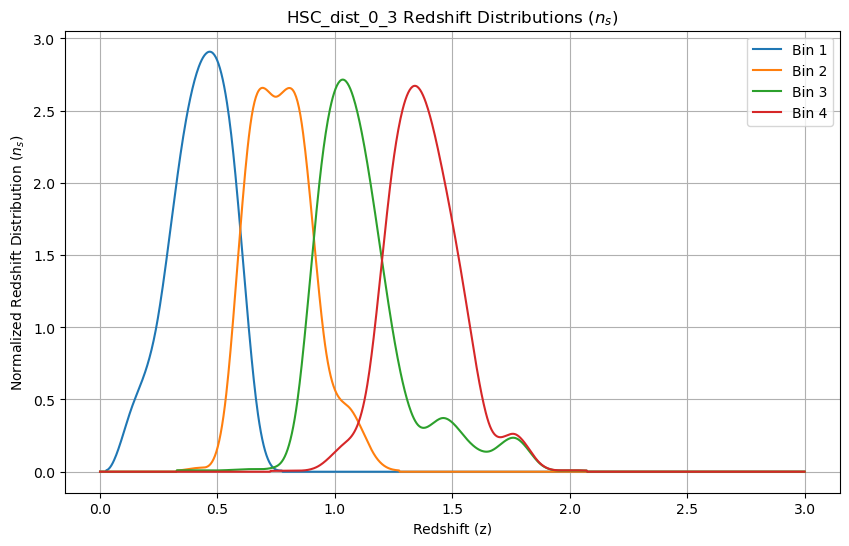

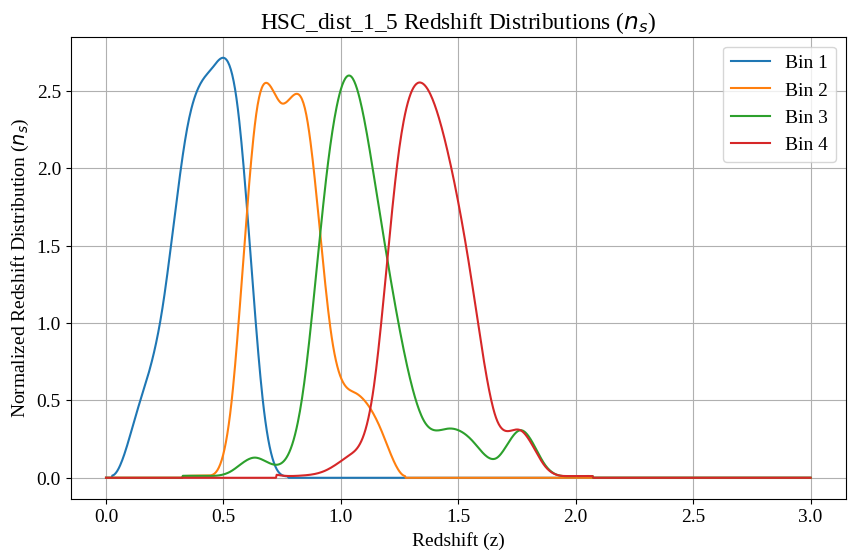

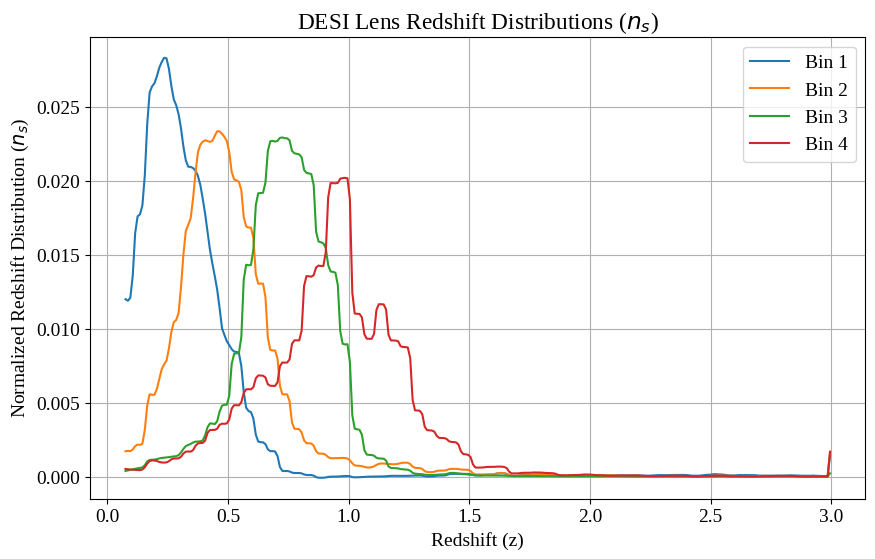

In [12]:
# graph HSC source distributions

plt.figure(figsize=(10, 6))
plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_a, label='Bin 1')
plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_b, label='Bin 2')
plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_c, label='Bin 3')
plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_d, label='Bin 4')
plt.xlabel('Redshift (z)')
plt.ylabel('Normalized Redshift Distribution ($n_s$)')
plt.title('HSC_dist_0_3 Redshift Distributions ($n_s$)')
plt.legend()
plt.grid(True)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Liberation Serif'
plt.rcParams['font.size'] = 14
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(HSC_dist_1_5_z, HSC_dist_1_5_a, label='Bin 1')
plt.plot(HSC_dist_1_5_z, HSC_dist_1_5_b, label='Bin 2')
plt.plot(HSC_dist_1_5_z, HSC_dist_1_5_c, label='Bin 3')
plt.plot(HSC_dist_1_5_z, HSC_dist_1_5_d, label='Bin 4')
plt.xlabel('Redshift (z)')
plt.ylabel('Normalized Redshift Distribution ($n_s$)')
plt.title('HSC_dist_1_5 Redshift Distributions ($n_s$)')
plt.legend()
plt.grid(True)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Liberation Serif'
plt.rcParams['font.size'] = 14
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(DESI_lens_z, DESI_lens_nz_a, label='Bin 1')
plt.plot(DESI_lens_z, DESI_lens_nz_b, label='Bin 2')
plt.plot(DESI_lens_z, DESI_lens_nz_c, label='Bin 3')
plt.plot(DESI_lens_z, DESI_lens_nz_d, label='Bin 4')
#plt.plot(DESI_lens_z, DESI_lens_nz_e, label='Bin 5')
#### nz_5 has values all of order e7 or above,
#### while the others have values of order e-5 or below
#### what's going on here?
plt.xlabel('Redshift (z)')
plt.ylabel('Normalized Redshift Distribution ($n_s$)')
plt.title('DESI Lens Redshift Distributions ($n_s$)')
plt.legend()
plt.grid(True)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Liberation Serif'
plt.rcParams['font.size'] = 14
plt.show()

In [13]:
# build DESI, SO noise, and magnification
# shot noise ref: https://arxiv.org/pdf/2407.04607
# shape noise ref: slack from Simone, can't find the Github itself
# SO noise ref:
# magnification ref: https://arxiv.org/pdf/2503.24385

sigma = 0.26
DESI_n_bar_deg2 = np.array([81.9, 148.1, 162.4, 148.3]) # Galaxies per square degree

# Convert n_bar from per deg^2 to per steradian
# 1 steradian = (180/pi)^2 square degrees
DESI_n_bar_steradian = DESI_n_bar_deg2 * (180.0 / np.pi)**2

DESI_shot_noise = np.zeros_like(DESI_n_bar_steradian)
DESI_shape_noise = np.zeros_like(DESI_n_bar_steradian)
for i in range(len(DESI_shot_noise)):
    DESI_shot_noise[i] = 1 / DESI_n_bar_steradian[i]
    DESI_shape_noise[i] = sigma ** 2 / DESI_n_bar_steradian[i]

# cmb noise arises from idk a bunch of stuff
# we have an SO noise curve, but it does not have precisely the same ells as our C_l
# we must interpolate the N_kk to produce a useful noise curve
SO_noise_data = np.genfromtxt("data/nlkk_v3_1_0deproj0_SENS2_fsky0p4_it_lT30-3000_lP30-5000.dat")
S_noise_ells = SO_noise_data[:, 0]
N_kk = SO_noise_data[:, 7]
N_TT = SO_noise_data[:, 1]
N_TE = SO_noise_data[:, 2]
N_EE = SO_noise_data[:, 3]
ells_for_noise_interp = np.arange(30, 5000 + 30) # Assuming n_ell = 5000 for new analysis
medium_ells_for_noise_interp = np.arange(30, 3000 + 30)

# Use fill_value=(N_kk[0], N_kk[-1]) to cap the noise at the boundaries
interpolated_N_kk_func = interp1d(S_noise_ells, N_kk, bounds_error=False, fill_value=(N_kk[0], N_kk[-1]))
SO_cmb_noise_kk = interpolated_N_kk_func(ells_for_noise_interp)
interpolated_N_TT_func = interp1d(S_noise_ells, N_TT, bounds_error=False, fill_value=(N_TT[0], N_TT[-1]))
SO_cmb_noise_TT = interpolated_N_TT_func(ells_for_noise_interp)
interpolated_N_TE_func = interp1d(S_noise_ells, N_TE, bounds_error=False, fill_value=(N_TE[0], N_TE[-1]))
SO_cmb_noise_TE = interpolated_N_TE_func(ells_for_noise_interp)
interpolated_N_EE_func = interp1d(S_noise_ells, N_EE, bounds_error=False, fill_value=(N_EE[0], N_EE[-1]))
SO_cmb_noise_EE = interpolated_N_EE_func(ells_for_noise_interp)

# medium_l_noise
medium_l_SO_cmb_noise_kk = interpolated_N_kk_func(medium_ells_for_noise_interp)
medium_l_SO_cmb_noise_TT = interpolated_N_TT_func(medium_ells_for_noise_interp)
medium_l_SO_cmb_noise_TE = interpolated_N_TE_func(medium_ells_for_noise_interp)
medium_l_SO_cmb_noise_EE = interpolated_N_EE_func(medium_ells_for_noise_interp)

# save
# make sure folder exists
os.makedirs("data", exist_ok=True)
np.save("data/SO_cmb_noise_kk.npy", SO_cmb_noise_kk)
print("Saved SO_cmb_noise_kk to data/SO_cmb_noise_kk.npy")
np.save("data/SO_cmb_noise_TT.npy", SO_cmb_noise_TT)
print("Saved SO_cmb_noise_TT to data/SO_cmb_noise_TT.npy")
np.save("data/SO_cmb_noise_TE.npy", SO_cmb_noise_TE)
print("Saved SO_cmb_noise_TE to data/SO_cmb_noise_TE.npy")
np.save("data/SO_cmb_noise_EE.npy", SO_cmb_noise_EE)
print("Saved SO_cmb_noise_EE to data/SO_cmb_noise_EE.npy")

# save medium l
# make sure folder exists
os.makedirs("data", exist_ok=True)
np.save("data/medium_l_SO_cmb_noise_kk.npy", medium_l_SO_cmb_noise_kk)
print("Saved medium_l_SO_cmb_noise_kk to data/medium_l_SO_cmb_noise_kk.npy")
np.save("data/medium_l_SO_cmb_noise_TT.npy", medium_l_SO_cmb_noise_TT)
print("Saved medium_l_SO_cmb_noise_TT to data/medium_l_SO_cmb_noise_TT.npy")
np.save("data/medium_l_SO_cmb_noise_TE.npy", medium_l_SO_cmb_noise_TE)
print("Saved medium_l_SO_cmb_noise_TE to data/medium_l_SO_cmb_noise_TE.npy")
np.save("data/medium_l_SO_cmb_noise_EE.npy", medium_l_SO_cmb_noise_EE)
print("Saved medium_l_SO_cmb_noise_EE to data/medium_l_SO_cmb_noise_EE.npy")

Saved SO_cmb_noise_kk to data/SO_cmb_noise_kk.npy
Saved SO_cmb_noise_TT to data/SO_cmb_noise_TT.npy
Saved SO_cmb_noise_TE to data/SO_cmb_noise_TE.npy
Saved SO_cmb_noise_EE to data/SO_cmb_noise_EE.npy
Saved medium_l_SO_cmb_noise_kk to data/medium_l_SO_cmb_noise_kk.npy
Saved medium_l_SO_cmb_noise_TT to data/medium_l_SO_cmb_noise_TT.npy
Saved medium_l_SO_cmb_noise_TE to data/medium_l_SO_cmb_noise_TE.npy
Saved medium_l_SO_cmb_noise_EE to data/medium_l_SO_cmb_noise_EE.npy


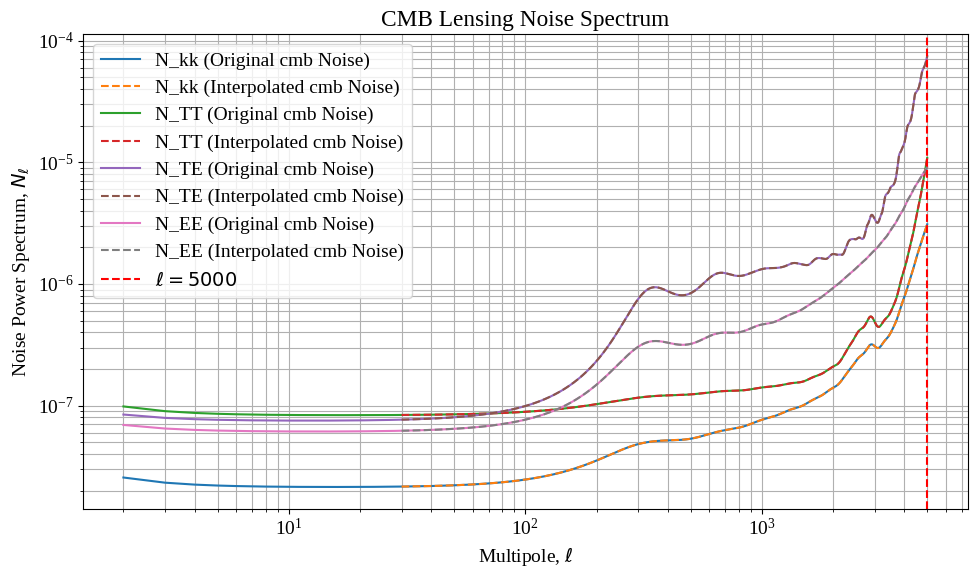

In [14]:
# plot cmb noise to see what it looks like

plt.figure(figsize=(10, 6))
plt.loglog(S_noise_ells, N_kk, label='N_kk (Original cmb Noise)')
plt.loglog(ells_for_noise_interp, SO_cmb_noise_kk, label='N_kk (Interpolated cmb Noise)', linestyle='--')
plt.loglog(S_noise_ells, N_TT, label='N_TT (Original cmb Noise)')
plt.loglog(ells_for_noise_interp, SO_cmb_noise_TT, label='N_TT (Interpolated cmb Noise)', linestyle='--')
plt.loglog(S_noise_ells, N_TE, label='N_TE (Original cmb Noise)')
plt.loglog(ells_for_noise_interp, SO_cmb_noise_TE, label='N_TE (Interpolated cmb Noise)', linestyle='--')
plt.loglog(S_noise_ells, N_EE, label='N_EE (Original cmb Noise)')
plt.loglog(ells_for_noise_interp, SO_cmb_noise_EE, label='N_EE (Interpolated cmb Noise)', linestyle='--')
plt.xlabel('Multipole, $\ell$')
plt.ylabel('Noise Power Spectrum, $N_{\ell}$')
plt.title('CMB Lensing Noise Spectrum')
plt.axvline(x=5000, color='red', linestyle='--', label='$\ell = 5000$') # Added vertical line
plt.legend()
plt.grid(True, which="both", ls="-")
plt.tight_layout()
plt.show()

In [15]:
# make and save shot and shape noise and data files for just the first bin

# make sure folder exists
os.makedirs("data", exist_ok=True)

# data
DESI_lens_data_bin1 = DESI_lens_data[:, :2]  # z + first lens bin
HSC_dist_0_3_bin1 = HSC_dist_0_3[:, :2]       # z + first source bin

# noise
DESI_shot_noise_bin1 = np.array([DESI_shot_noise[0]])
DESI_shape_noise_bin1 = np.array([DESI_shape_noise[0]])
#SO_cmb_noise_kk was already saved

# save
np.save("data/DESI_lens_data_bin1.npy", DESI_lens_data_bin1)
np.save("data/HSC_dist_0_3_bin1.npy", HSC_dist_0_3_bin1)
np.save("data/DESI_shot_noise_bin1.npy", DESI_shot_noise_bin1)
np.save("data/DESI_shape_noise_bin1.npy", DESI_shape_noise_bin1)
#SO_cmb_noise_kk was already saved

# check
print("DESI_lens_data_bin1 shape:", DESI_lens_data_bin1.shape)
print("HSC_dist_0_3_bin1 shape:", HSC_dist_0_3_bin1.shape)
print("DESI_shot_noise_bin1:", DESI_shot_noise_bin1)
print("DESI_shape_noise_bin1:", DESI_shape_noise_bin1)

DESI_lens_data_bin1 shape: (293, 2)
HSC_dist_0_3_bin1 shape: (1000, 2)
DESI_shot_noise_bin1: [3.71938241e-06]
DESI_shape_noise_bin1: [2.51430251e-07]


In [16]:
# 1. Save Full DESI Lens Data (all 4 bins: columns z, nz_a, nz_b, nz_c, nz_d)
# Note: DESI_lens_data was already column-stacked in Cell 4
np.save("data/DESI_lens_data.npy", DESI_lens_data)

# 2. Save Full HSC Source Data (all 4 bins for both redshift ranges)
np.save("data/HSC_dist_0_3.npy", HSC_dist_0_3)
np.save("data/HSC_dist_1_5.npy", HSC_dist_1_5)

# 3. Save Full DESI Shot Noise and Shape Noise (Arrays for all 4 bins)
# These were calculated for all bins using DESI_n_bar_steradian in Cell 8
np.save("data/DESI_shot_noise.npy", DESI_shot_noise)
np.save("data/DESI_shape_noise.npy", DESI_shape_noise)

# Verification Printouts
print("Full datasets saved successfully!")
print("DESI Lens Data shape: ", DESI_lens_data.shape)
print("HSC 0.3-3 Dist shape: ", HSC_dist_0_3.shape)

Full datasets saved successfully!
DESI Lens Data shape:  (293, 5)
HSC 0.3-3 Dist shape:  (1000, 5)


# Convariance Matrices

The covariance matrix is rather complicated because we have many different types of data for which we need to consider the covariances. We'll set up the data vector:

$$\mathbf{D} = [C_\ell^{\kappa_{c}\kappa_{c}}, C_\ell^{\kappa_{c}g}, C_\ell^{\kappa_{c}\kappa_{g}}, C_\ell^{\kappa_{g}\kappa_{g}}, C_\ell^{\kappa_{g}g}, C_\ell^{gg}]$$

This vector consists of:
* **cmb lensing convergence power spectrum:** $C_\ell^{\kappa_{c}\kappa_{c}}$
* **Galaxy lensing–cmb lensing cross-spectrum:** $C_\ell^{\kappa_{c}\kappa_{g}}$ (cmb lensing - galaxy lensing)
* **Lens galaxies–cmb lensing cross-spectrum:** $C_\ell^{\kappa_{c}g}$ (cmb lensing - galaxy number density)
* **Galaxy lensing convergence auto/cross-spectrum:** $C_\ell^{\kappa_{g}\kappa_{g}}$
* **Lens galaxy-galaxy lensing cross-spectrum:** $C_\ell^{g\kappa_{g}}$ (galaxy - galaxy lensing)
* **Lens galaxies auto/cross-spectrum:** $C_\ell^{gg}$ (galaxy clustering)

Note: In all the code written and used before 06/26/2026 $\kappa_{c}$ is written as $\phi$, $\kappa_{c}$ is listed as $l$, and $g$ is listed as $g$. I originally expected to be working with lensing potential, and changing the labels generated some bugs, so I left it as it was for a while.

If we have **a** lens bins and **b** source bins we have 1 cmb, $\frac{a(a+1)}{2}$ lens-lens, $\frac{b(b+1)}{2}$ source-source, ab lens-source, a lens-cmb, and b source-cmb spectra. Each component is a list with $N_l$ entries.

The covariance matrix includes the covariances of all spectra with all other spectra. This means that it is a massive block matrix, with each block being an $N_\ell \times N_\ell$ matrix.

$$\text{Cov}_{\text{master }}[i,j] = \text{Cov}(D_i, D_j)$$
$$\mathrm{Cov}(C^{ab}_{\ell}, C^{cd}_{\ell'}) = \frac{\delta_{\ell \ell'}}{(2\ell + 1)\, f_{\mathrm{sky}}} \left( C^{ac}_\ell C^{bd}_\ell + C^{ad}_\ell C^{bc}_\ell \right)$$

In order to do a proper MCMC, we will need to calculate the entries in the master covariance matrix and input it into Cobaya.

Note that calculating covariances will be a little tricky because we'll need the computer to figure out what spectra are being considered, separate out their variables, swap them around, and then locate the correct spectra for the product terms.

In [18]:
# calculate and save flat LCDM fiducial data vector and covariance matrix for single bin w/lensing ratios primaries

# ensure output directory exists
os.makedirs('cobaya_data', exist_ok=True)

print("Calculating fiducial data vector and covariance matrix for single bin w/primaries...")

# extract other parameters directly, or hardcode them if they are constant for this generation step
f_sky = 0.4
l_min = 30
n_ell = 5000
binsize = 50
magnification_bias_lenses = 0.8

# build covariance and spectra dictionary w/o emulator, so they'll be maximally accurate
cov_obj, fiducial_spectra_dict, f_map = \
    build_covariance_from_data(
        flat_LCDM_cosmology,
        DESI_lens_data_bin1,
        HSC_dist_0_3_bin1,
        f_sky=f_sky,
        l_min=l_min,
        n_ell=n_ell,
        binsize=binsize,
        shot_noise_lens=DESI_shot_noise_bin1,
        shape_noise_source=DESI_shape_noise_bin1,
        cmb_noise_kk=SO_cmb_noise_kk,
        cmb_noise_TT=SO_cmb_noise_TT,
        cmb_noise_EE=SO_cmb_noise_EE,
        cmb_noise_TE=SO_cmb_noise_TE,
        magnification_bias_lenses=magnification_bias_lenses,
        desired_spectra=['CG', 'GL', 'EE', 'TT', 'TE'],
        linear_emulator=None,
        boost_emulator=None,
        cmb_primaries = True,
        z_max = 6,
        n_chi = 1024
    )

# get the covariance matrix
covariance_matrix = cov_obj.matrix

# extract and flatten the fiducial data vector
observed_data_vector = build_data_vector(forecast_map = f_map, spectra_dict = fiducial_spectra_dict, n_ell = n_ell, binsize = binsize)

# Save to files
data_vector_filename = 'cobaya_data/flat_LCDM_bin1_LRP_data_vector.npy'
covariance_filename = 'cobaya_data/flat_LCDM_bin1_LRP_covariance_matrix.npy'

np.save(data_vector_filename, observed_data_vector)
np.save(covariance_filename, covariance_matrix)

Calculating fiducial data vector and covariance matrix for single bin w/primaries...


# Fisher Forecasts

Fisher forecasts are efficient, approximate forecasts that produce best-case constraints on parameters given experimental setups. They are applicable for models near the fiducial model. Producing a Fisher matrix requires a fiducial model and derivatives of the model's covariance matrix and data vector.

When the probability distribution is Gaussian, the Fisher information matrix $F_{ij}$ simplifies to:

$$F_{ij} = \langle \mathcal{L}_{,ij} \rangle = \frac{1}{2} \text{Tr}[A_i A_j + C^{-1} M_{ij}]$$

where
* $A_i \equiv C^{-1} C_{,i} = (\ln C)_{,i}$
* $M_{ij} \equiv \langle D_{,ij} \rangle = \mu_{,i} \mu_{,j}^t + \mu_{,j} \mu_{,i}^t$
* $C$ is the covariance matrix
* $\mu$ is the mean vector
* the comma notation denotes partial derivatives with respect to the model parameters (e.g., $C_{,i} \equiv \frac{\partial C}{\partial \theta_i}$).

The inverse of the Fisher matrix is the covariance matrix, which gives the variances/covariances of paramaters/pairs of parameters. If the other parameters are estimated from the data as well, the minimum standard deviation of one parameter is $\Delta\theta_i \ge \left(F^{-1}\right)^{1/2}_{ii}$.

For more information, see https://arxiv.org/pdf/astro-ph/9603021.

## DESI DR2 Results II Table V Comparison: $\Omega_m, \Omega_k, h, w_0, w_a$

In [58]:
# results without priors

data_dict = {
    "ΛCDM": [
        ["*SO + DESI Photometric (Lensing Ratios)", "0.317 \\pm 0.014", "0.673 \\pm 0.048", "—", "—", "—"],
        ["SO (Primaries)", "0.3166 \\pm 0.0074", "0.6727 \\pm 0.0057", "—", "—", "—"],
        ["*SO + DESI Photometric (Primaries + Lensing Ratios)", "0.3166 \\pm 0.0039", "0.6727 \\pm 0.0030", "—", "—", "—"],
        ["DESI BAO + CMB (DESI DR2)", "0.3027 \\pm 0.0036", "0.6817 \\pm 0.0028", "—", "—", "—"], 
    ],
    "ΛCDM + Ω_K": [
        ["**SO + DESI Photometric (Lensing Ratios)", "0.317 \\pm 0.017", "0.685 \\pm 0.040", "0.002 \\pm 0.020", "-", "-"],
        ["SO (Primaries)", "0.317 \\pm 0.032", "0.685 \\pm 0.032", "0.0023 \\pm 0.0044", "-", "-"],
        ["**SO + DESI Photometric (Primaries + Lensing Ratios)", "0.3166 \\pm 0.0090", "0.6850 \\pm 0.0095", "0.0023 \\pm 0.0018", "-", "-"],
        ["DESI BAO + CMB (DESI DR2)", "0.3034 \\pm 0.0037", "0.6850 \\pm 0.0033", "0.0023 \\pm 0.0011", "—", "—"], 
    ],
    "wCDM": [
        ["**SO + DESI Photometric (Lensing Ratios)", "0.317 \\pm 0.014", "0.695 \\pm 0.029", "-", "-1.06 \\pm 0.12", "-"],
        ["SO (Primares)", "0.31650 \\pm 0.00098", "0.6951 \\pm 0.0012", "-", "-1.0550 \\pm 0.0085", "-"],
        ["SO + DESI Photometric (Primaries + Lensing Ratios)", "0.31650 \\pm 0.00097", "0.6951 \\pm 0.0011", "-", "-1.0550 \\pm 0.0069", "-"],
        ["DESI BAO + CMB (DESI DR2)", "0.2927 \\pm 0.0073", "0.6951 \\pm 0.0092", "—", "-1.055 \\pm 0.036", "—"], 
    ],
    "w_0w_aCDM": [
        ["**SO + DESI Photometric (Lensing Ratios)", "0.317 \\pm 0.021", "0.667 \\pm 0.039", "-", "-0.75 \\pm 0.20", "-0.86 \\pm 0.58"],
        ["SO (Primaries)", "0.3166 \\pm 0.0055", "0.6674 \\pm 0.0055", "-", "-0.752 \\pm 0.048", "-0.86 \\pm 0.21"], 
        ["SO + DESI Photometric (Primaries + Lensing Ratios)", "0.3166 \\pm 0.0051", "0.6674 \\pm 0.0050", "-", "-0.752 \\pm 0.045", "-0.86 \\pm 0.19"],
        ["DESI BAO + CMB + DESY5 (DESI DR2)", "0.3191 \\pm 0.0056", "0.6674 \\pm 0.0056", "—", "-0.752 \\pm 0.057", "-0.86^{+0.23}_{-0.20}"], 
    ],
    "w_0w_aCDM + Ω_K": [
        ["**SO + DESI Photometric (Lensing Ratios)", "0.317 \\pm 0.021", "0.667 \\pm 0.040", "0.000 \\pm 0.022", "-0.75 \\pm 0.20", "-0.86 \\pm 0.58"],
        ["*SO (Primaries)", "0.3166 \\pm 0.0058", "0.6674 \\pm 0.0062", "0.0000 \\pm 0.0017", "-0.752 \\pm 0.063", "-0.86 \\pm 0.24"],        
        ["SO + DESI Photometric (Primaries + Lensing Ratios)", "0.3166 \\pm 0.0053", "0.6674 \\pm 0.0057", "0.0000 \\pm 0.0016", "-0.752 \\pm 0058", "-0.86 \\pm 0.21"],
        ["DESI BAO + CMB + DESY5 (DESI DR2)", "0.3193 \\pm 0.0056", "0.6682 \\pm 0.0058", "0.0008 \\pm 0.0013", "-0.762 \\pm 0.060", "—0.81 \\pm 0.24"], 
    ]
}

# Mapping string keys to beautifully formatted bold LaTeX headers
latex_header_map = {
    "ΛCDM": r"**$\Lambda\text{CDM}$**",
    "ΛCDM + Ω_K": r"**$\Lambda\text{CDM} + \Omega_K$**",
    "wCDM": r"**$w\text{CDM}$**",
    "w_0w_aCDM": r"**$w_0w_a\text{CDM}$**",
    "w_0w_aCDM + Ω_K": r"**$w_0w_a\text{CDM} + \Omega_K$**"
}

# 2. Reconstruct the rows using dynamic inline Markdown formulas
table_rows = []
for model, rows in data_dict.items():
    pretty_header = latex_header_map.get(model, f"**{model}**")
    table_rows.append([pretty_header, "", "", "", "", ""])
    
    for row in rows:
        formatted_row = [f"&nbsp;&nbsp;&nbsp;&nbsp;{row[0]}"]  
        
        for cell in row[1:]:
            if cell != "—" and not cell.startswith("<"):
                formatted_row.append(f"${cell}$")
            elif cell.startswith("<"):
                limit_val = cell.split("<")[-1].strip()
                formatted_row.append(f"$< {limit_val}$")
            else:
                formatted_row.append(cell)
                
        table_rows.append(formatted_row)

# 3. Headers using standard LaTeX math-mode layouts
headers = [
    "Model/Dataset", 
    "$\\Omega_m$", 
    "$h$", 
    "$\\Omega_K$", 
    "$w\\text{ or }w_0$", 
    "$w_a$"
]

# 4. Generate and display the native Markdown structure
md_lines = [
    "### Forecasted Cosmological Parameter Constraints (Priorless Fisher, Binsize = 25)",
    "",
    f"| {' | '.join(headers)} |",
    f"| :--- | {' | '.join([':---:'] * (len(headers) - 1))} |"
]

for row in table_rows:
    if row[1] == "" and row[2] == "":
        md_lines.append(f"| {row[0]} | | | | | |")
    else:
        md_lines.append(f"| {' | '.join(row)} |")

# Create a text footnote block wrapped in a width-constrained HTML container
footnote_html = """
<div style="max-width: 900px; width: 100%; font-size: 14px; color: #555; line-height: 1.5; margin-top: 12px; padding-left: 4px; text-align: justify;">
    <strong>* Note:</strong> We binned the data to decrease the runtime. All parameter constraints stayed the same or tightened with decreasing binsize. 
    One asterisk is put by configurations for which a 50% decrease in binsize corresponded to a 10% – 20% tightening 
    of the constraint of one or more parameters. Two asterisks are put by configurations for which a 50% decrease 
    in binsize corresponded to a 20% – 30% tightening of the constraint of one or more parameters. For those configurations and parameters in particular, 
    the constraints shown are likely notably looser than the best-case (binsize = 1) constraints. For more details, see the 'Binsize Tests' section.
</div>
"""

# Display both the generated Markdown table and the constrained footnote seamlessly
display(Markdown("\n".join(md_lines)), HTML(footnote_html))

### Forecasted Cosmological Parameter Constraints (Priorless Fisher, Binsize = 25)

| Model/Dataset | $\Omega_m$ | $h$ | $\Omega_K$ | $w\text{ or }w_0$ | $w_a$ |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **$\Lambda\text{CDM}$** | | | | | |
| &nbsp;&nbsp;&nbsp;&nbsp;*SO + DESI Photometric (Lensing Ratios) | $0.317 \pm 0.014$ | $0.673 \pm 0.048$ | — | — | — |
| &nbsp;&nbsp;&nbsp;&nbsp;SO (Primaries) | $0.3166 \pm 0.0074$ | $0.6727 \pm 0.0057$ | — | — | — |
| &nbsp;&nbsp;&nbsp;&nbsp;*SO + DESI Photometric (Primaries + Lensing Ratios) | $0.3166 \pm 0.0039$ | $0.6727 \pm 0.0030$ | — | — | — |
| &nbsp;&nbsp;&nbsp;&nbsp;DESI BAO + CMB (DESI DR2) | $0.3027 \pm 0.0036$ | $0.6817 \pm 0.0028$ | — | — | — |
| **$\Lambda\text{CDM} + \Omega_K$** | | | | | |
| &nbsp;&nbsp;&nbsp;&nbsp;**SO + DESI Photometric (Lensing Ratios) | $0.317 \pm 0.017$ | $0.685 \pm 0.040$ | $0.002 \pm 0.020$ | $-$ | $-$ |
| &nbsp;&nbsp;&nbsp;&nbsp;SO (Primaries) | $0.317 \pm 0.032$ | $0.685 \pm 0.032$ | $0.0023 \pm 0.0044$ | $-$ | $-$ |
| &nbsp;&nbsp;&nbsp;&nbsp;**SO + DESI Photometric (Primaries + Lensing Ratios) | $0.3166 \pm 0.0090$ | $0.6850 \pm 0.0095$ | $0.0023 \pm 0.0018$ | $-$ | $-$ |
| &nbsp;&nbsp;&nbsp;&nbsp;DESI BAO + CMB (DESI DR2) | $0.3034 \pm 0.0037$ | $0.6850 \pm 0.0033$ | $0.0023 \pm 0.0011$ | — | — |
| **$w\text{CDM}$** | | | | | |
| &nbsp;&nbsp;&nbsp;&nbsp;**SO + DESI Photometric (Lensing Ratios) | $0.317 \pm 0.014$ | $0.695 \pm 0.029$ | $-$ | $-1.06 \pm 0.12$ | $-$ |
| &nbsp;&nbsp;&nbsp;&nbsp;SO (Primares) | $0.31650 \pm 0.00098$ | $0.6951 \pm 0.0012$ | $-$ | $-1.0550 \pm 0.0085$ | $-$ |
| &nbsp;&nbsp;&nbsp;&nbsp;SO + DESI Photometric (Primaries + Lensing Ratios) | $0.31650 \pm 0.00097$ | $0.6951 \pm 0.0011$ | $-$ | $-1.0550 \pm 0.0069$ | $-$ |
| &nbsp;&nbsp;&nbsp;&nbsp;DESI BAO + CMB (DESI DR2) | $0.2927 \pm 0.0073$ | $0.6951 \pm 0.0092$ | — | $-1.055 \pm 0.036$ | — |
| **$w_0w_a\text{CDM}$** | | | | | |
| &nbsp;&nbsp;&nbsp;&nbsp;**SO + DESI Photometric (Lensing Ratios) | $0.317 \pm 0.021$ | $0.667 \pm 0.039$ | $-$ | $-0.75 \pm 0.20$ | $-0.86 \pm 0.58$ |
| &nbsp;&nbsp;&nbsp;&nbsp;SO (Primaries) | $0.3166 \pm 0.0055$ | $0.6674 \pm 0.0055$ | $-$ | $-0.752 \pm 0.048$ | $-0.86 \pm 0.21$ |
| &nbsp;&nbsp;&nbsp;&nbsp;SO + DESI Photometric (Primaries + Lensing Ratios) | $0.3166 \pm 0.0051$ | $0.6674 \pm 0.0050$ | $-$ | $-0.752 \pm 0.045$ | $-0.86 \pm 0.19$ |
| &nbsp;&nbsp;&nbsp;&nbsp;DESI BAO + CMB + DESY5 (DESI DR2) | $0.3191 \pm 0.0056$ | $0.6674 \pm 0.0056$ | — | $-0.752 \pm 0.057$ | $-0.86^{+0.23}_{-0.20}$ |
| **$w_0w_a\text{CDM} + \Omega_K$** | | | | | |
| &nbsp;&nbsp;&nbsp;&nbsp;**SO + DESI Photometric (Lensing Ratios) | $0.317 \pm 0.021$ | $0.667 \pm 0.040$ | $0.000 \pm 0.022$ | $-0.75 \pm 0.20$ | $-0.86 \pm 0.58$ |
| &nbsp;&nbsp;&nbsp;&nbsp;*SO (Primaries) | $0.3166 \pm 0.0058$ | $0.6674 \pm 0.0062$ | $0.0000 \pm 0.0017$ | $-0.752 \pm 0.063$ | $-0.86 \pm 0.24$ |
| &nbsp;&nbsp;&nbsp;&nbsp;SO + DESI Photometric (Primaries + Lensing Ratios) | $0.3166 \pm 0.0053$ | $0.6674 \pm 0.0057$ | $0.0000 \pm 0.0016$ | $-0.752 \pm 0058$ | $-0.86 \pm 0.21$ |
| &nbsp;&nbsp;&nbsp;&nbsp;DESI BAO + CMB + DESY5 (DESI DR2) | $0.3193 \pm 0.0056$ | $0.6682 \pm 0.0058$ | $0.0008 \pm 0.0013$ | $-0.762 \pm 0.060$ | $—0.81 \pm 0.24$ |

### Flat LCDM

Plot successfully saved to: plots/Fisher Forecasts/lensing_ratios_flat_lcdm_all_photometric_bins_fisher_forecast_binzise_=_25.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.317\pm 0.014$ | $\Omega_m = 0.317^{+0.028}_{-0.028}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.317\pm 0.014$ | $\Omega_m = 0.317^{+0.028}_{-0.028}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.673\pm 0.047$ | $h = 0.673^{+0.093}_{-0.092}$ |
|  | Fisher Forecast (No Priors) | $h = 0.673\pm 0.048$ | $h = 0.673^{+0.094}_{-0.094}$ |
| --- | --- | --- | --- |

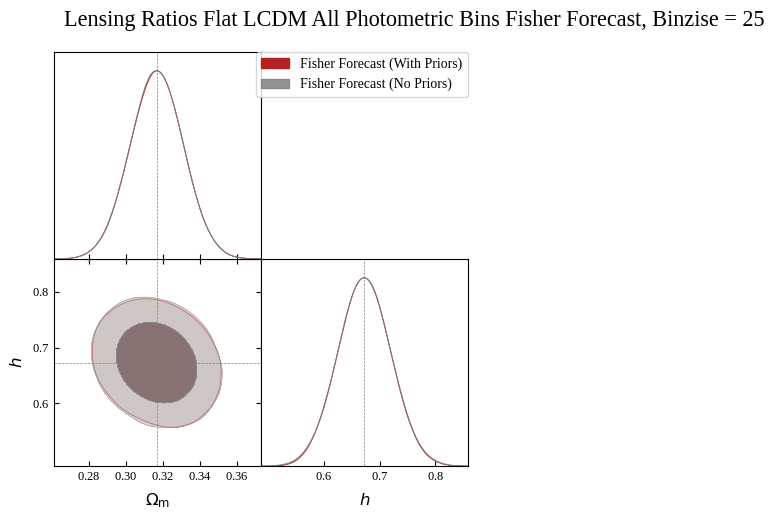

total_time:  0:01:29.622368


In [62]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=25,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=None,
    cmb_noise_EE=None,
    cmb_noise_TE=None,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['CG', 'GL'],
    cmb_primaries=False,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h']
params_to_plot = ['Omega_m', 'h']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_LCDM_LR_All_Photometric_Bins_Binsize=25.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_LCDM_LR_All_Photometric_Bins_Binsize=25.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Lensing Ratios Flat LCDM All Photometric Bins Fisher Forecast, Binzise = 25",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Plot successfully saved to: plots/Fisher Forecasts/primaries_flat_lcdm_all_photometric_bins_fisher_forecast_binzise_=_25.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.3174^{+0.0061}_{-0.0075}$ | $\Omega_m = 0.317^{+0.013}_{-0.012}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3166\pm 0.0074$ | $\Omega_m = 0.317^{+0.014}_{-0.014}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6721^{+0.0058}_{-0.0047}$ | $h = 0.6721^{+0.0096}_{-0.0099}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6727\pm 0.0057$ | $h = 0.673^{+0.011}_{-0.011}$ |
| --- | --- | --- | --- |

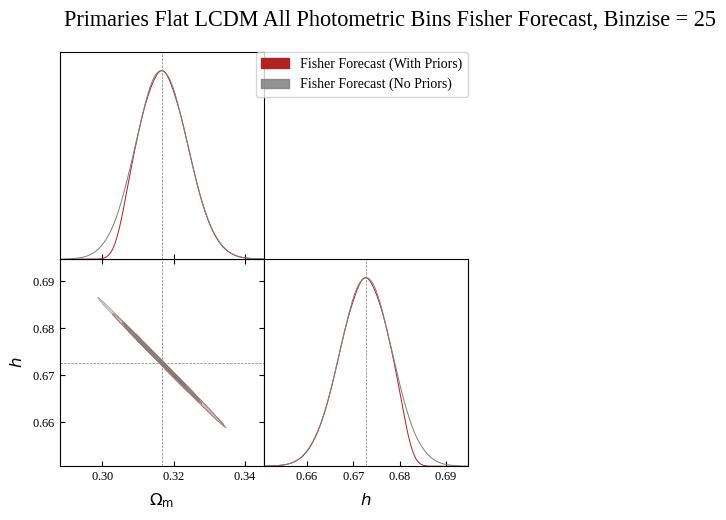

total_time:  0:02:13.922707


In [66]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=25,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_cmb_noise_TT,
    cmb_noise_EE=SO_cmb_noise_EE,
    cmb_noise_TE=SO_cmb_noise_TE,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['TT', 'TE', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h']
params_to_plot = ['Omega_m', 'h']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_LCDM_Primaries_All_Photometric_Bins_Binsize=25.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_LCDM_Primaries_All_Photometric_Bins_Binsize=25.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Primaries Flat LCDM All Photometric Bins Fisher Forecast, Binzise = 25",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Plot successfully saved to: plots/Fisher Forecasts/lensing_ratios_+_primaries_flat_lcdm_all_photometric_bins_fisher_forecast_binzise_=_25.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.3166\pm 0.0039$ | $\Omega_m = 0.3166^{+0.0077}_{-0.0076}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3166\pm 0.0039$ | $\Omega_m = 0.3166^{+0.0078}_{-0.0077}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6727\pm 0.0030$ | $h = 0.6727^{+0.0059}_{-0.0059}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6727\pm 0.0030$ | $h = 0.6727^{+0.0059}_{-0.0059}$ |
| --- | --- | --- | --- |

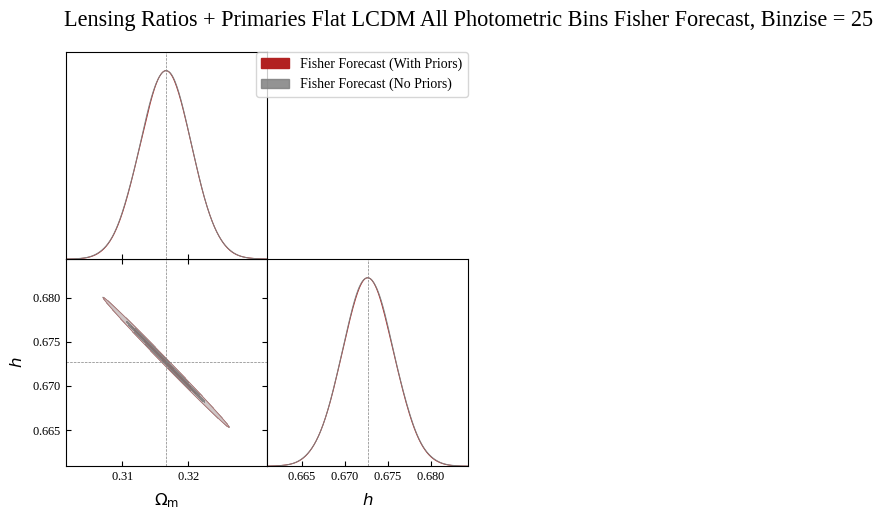

total_time:  0:02:31.540756


In [69]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=25,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_cmb_noise_TT,
    cmb_noise_EE=SO_cmb_noise_EE,
    cmb_noise_TE=SO_cmb_noise_TE,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['CG', 'GL', 'TT', 'TE', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h']
params_to_plot = ['Omega_m', 'h']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_LCDM_LRP_All_Photometric_Bins_Binsize=25.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h\n'
)
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_LCDM_LRP_All_Photometric_Bins_Binsize=25.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Lensing Ratios + Primaries Flat LCDM All Photometric Bins Fisher Forecast, Binzise = 25",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

### Curved LCDM

Plot successfully saved to: plots/Fisher Forecasts/lensing_ratios_curved_lcdm_all_photometric_bins_fisher_forecast_binzise_=_25.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.317\pm 0.017$ | $\Omega_m = 0.317^{+0.033}_{-0.033}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.317\pm 0.017$ | $\Omega_m = 0.317^{+0.033}_{-0.033}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.685\pm 0.040$ | $h = 0.685^{+0.078}_{-0.078}$ |
|  | Fisher Forecast (No Priors) | $h = 0.685\pm 0.040$ | $h = 0.685^{+0.078}_{-0.078}$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Fisher Forecast (With Priors) | $\Omega_k = 0.002\pm 0.020$ | $\Omega_k = 0.002^{+0.040}_{-0.040}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.002\pm 0.020$ | $\Omega_k = 0.002^{+0.040}_{-0.040}$ |
| --- | --- | --- | --- |

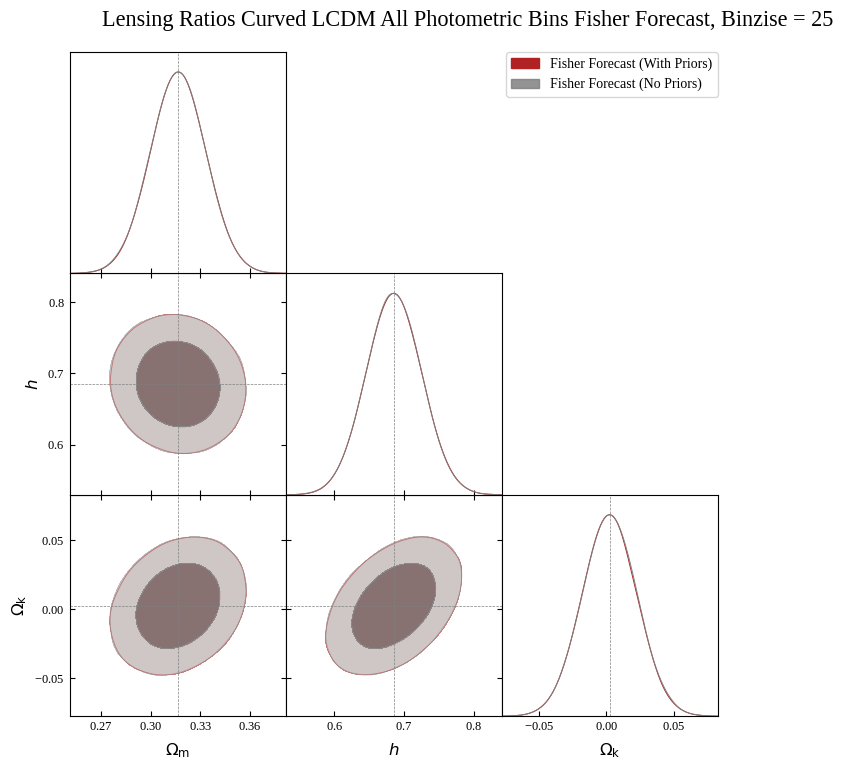

total_time:  0:01:59.210498


In [53]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=curved_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=25,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=None,
    cmb_noise_EE=None,
    cmb_noise_TE=None,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['CG', 'GL'],
    cmb_primaries=False,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h', 'Omega_k']
params_to_plot = ['Omega_m', 'h', 'Omega_k']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Curved_LCDM_LR_All_Photometric_Bins_Binsize=25.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h Omega_k',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, Omega_k\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Curved_LCDM_LR_All_Photometric_Bins_Binsize=25.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h Omega_k',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, Omega_k\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Lensing Ratios Curved LCDM All Photometric Bins Fisher Forecast, Binzise = 25",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Plot successfully saved to: plots/Fisher Forecasts/primaries_curved_lcdm_all_photometric_bins_fisher_forecast_binzise_=_25.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.331^{+0.014}_{-0.030}$ | $\Omega_m = 0.331^{+0.046}_{-0.038}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.317\pm 0.032$ | $\Omega_m = 0.317^{+0.063}_{-0.062}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.671^{+0.029}_{-0.015}$ | $h = 0.671^{+0.039}_{-0.046}$ |
|  | Fisher Forecast (No Priors) | $h = 0.685\pm 0.032$ | $h = 0.685^{+0.062}_{-0.062}$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Fisher Forecast (With Priors) | $\Omega_k = 0.0004^{+0.0040}_{-0.0026}$ | $\Omega_k = 0.0004^{+0.0060}_{-0.0068}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.0023\pm 0.0044$ | $\Omega_k = 0.0023^{+0.0087}_{-0.0087}$ |
| --- | --- | --- | --- |

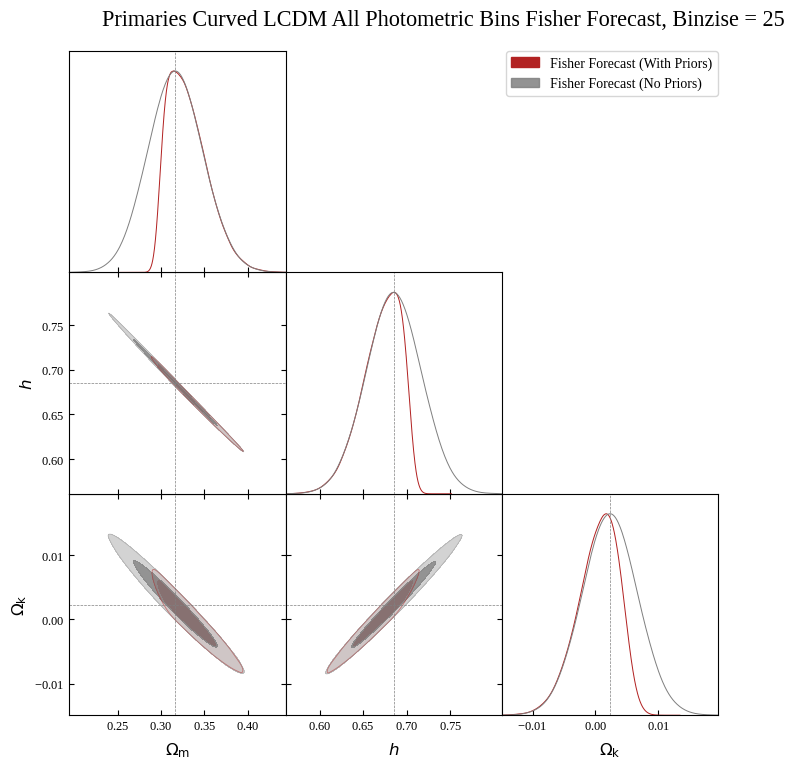

total_time:  0:02:49.118598


In [56]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=curved_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=25,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_cmb_noise_TT,
    cmb_noise_EE=SO_cmb_noise_EE,
    cmb_noise_TE=SO_cmb_noise_TE,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['TT', 'TE', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h', 'Omega_k']
params_to_plot = ['Omega_m', 'h', 'Omega_k']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Curved_LCDM_Primaries_All_Photometric_Bins_Binsize=25.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h Omega_k',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, Omega_k\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Curved_LCDM_Primaries_All_Photometric_Bins_Binsize=25.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h Omega_k',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, Omega_k\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Primaries Curved LCDM All Photometric Bins Fisher Forecast, Binzise = 25",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Plot successfully saved to: plots/Fisher Forecasts/lensing_ratios_+_primaries_curved_lcdm_all_photometric_bins_fisher_forecast_binzise_=_25.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.3169\pm 0.0087$ | $\Omega_m = 0.317^{+0.017}_{-0.016}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3166\pm 0.0090$ | $\Omega_m = 0.317^{+0.018}_{-0.018}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6847\pm 0.0092$ | $h = 0.685^{+0.018}_{-0.018}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6850\pm 0.0095$ | $h = 0.685^{+0.019}_{-0.019}$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Fisher Forecast (With Priors) | $\Omega_k = 0.0023\pm 0.0017$ | $\Omega_k = 0.0023^{+0.0034}_{-0.0034}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.0023\pm 0.0018$ | $\Omega_k = 0.0023^{+0.0034}_{-0.0034}$ |
| --- | --- | --- | --- |

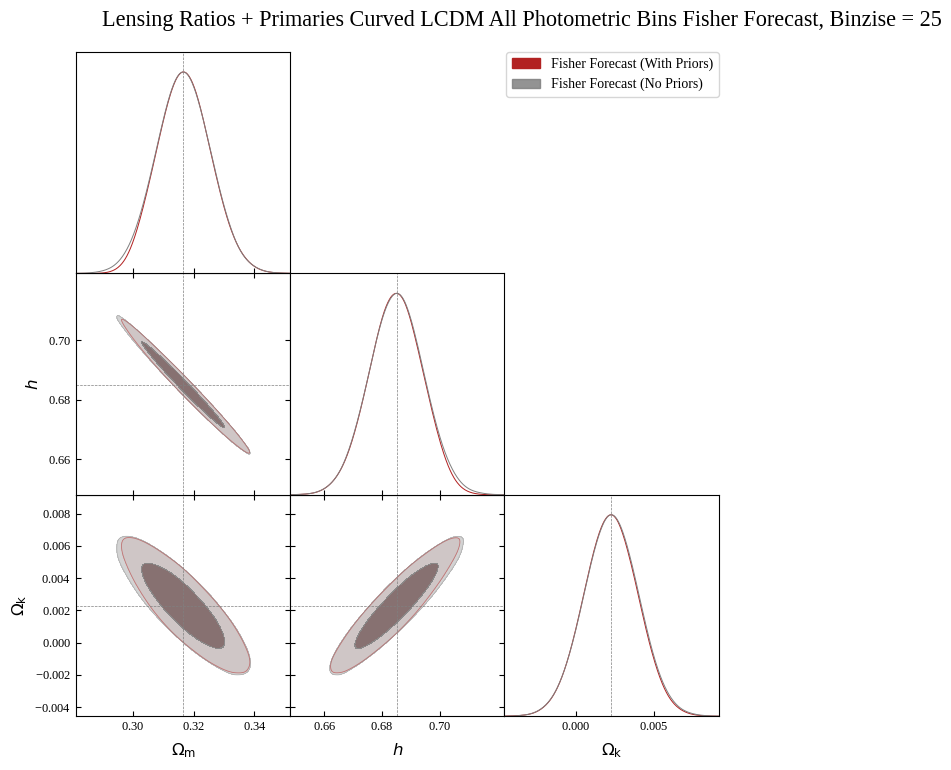

total_time:  0:03:18.223631


In [59]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=curved_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=25,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_cmb_noise_TT,
    cmb_noise_EE=SO_cmb_noise_EE,
    cmb_noise_TE=SO_cmb_noise_TE,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['CG', 'GL', 'TT', 'TE', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h', 'Omega_k']
params_to_plot = ['Omega_m', 'h', 'Omega_k']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Curved_LCDM_LRP_All_Photometric_Bins_Binsize=25.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h Omega_k',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, Omega_k\n'
)
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Curved_LCDM_LRP_All_Photometric_Bins_Binsize=25.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h Omega_k',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, Omega_k\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Lensing Ratios + Primaries Curved LCDM All Photometric Bins Fisher Forecast, Binzise = 25",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

### Flat wCDM

Plot successfully saved to: plots/Fisher Forecasts/lensing_ratios_flat_wcdm_all_photometric_bins_fisher_forecast_binzise_=_25.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.317\pm 0.014$ | $\Omega_m = 0.317^{+0.027}_{-0.027}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.317\pm 0.014$ | $\Omega_m = 0.317^{+0.027}_{-0.027}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.695\pm 0.029$ | $h = 0.695^{+0.058}_{-0.058}$ |
|  | Fisher Forecast (No Priors) | $h = 0.695\pm 0.029$ | $h = 0.695^{+0.058}_{-0.057}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -1.06\pm 0.12$ | $w_0 = -1.06^{+0.24}_{-0.24}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -1.05\pm 0.12$ | $w_0 = -1.05^{+0.23}_{-0.24}$ |
| --- | --- | --- | --- |

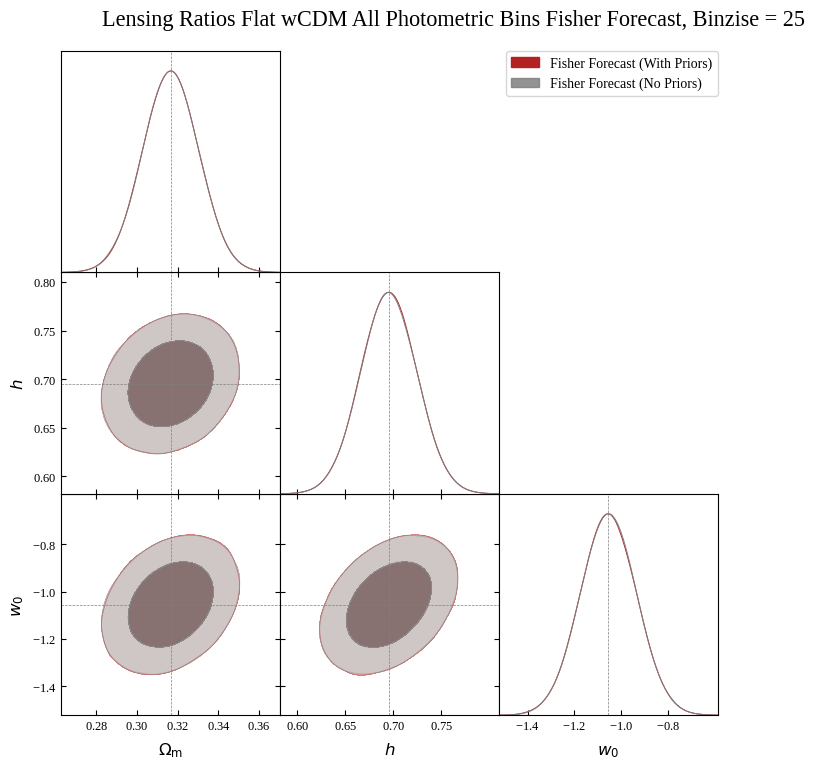

total_time:  0:01:55.551553


In [44]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_wCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=25,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=None,
    cmb_noise_EE=None,
    cmb_noise_TE=None,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['CG', 'GL'],
    cmb_primaries=False,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h', 'w0']
params_to_plot = ['Omega_m', 'h', 'w0']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_wCDM_LR_All_Photometric_Bins_Binsize=25.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h w0',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, w0\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_wCDM_LR_All_Photometric_Bins_Binsize=25.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h w0',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, w0\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Lensing Ratios Flat wCDM All Photometric Bins Fisher Forecast, Binzise = 25",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Plot successfully saved to: plots/Fisher Forecasts/primaries_flat_wcdm_all_photometric_bins_fisher_forecast_binzise_=_25.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.31650\pm 0.00098$ | $\Omega_m = 0.3165^{+0.0019}_{-0.0019}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.31650\pm 0.00098$ | $\Omega_m = 0.3165^{+0.0019}_{-0.0019}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6951\pm 0.0012$ | $h = 0.6951^{+0.0024}_{-0.0024}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6951\pm 0.0012$ | $h = 0.6951^{+0.0024}_{-0.0024}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -1.0550\pm 0.0085$ | $w_0 = -1.055^{+0.017}_{-0.017}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -1.0550\pm 0.0085$ | $w_0 = -1.055^{+0.017}_{-0.017}$ |
| --- | --- | --- | --- |

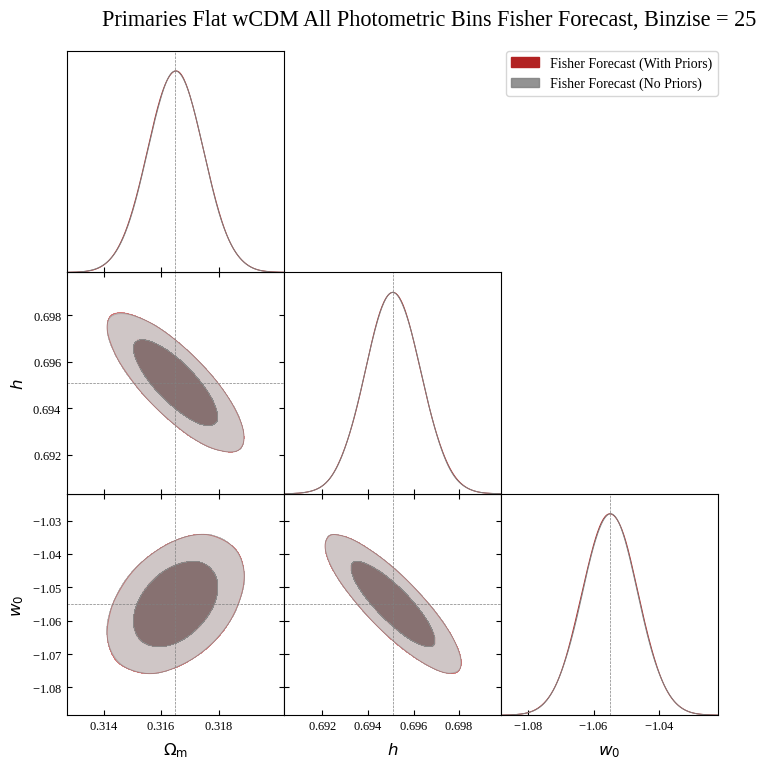

total_time:  0:02:33.950455


In [47]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_wCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=25,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_cmb_noise_TT,
    cmb_noise_EE=SO_cmb_noise_EE,
    cmb_noise_TE=SO_cmb_noise_TE,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['TT', 'TE', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h', 'w0']
params_to_plot = ['Omega_m', 'h', 'w0']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_wCDM_Primaries_All_Photometric_Bins_Binsize=25.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h w0',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, w0\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_wCDM_Primaries_All_Photometric_Bins_Binsize=25.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h w0',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, w0\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Primaries Flat wCDM All Photometric Bins Fisher Forecast, Binzise = 25",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Plot successfully saved to: plots/Fisher Forecasts/lensing_ratios_+_primaries_flat_wcdm_all_photometric_bins_fisher_forecast_binzise_=_25.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.31650\pm 0.00097$ | $\Omega_m = 0.3165^{+0.0019}_{-0.0019}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.31650\pm 0.00097$ | $\Omega_m = 0.3165^{+0.0019}_{-0.0019}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6951\pm 0.0011$ | $h = 0.6951^{+0.0022}_{-0.0022}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6951\pm 0.0011$ | $h = 0.6951^{+0.0022}_{-0.0022}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -1.0550\pm 0.0069$ | $w_0 = -1.055^{+0.013}_{-0.013}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -1.0550\pm 0.0069$ | $w_0 = -1.055^{+0.013}_{-0.013}$ |
| --- | --- | --- | --- |

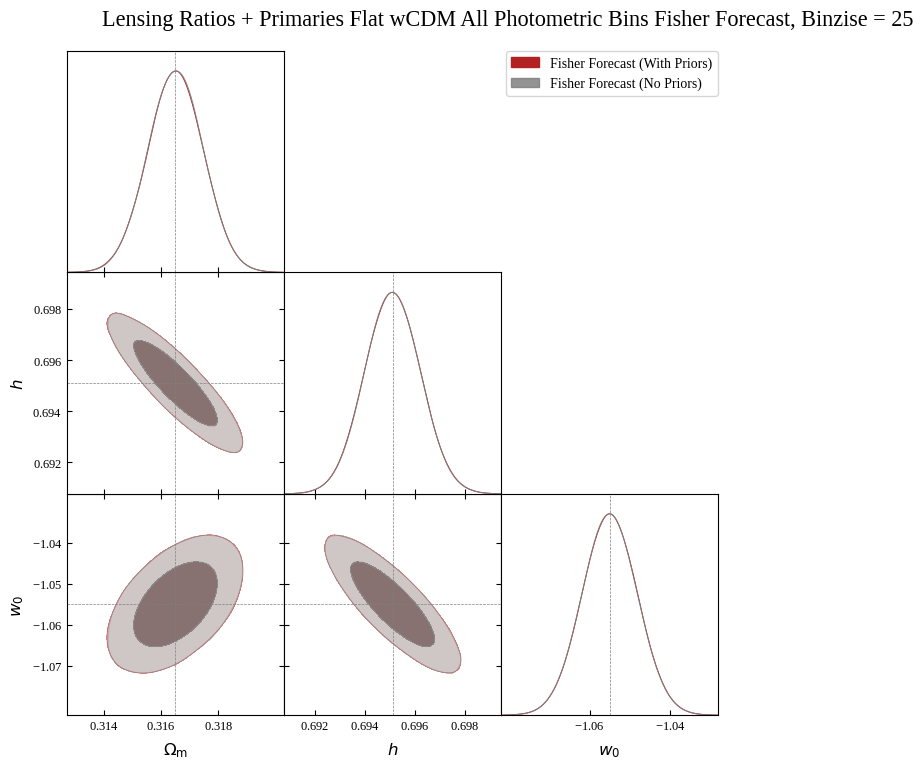

total_time:  0:03:00.267447


In [50]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_wCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=25,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_cmb_noise_TT,
    cmb_noise_EE=SO_cmb_noise_EE,
    cmb_noise_TE=SO_cmb_noise_TE,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['CG', 'GL', 'TT', 'TE', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h', 'w0']
params_to_plot = ['Omega_m', 'h', 'w0']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_wCDM_LRP_All_Photometric_Bins_Binsize=25.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h w0',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, w0\n'
)
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_wCDM_LRP_All_Photometric_Bins_Binsize=25.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h w0',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, w0\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Lensing Ratios + Primaries Flat wCDM All Photometric Bins Fisher Forecast, Binzise = 25",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

### Flat w0waCDM

Plot successfully saved to: plots/Fisher Forecasts/lensing_ratios_flat_w0wa_all_photometric_bins_fisher_forecast_binzise_=_25.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.315\pm 0.020$ | $\Omega_m = 0.315^{+0.040}_{-0.040}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.317\pm 0.021$ | $\Omega_m = 0.317^{+0.040}_{-0.040}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.671\pm 0.039$ | $h = 0.671^{+0.076}_{-0.075}$ |
|  | Fisher Forecast (No Priors) | $h = 0.667\pm 0.039$ | $h = 0.667^{+0.076}_{-0.076}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.76\pm 0.19$ | $w_0 = -0.76^{+0.36}_{-0.38}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.75\pm 0.20$ | $w_0 = -0.75^{+0.38}_{-0.38}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.85\pm 0.57$ | $w_a = -0.9^{+1.1}_{-1.1}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.86\pm 0.58$ | $w_a = -0.9^{+1.1}_{-1.1}$ |
| --- | --- | --- | --- |

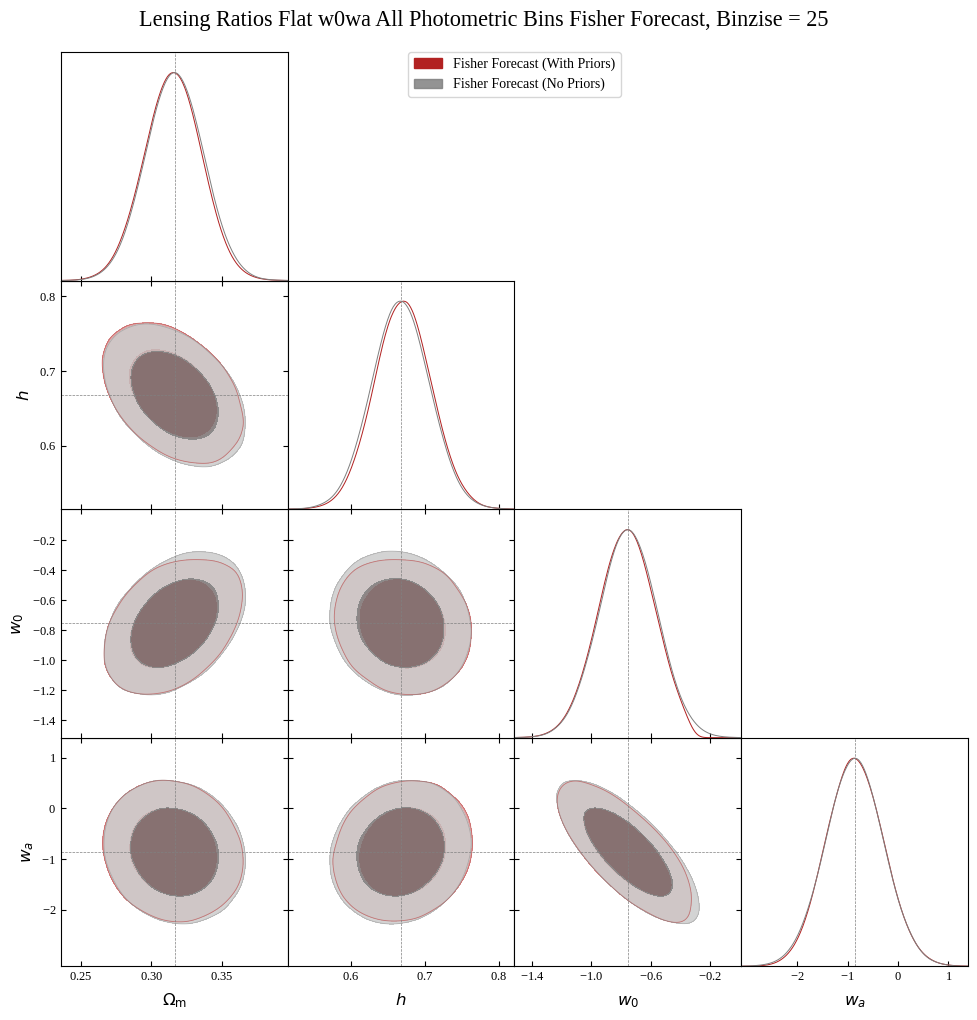

total_time:  0:02:24.783604


In [35]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_w0waCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=25,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=None,
    cmb_noise_EE=None,
    cmb_noise_TE=None,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['CG', 'GL'],
    cmb_primaries=False,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h', 'w0', 'wa']
params_to_plot = ['Omega_m', 'h', 'w0', 'wa']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_w0waCDM_LR_All_Photometric_Bins_Binsize=25.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h w0 wa',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, w0, wa\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_w0waCDM_LR_All_Photometric_Bins_Binsize=25.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h w0 wa',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, w0, wa\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Lensing Ratios Flat w0wa All Photometric Bins Fisher Forecast, Binzise = 25",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Plot successfully saved to: plots/Fisher Forecasts/primaries_flat_w0wa_all_photometric_bins_fisher_forecast_binzise_=_25.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.3166\pm 0.0055$ | $\Omega_m = 0.317^{+0.011}_{-0.011}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3166\pm 0.0055$ | $\Omega_m = 0.317^{+0.011}_{-0.011}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6674\pm 0.0055$ | $h = 0.667^{+0.011}_{-0.011}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6674\pm 0.0055$ | $h = 0.667^{+0.011}_{-0.011}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.752\pm 0.048$ | $w_0 = -0.752^{+0.094}_{-0.094}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.752\pm 0.048$ | $w_0 = -0.752^{+0.094}_{-0.094}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.86\pm 0.21$ | $w_a = -0.86^{+0.41}_{-0.41}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.86\pm 0.21$ | $w_a = -0.86^{+0.41}_{-0.41}$ |
| --- | --- | --- | --- |

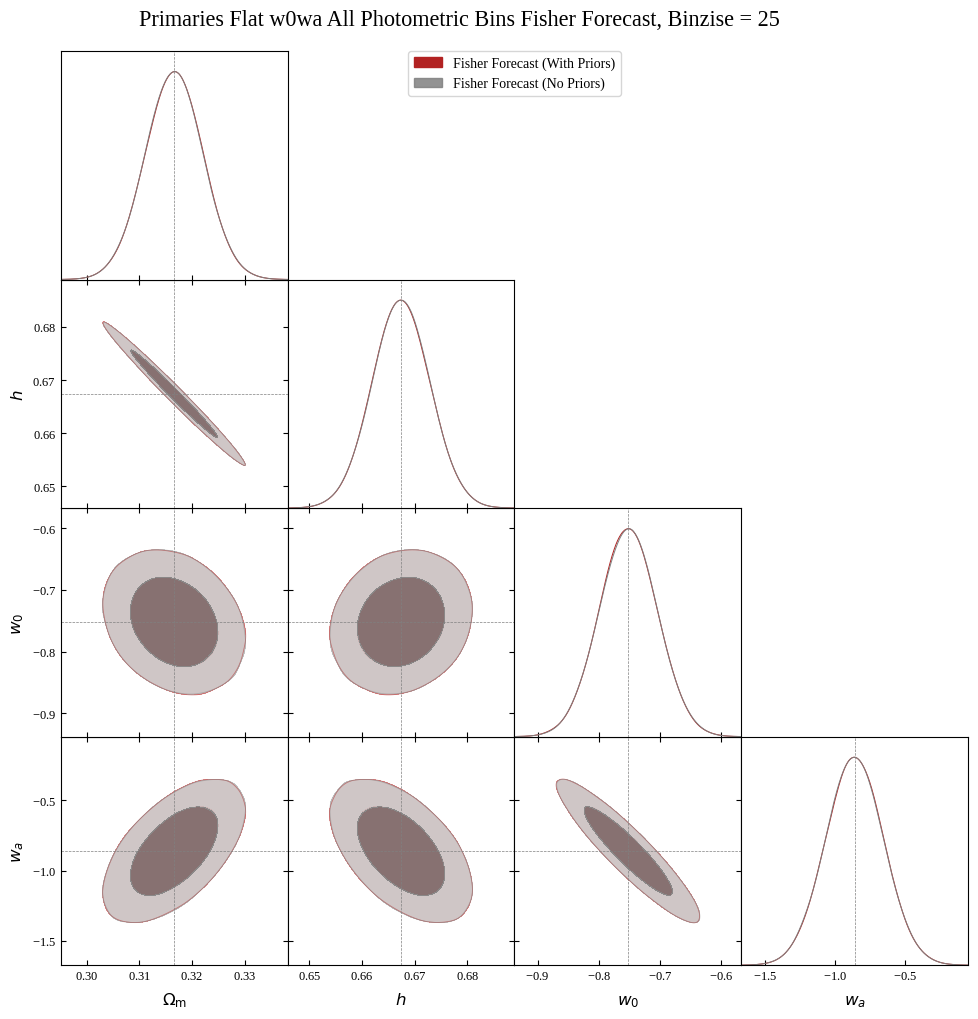

total_time:  0:03:07.916898


In [38]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_w0waCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=25,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_cmb_noise_TT,
    cmb_noise_EE=SO_cmb_noise_EE,
    cmb_noise_TE=SO_cmb_noise_TE,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['TT', 'TE', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h', 'w0', 'wa']
params_to_plot = ['Omega_m', 'h', 'w0', 'wa']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_w0waCDM_Primaries_All_Photometric_Bins_Binsize=25.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h w0 wa',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, w0, wa\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_w0waCDM_Primaries_All_Photometric_Bins_Binsize=25.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h w0 wa',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, w0, wa\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Primaries Flat w0wa All Photometric Bins Fisher Forecast, Binzise = 25",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Plot successfully saved to: plots/Fisher Forecasts/lensing_ratios_+_primaries_flat_w0wa_all_photometric_bins_fisher_forecast_binzise_=_25.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.3166\pm 0.0051$ | $\Omega_m = 0.317^{+0.010}_{-0.010}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3166\pm 0.0051$ | $\Omega_m = 0.317^{+0.010}_{-0.010}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6674\pm 0.0050$ | $h = 0.6674^{+0.0098}_{-0.0098}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6674\pm 0.0050$ | $h = 0.6674^{+0.0099}_{-0.0099}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.752\pm 0.045$ | $w_0 = -0.752^{+0.088}_{-0.088}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.752\pm 0.045$ | $w_0 = -0.752^{+0.088}_{-0.088}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.86\pm 0.19$ | $w_a = -0.86^{+0.37}_{-0.37}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.86\pm 0.19$ | $w_a = -0.86^{+0.37}_{-0.37}$ |
| --- | --- | --- | --- |

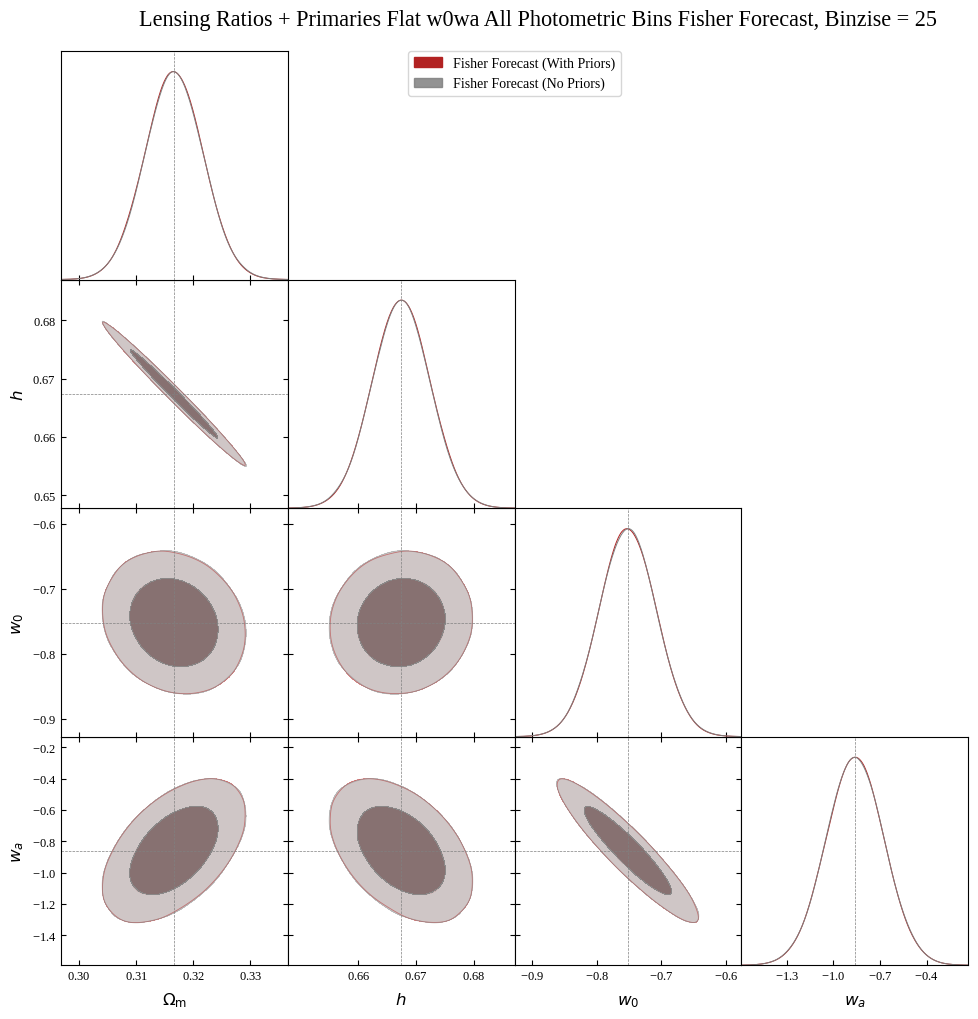

total_time:  0:03:41.523052


In [41]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_w0waCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=25,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_cmb_noise_TT,
    cmb_noise_EE=SO_cmb_noise_EE,
    cmb_noise_TE=SO_cmb_noise_TE,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['CG', 'GL', 'TT', 'TE', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h', 'w0', 'wa']
params_to_plot = ['Omega_m', 'h', 'w0', 'wa']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_w0waCDM_LRP_All_Photometric_Bins_Binsize=25.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h w0 wa',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, w0, wa\n'
)
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_w0waCDM_LRP_All_Photometric_Bins_Binsize=25.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h w0 wa',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, w0, wa\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Lensing Ratios + Primaries Flat w0wa All Photometric Bins Fisher Forecast, Binzise = 25",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

### Curved w0waCDM

Plot successfully saved to: plots/Fisher Forecasts/lensing_ratios_curved_w0wa_all_photometric_bins_fisher_forecast_binzise_=_25.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.315\pm 0.020$ | $\Omega_m = 0.315^{+0.040}_{-0.040}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.317\pm 0.021$ | $\Omega_m = 0.317^{+0.040}_{-0.041}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.670\pm 0.040$ | $h = 0.670^{+0.079}_{-0.078}$ |
|  | Fisher Forecast (No Priors) | $h = 0.667\pm 0.040$ | $h = 0.667^{+0.079}_{-0.079}$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Fisher Forecast (With Priors) | $\Omega_k = -0.001\pm 0.021$ | $\Omega_k = -0.001^{+0.042}_{-0.042}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.000\pm 0.022$ | $\Omega_k = 0.000^{+0.042}_{-0.042}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.77\pm 0.19$ | $w_0 = -0.77^{+0.38}_{-0.37}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.75\pm 0.20$ | $w_0 = -0.75^{+0.39}_{-0.39}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.84\pm 0.57$ | $w_a = -0.8^{+1.1}_{-1.1}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.86\pm 0.58$ | $w_a = -0.9^{+1.1}_{-1.1}$ |
| --- | --- | --- | --- |

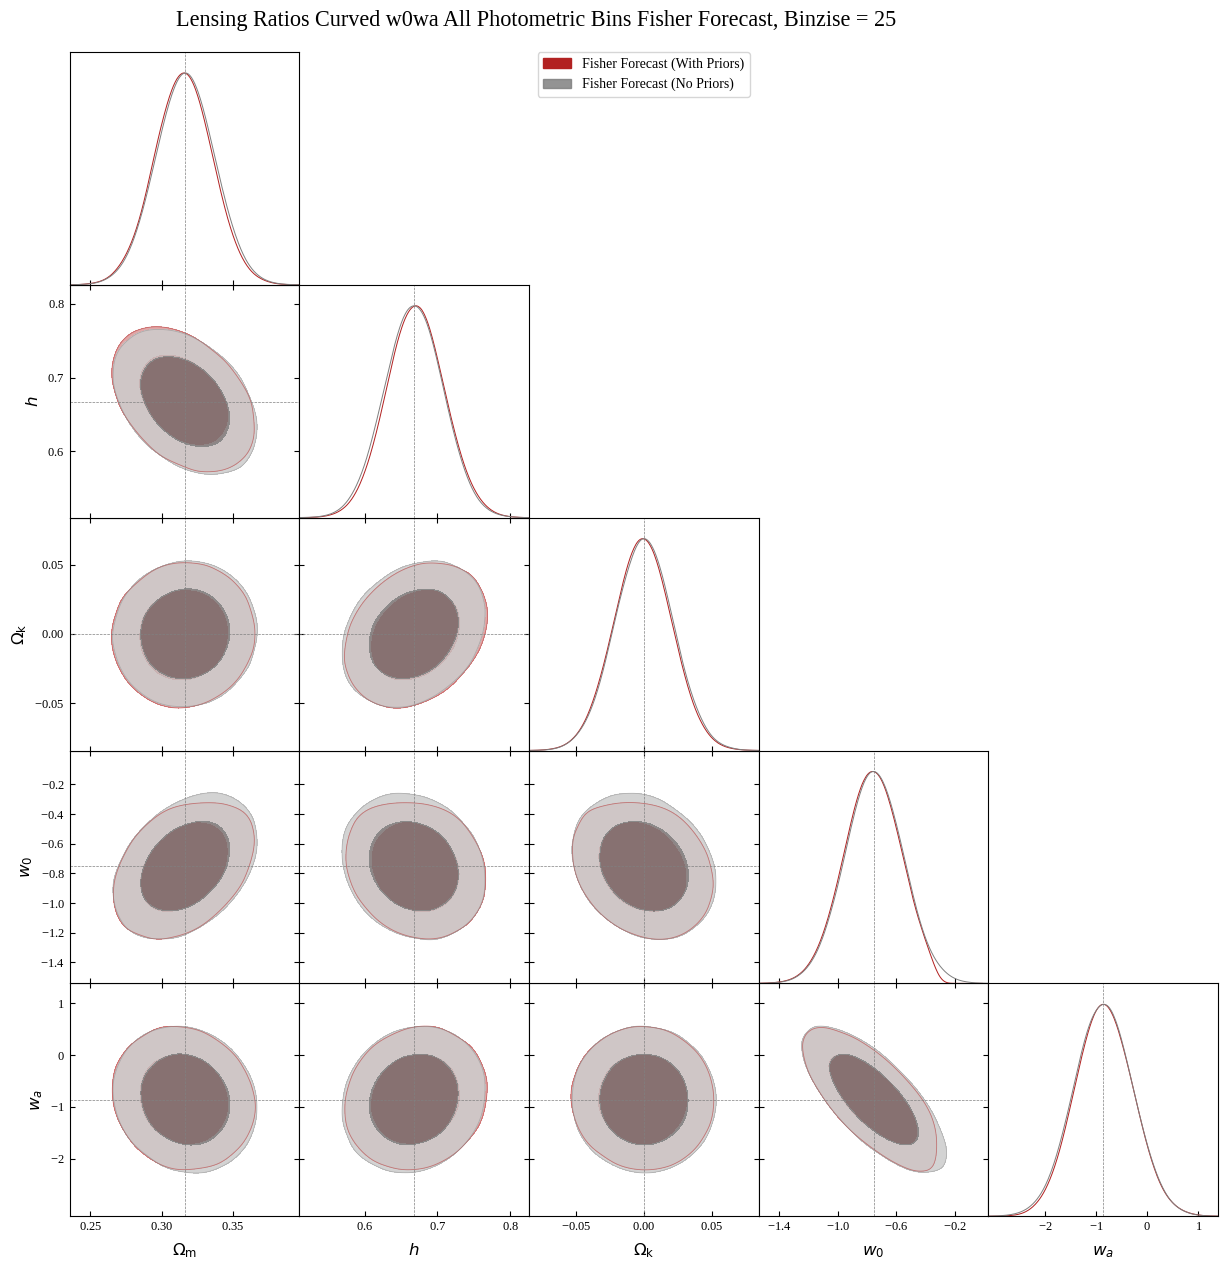

total_time:  0:02:59.780530


In [19]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=curved_w0waCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=25,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=None,
    cmb_noise_EE=None,
    cmb_noise_TE=None,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['CG', 'GL'],
    cmb_primaries=False,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h', 'Omega_k', 'w0', 'wa']
params_to_plot = ['Omega_m', 'h', 'Omega_k', 'w0', 'wa']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Curved_w0waCDM_LR_All_Photometric_Bins_Binsize=25.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h Omega_k w0 wa',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, Omega_k, w0, wa\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Curved_w0waCDM_LR_All_Photometric_Bins_Binsize=25.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h Omega_k w0 wa',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, Omega_k, w0, wa\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Lensing Ratios Curved w0wa All Photometric Bins Fisher Forecast, Binzise = 25",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Plot successfully saved to: plots/Fisher Forecasts/primaries_curved_w0wa_all_photometric_bins_fisher_forecast_binzise_=_25.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.3166\pm 0.0058$ | $\Omega_m = 0.317^{+0.011}_{-0.011}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3166\pm 0.0058$ | $\Omega_m = 0.317^{+0.011}_{-0.011}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6674\pm 0.0062$ | $h = 0.667^{+0.012}_{-0.012}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6674\pm 0.0062$ | $h = 0.667^{+0.012}_{-0.012}$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Fisher Forecast (With Priors) | $\Omega_k = 0.0000\pm 0.0017$ | $\Omega_k = 0.0000^{+0.0033}_{-0.0033}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.0000\pm 0.0017$ | $\Omega_k = 0.0000^{+0.0033}_{-0.0033}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.752\pm 0.063$ | $w_0 = -0.75^{+0.12}_{-0.12}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.752\pm 0.063$ | $w_0 = -0.75^{+0.12}_{-0.12}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.86\pm 0.24$ | $w_a = -0.86^{+0.47}_{-0.47}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.86\pm 0.24$ | $w_a = -0.86^{+0.47}_{-0.47}$ |
| --- | --- | --- | --- |

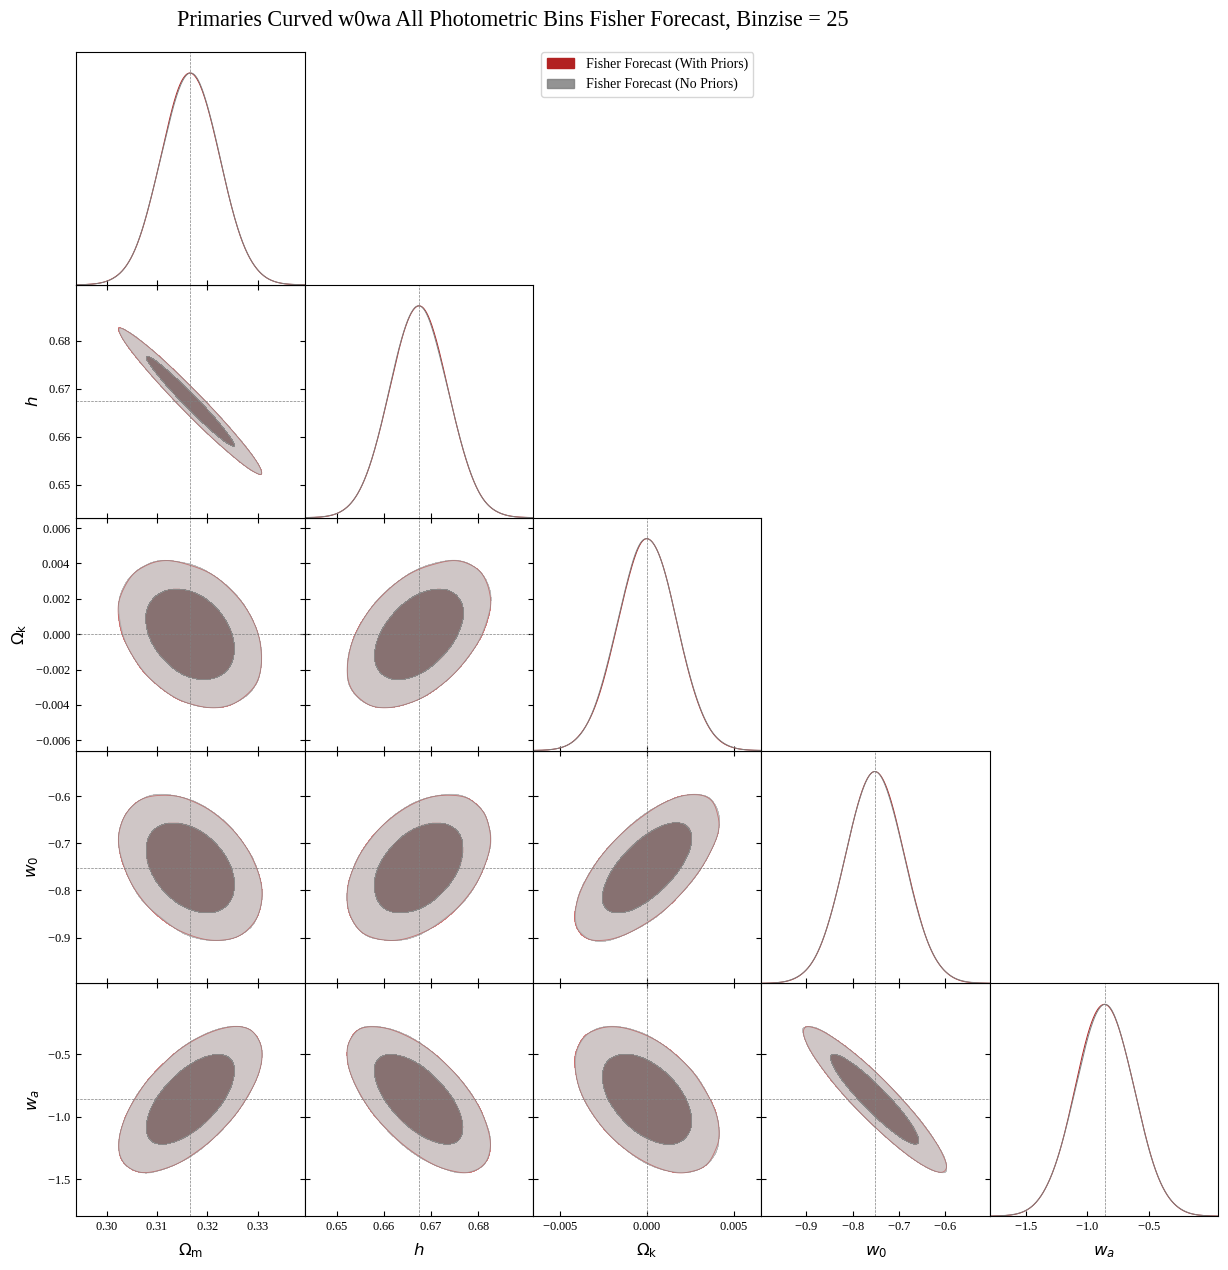

total_time:  0:03:39.601325


In [22]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=curved_w0waCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=25,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_cmb_noise_TT,
    cmb_noise_EE=SO_cmb_noise_EE,
    cmb_noise_TE=SO_cmb_noise_TE,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['TT', 'TE', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h', 'Omega_k', 'w0', 'wa']
params_to_plot = ['Omega_m', 'h', 'Omega_k', 'w0', 'wa']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Curved_w0waCDM_Primaries_All_Photometric_Bins_Binsize=25.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h Omega_k w0 wa',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, Omega_k, w0, wa\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Curved_w0waCDM_Primaries_All_Photometric_Bins_Binsize=25.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h Omega_k w0 wa',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, Omega_k, w0, wa\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Primaries Curved w0wa All Photometric Bins Fisher Forecast, Binzise = 25",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Plot successfully saved to: plots/Fisher Forecasts/lensing_ratios_+_primaries_curved_w0wa_all_photometric_bins_fisher_forecast_binzise_=_25.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.3166\pm 0.0054$ | $\Omega_m = 0.317^{+0.010}_{-0.011}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3166\pm 0.0053$ | $\Omega_m = 0.317^{+0.010}_{-0.011}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6674\pm 0.0057$ | $h = 0.667^{+0.011}_{-0.011}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6674\pm 0.0057$ | $h = 0.667^{+0.011}_{-0.011}$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Fisher Forecast (With Priors) | $\Omega_k = 0.0000\pm 0.0016$ | $\Omega_k = 0.0000^{+0.0032}_{-0.0032}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.0000\pm 0.0016$ | $\Omega_k = 0.0000^{+0.0032}_{-0.0032}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.752\pm 0.058$ | $w_0 = -0.75^{+0.11}_{-0.11}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.752\pm 0.058$ | $w_0 = -0.75^{+0.11}_{-0.11}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.86\pm 0.21$ | $w_a = -0.86^{+0.42}_{-0.41}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.86\pm 0.21$ | $w_a = -0.86^{+0.41}_{-0.41}$ |
| --- | --- | --- | --- |

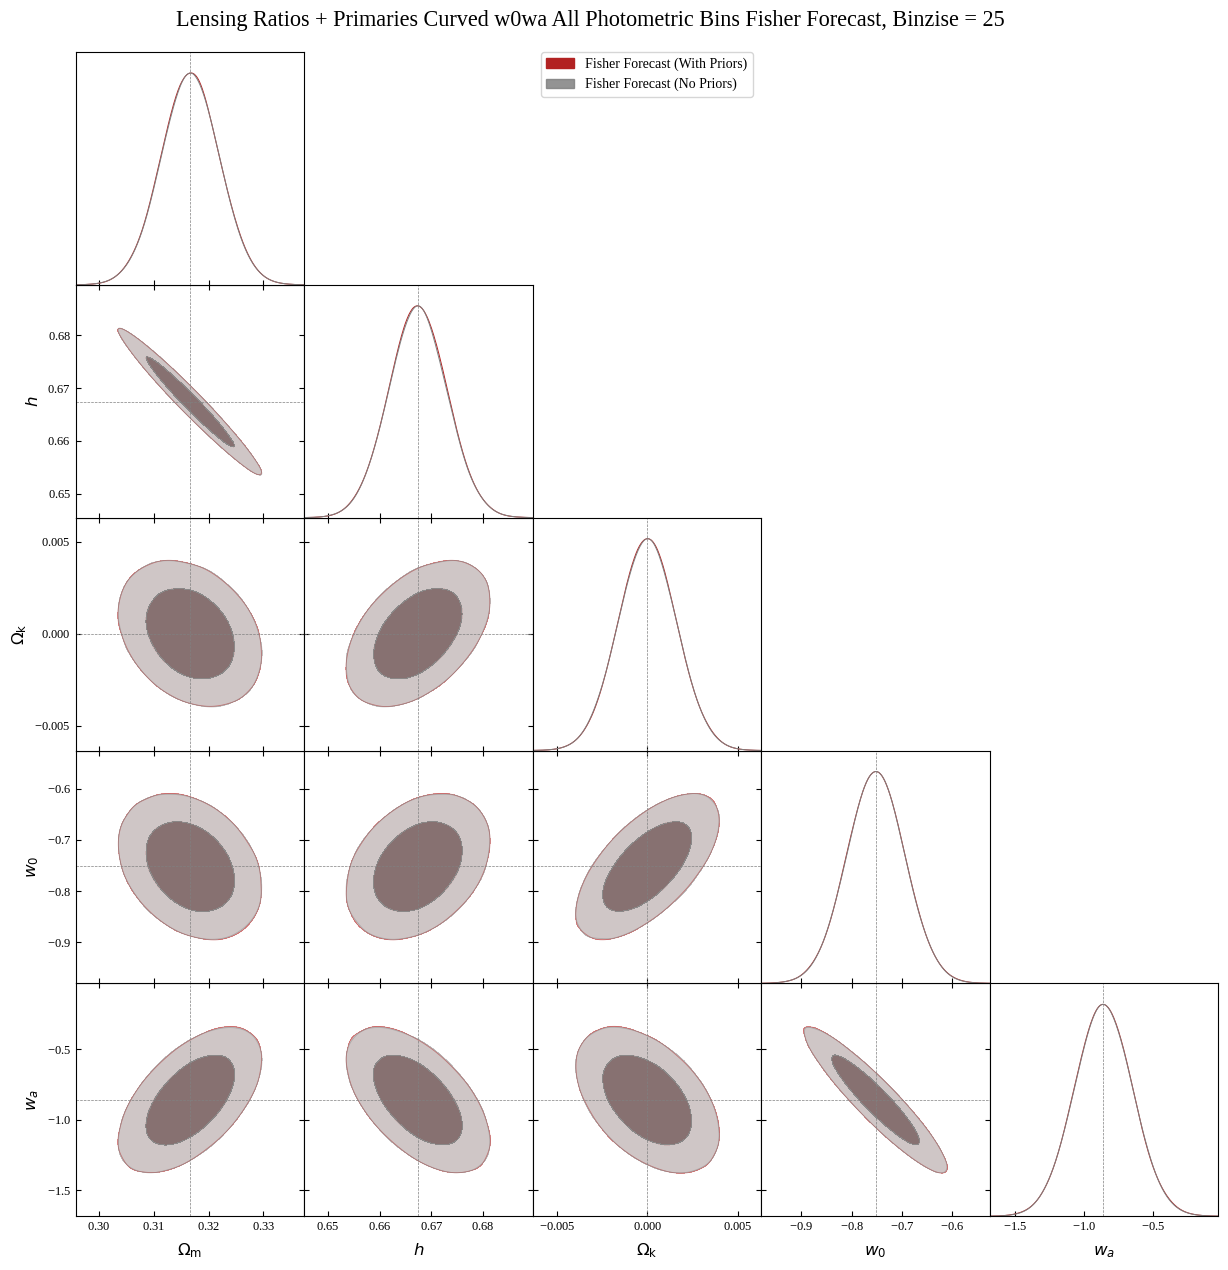

total_time:  0:04:35.403211


In [25]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=curved_w0waCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=25,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_cmb_noise_TT,
    cmb_noise_EE=SO_cmb_noise_EE,
    cmb_noise_TE=SO_cmb_noise_TE,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['CG', 'GL', 'TT', 'TE', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h', 'Omega_k', 'w0', 'wa']
params_to_plot = ['Omega_m', 'h', 'Omega_k', 'w0', 'wa']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Curved_w0waCDM_LRP_All_Photometric_Bins_Binsize=25.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h Omega_k w0 wa',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, Omega_k, w0, wa\n'
)
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Curved_w0waCDM_LRP_All_Photometric_Bins_Binsize=25.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h Omega_k w0 wa',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, Omega_k, w0, wa\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Lensing Ratios + Primaries Curved w0wa All Photometric Bins Fisher Forecast, Binzise = 25",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

## Binsize Tests -- Timing, Errors, Spectra

### Summary Plots

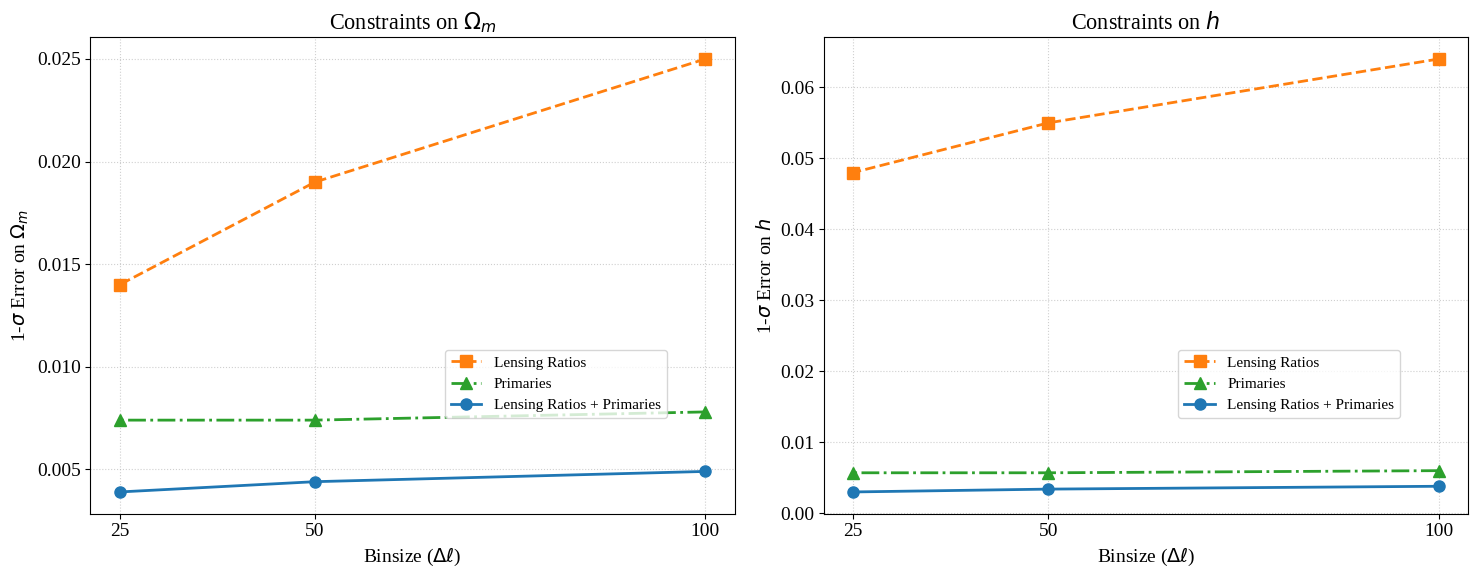

In [30]:
# plot results
binsizes = [100, 50, 25]

# 2. Dictionary for your 1-sigma errors (Y-axis) using raw strings
errors_Omega_m = {
    'Lensing Ratios': [0.025, 0.019, 0.014],
    'Primaries': [0.0078, 0.0074, 0.0074],
    'Lensing Ratios + Primaries': [0.0049, 0.0044, 0.0039]
}
errors_h = {
    'Lensing Ratios': [0.064, 0.055, 0.048],
    'Primaries': [0.0060, 0.0057, 0.0057],
    'Lensing Ratios + Primaries': [0.0038, 0.0034, 0.0030]
}

# 3. Plotting Configuration

#omega_m, h
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharex=True)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Liberation Serif'
plt.rcParams['font.size'] = 14

# Complete styling markers and colors mapping with matching raw prefixes
styles = {
    'Lensing Ratios + Primaries': {'color': '#1f77b4', 'marker': 'o', 'ls': '-'},
    'Lensing Ratios': {'color': '#ff7f0e', 'marker': 's', 'ls': '--'},
    'Primaries': {'color': '#2ca02c', 'marker': '^', 'ls': '-.'}
}

# --- Left Subplot: Omega_m Errors ---
for label, err_list in errors_Omega_m.items():
    ax1.plot(binsizes, err_list, label=label, **styles[label], lw=2, ms=8)
ax1.set_ylabel(r'1-$\sigma$ Error on $\Omega_m$', fontsize=14)
ax1.set_xlabel(r'Binsize ($\Delta \ell$)', fontsize=14)
ax1.set_title(r'Constraints on $\Omega_m$', fontsize=16)
ax1.set_xticks(binsizes)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(frameon=True, fontsize=11, loc=(0.55, 0.20))

# --- Middle Subplot: h Errors ---
for label, err_list in errors_h.items():
    ax2.plot(binsizes, err_list, label=label, **styles[label], lw=2, ms=8)
ax2.set_ylabel(r'1-$\sigma$ Error on $h$', fontsize=14)
ax2.set_xlabel(r'Binsize ($\Delta \ell$)', fontsize=14)
ax2.set_title(r'Constraints on $h$', fontsize=16)
ax2.set_xticks(binsizes)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(frameon=True, fontsize=11, loc=(0.55, 0.20))

plt.tight_layout()
plt.show()

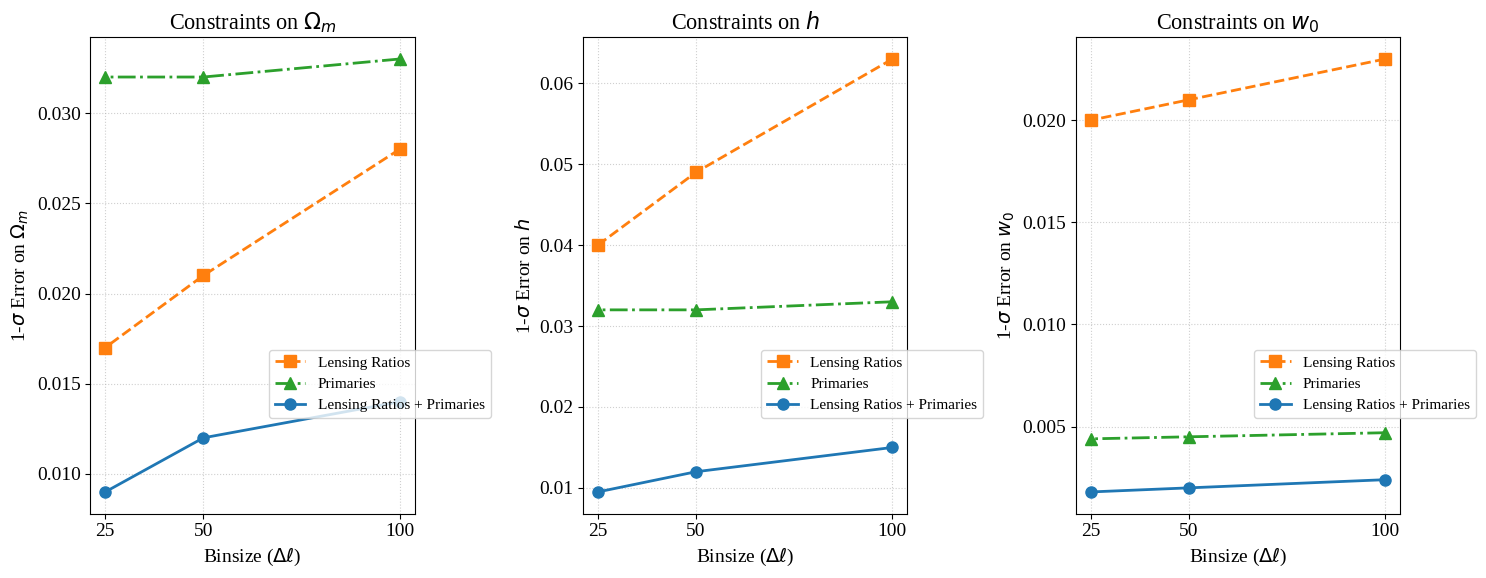

In [32]:
# plot results

binsizes = [100, 50, 25]

# Dictionary for your 1-sigma errors (Y-axis) using raw strings
errors_Omega_m = {
    'Lensing Ratios': [0.028, 0.021, 0.017],
    'Primaries': [0.033, 0.032, 0.032],
    'Lensing Ratios + Primaries': [0.014, 0.012, 0.0090]
}
errors_h = {
    'Lensing Ratios': [0.063, 0.049, 0.040],
    'Primaries': [0.033, 0.032, 0.032],
    'Lensing Ratios + Primaries': [0.015, 0.012, 0.0095]
}
errors_Omega_k = {
    'Lensing Ratios': [0.023, 0.021, 0.020],
    'Primaries': [0.0047, 0.0045, 0.0044],
    'Lensing Ratios + Primaries': [0.0024, 0.0020, 0.0018]
}

# 3. Plotting Configuration

#omega_m, h, omega_k
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 6), sharex=True)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Liberation Serif'
plt.rcParams['font.size'] = 14

# Complete styling markers and colors mapping with matching raw prefixes
styles = {
    'Lensing Ratios + Primaries': {'color': '#1f77b4', 'marker': 'o', 'ls': '-'},
    'Lensing Ratios': {'color': '#ff7f0e', 'marker': 's', 'ls': '--'},
    'Primaries': {'color': '#2ca02c', 'marker': '^', 'ls': '-.'}
}

# --- Left Subplot: Omega_m Errors ---
for label, err_list in errors_Omega_m.items():
    ax1.plot(binsizes, err_list, label=label, **styles[label], lw=2, ms=8)
ax1.set_ylabel(r'1-$\sigma$ Error on $\Omega_m$', fontsize=14)
ax1.set_xlabel(r'Binsize ($\Delta \ell$)', fontsize=14)
ax1.set_title(r'Constraints on $\Omega_m$', fontsize=16)
ax1.set_xticks(binsizes)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(frameon=True, fontsize=11, loc=(0.55, 0.20))

# --- Middle Subplot: h Errors ---
for label, err_list in errors_h.items():
    ax2.plot(binsizes, err_list, label=label, **styles[label], lw=2, ms=8)
ax2.set_ylabel(r'1-$\sigma$ Error on $h$', fontsize=14)
ax2.set_xlabel(r'Binsize ($\Delta \ell$)', fontsize=14)
ax2.set_title(r'Constraints on $h$', fontsize=16)
ax2.set_xticks(binsizes)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(frameon=True, fontsize=11, loc=(0.55, 0.20))

# --- Right Subplot: Omega_k Errors ---
for label, err_list in errors_Omega_k.items():
    ax3.plot(binsizes, err_list, label=label, **styles[label], lw=2, ms=8)
ax3.set_ylabel(r'1-$\sigma$ Error on $w_0$', fontsize=14)
ax3.set_xlabel(r'Binsize ($\Delta \ell$)', fontsize=14)
ax3.set_title(r'Constraints on $w_0$', fontsize=16)
ax3.set_xticks(binsizes)
ax3.grid(True, linestyle=':', alpha=0.6)
ax3.legend(frameon=True, fontsize=11, loc=(0.55, 0.20))

plt.tight_layout()
plt.show()

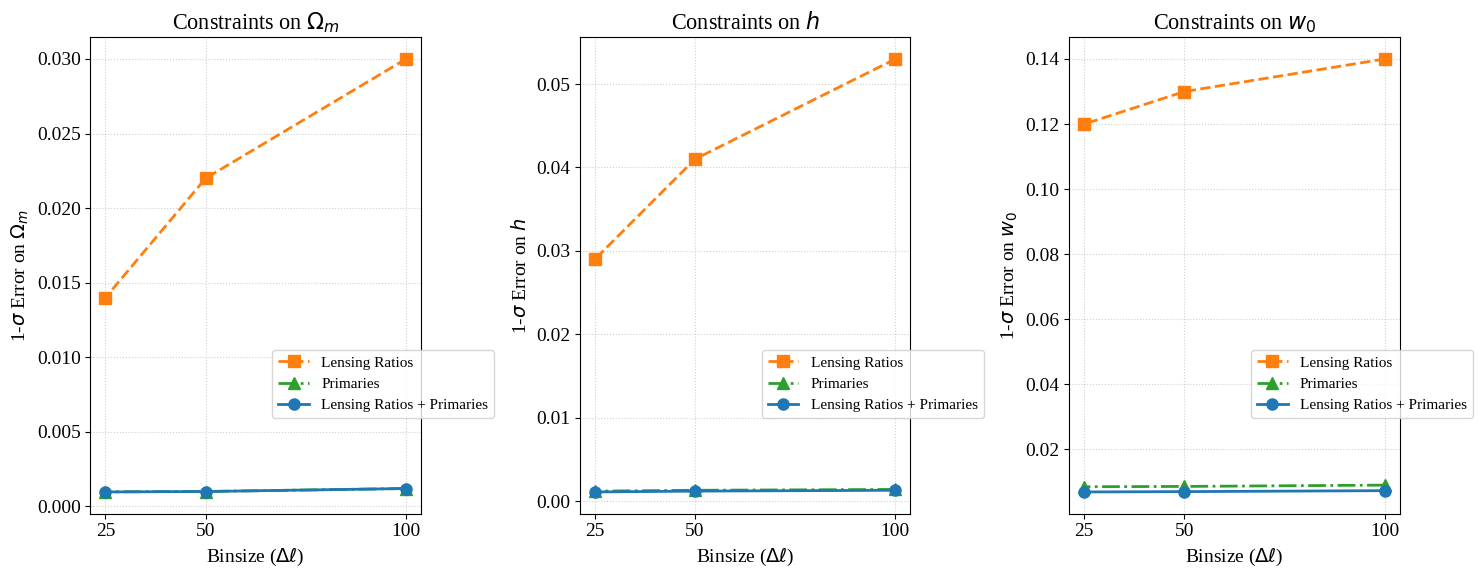

In [34]:
# plot results
binsizes = [100, 50, 25]

# 2. Dictionary for your 1-sigma errors (Y-axis) using raw strings
errors_Omega_m = {
    'Lensing Ratios': [0.030, 0.022, 0.014],
    'Primaries': [0.0012, 0.0010, 0.00098],
    'Lensing Ratios + Primaries': [0.0012, 0.0010, 0.00097]
}
errors_h = {
    'Lensing Ratios': [0.053, 0.041, 0.029],
    'Primaries': [0.0014, 0.0013, 0.0012],
    'Lensing Ratios + Primaries': [0.0013, 0.0012, 0.0011]
}
errors_w0 = {
    'Lensing Ratios': [0.14, 0.13, 0.12],
    'Primaries': [0.0090, 0.0086, 0.0085],
    'Lensing Ratios + Primaries': [0.0073, 0.0070, 0.0069]
}

# 3. Plotting Configuration

#omega_m, h, w0
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 6), sharex=True)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Liberation Serif'
plt.rcParams['font.size'] = 14

# Complete styling markers and colors mapping with matching raw prefixes
styles = {
    'Lensing Ratios + Primaries': {'color': '#1f77b4', 'marker': 'o', 'ls': '-'},
    'Lensing Ratios': {'color': '#ff7f0e', 'marker': 's', 'ls': '--'},
    'Primaries': {'color': '#2ca02c', 'marker': '^', 'ls': '-.'}
}

# --- Left Subplot: Omega_m Errors ---
for label, err_list in errors_Omega_m.items():
    ax1.plot(binsizes, err_list, label=label, **styles[label], lw=2, ms=8)
ax1.set_ylabel(r'1-$\sigma$ Error on $\Omega_m$', fontsize=14)
ax1.set_xlabel(r'Binsize ($\Delta \ell$)', fontsize=14)
ax1.set_title(r'Constraints on $\Omega_m$', fontsize=16)
ax1.set_xticks(binsizes)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(frameon=True, fontsize=11, loc=(0.55, 0.20))

# --- Middle Subplot: h Errors ---
for label, err_list in errors_h.items():
    ax2.plot(binsizes, err_list, label=label, **styles[label], lw=2, ms=8)
ax2.set_ylabel(r'1-$\sigma$ Error on $h$', fontsize=14)
ax2.set_xlabel(r'Binsize ($\Delta \ell$)', fontsize=14)
ax2.set_title(r'Constraints on $h$', fontsize=16)
ax2.set_xticks(binsizes)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(frameon=True, fontsize=11, loc=(0.55, 0.20))

# --- Right Subplot: w0 Errors ---
for label, err_list in errors_w0.items():
    ax3.plot(binsizes, err_list, label=label, **styles[label], lw=2, ms=8)
ax3.set_ylabel(r'1-$\sigma$ Error on $w_0$', fontsize=14)
ax3.set_xlabel(r'Binsize ($\Delta \ell$)', fontsize=14)
ax3.set_title(r'Constraints on $w_0$', fontsize=16)
ax3.set_xticks(binsizes)
ax3.grid(True, linestyle=':', alpha=0.6)
ax3.legend(frameon=True, fontsize=11, loc=(0.55, 0.20))

plt.tight_layout()
plt.show()

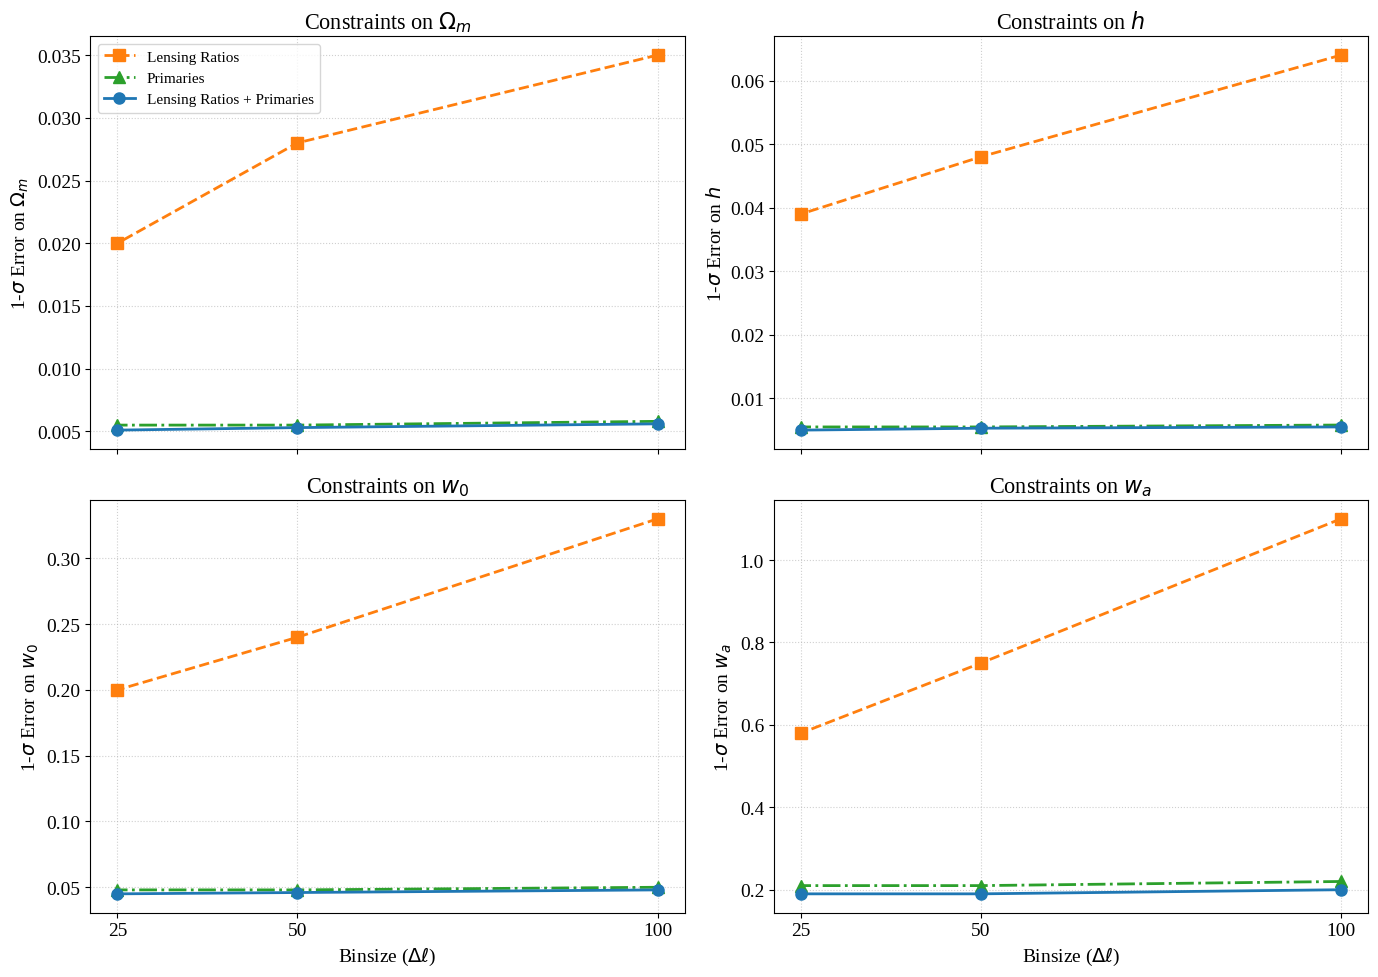

In [38]:
# plot results

binsizes = [100, 50, 25]

# 2. Dictionary for your 1-sigma errors (Y-axis) using raw strings
errors_Omega_m = {
    'Lensing Ratios': [0.035, 0.028, 0.020],
    'Primaries': [0.0058, 0.0055, 0.0055],
    'Lensing Ratios + Primaries': [0.0056, 0.0053, 0.0051]
}
errors_h = {
    'Lensing Ratios': [0.064, 0.048, 0.039],
    'Primaries': [0.0058, 0.0055, 0.0055],
    'Lensing Ratios + Primaries': [0.0055, 0.0053, 0.0050] 
}
errors_w0 = {
    'Lensing Ratios': [0.33, 0.24, 0.20],
    'Primaries': [0.050, 0.048, 0.048],
    'Lensing Ratios + Primaries': [0.048, 0.046, 0.045] 
}
errors_wa = {
    'Lensing Ratios': [1.1, 0.75, 0.58],
    'Primaries': [0.22, 0.21, 0.21],
    'Lensing Ratios + Primaries': [0.20, 0.19, 0.19] 
}

# 3. Plotting Configuration
# 1. Create a 2x2 grid of subplots
fig, axs = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Liberation Serif'
plt.rcParams['font.size'] = 14

# Unpack the 2x2 grid layout
ax11, ax12 = axs[0, 0], axs[0, 1]  # Row 1: Omega_m and h
ax21, ax22 = axs[1, 0], axs[1, 1]  # Row 2: w0 and wa

# Consistent styling configuration
styles = {
    'Lensing Ratios + Primaries': {'color': '#1f77b4', 'marker': 'o', 'ls': '-'},
    'Lensing Ratios': {'color': '#ff7f0e', 'marker': 's', 'ls': '--'},
    'Primaries': {'color': '#2ca02c', 'marker': '^', 'ls': '-.'}
}

# --- Top-Left: Omega_m Errors ---
for label, err_list in errors_Omega_m.items():
    ax11.plot(binsizes, err_list, label=label, **styles[label], lw=2, ms=8)
ax11.set_ylabel(r'1-$\sigma$ Error on $\Omega_m$', fontsize=14)
ax11.set_title(r'Constraints on $\Omega_m$', fontsize=16)
ax11.grid(True, linestyle=':', alpha=0.6)
ax11.legend(frameon=True, fontsize=11, loc='best')

# --- Top-Right: h Errors ---
for label, err_list in errors_h.items():
    ax12.plot(binsizes, err_list, label=label, **styles[label], lw=2, ms=8)
ax12.set_ylabel(r'1-$\sigma$ Error on $h$', fontsize=14)
ax12.set_title(r'Constraints on $h$', fontsize=16)
ax12.grid(True, linestyle=':', alpha=0.6)

# --- Bottom-Left: w0 Errors ---
for label, err_list in errors_w0.items():
    ax21.plot(binsizes, err_list, label=label, **styles[label], lw=2, ms=8)
ax21.set_ylabel(r'1-$\sigma$ Error on $w_0$', fontsize=14)
ax21.set_xlabel(r'Binsize ($\Delta \ell$)', fontsize=14)
ax21.set_title(r'Constraints on $w_0$', fontsize=16)
ax21.set_xticks(binsizes)
ax21.grid(True, linestyle=':', alpha=0.6)

# --- Bottom-Right: wa Errors ---
for label, err_list in errors_wa.items():
    ax22.plot(binsizes, err_list, label=label, **styles[label], lw=2, ms=8)
ax22.set_ylabel(r'1-$\sigma$ Error on $w_a$', fontsize=14)
ax22.set_xlabel(r'Binsize ($\Delta \ell$)', fontsize=14)
ax22.set_title(r'Constraints on $w_a$', fontsize=16)
ax22.set_xticks(binsizes)
ax22.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

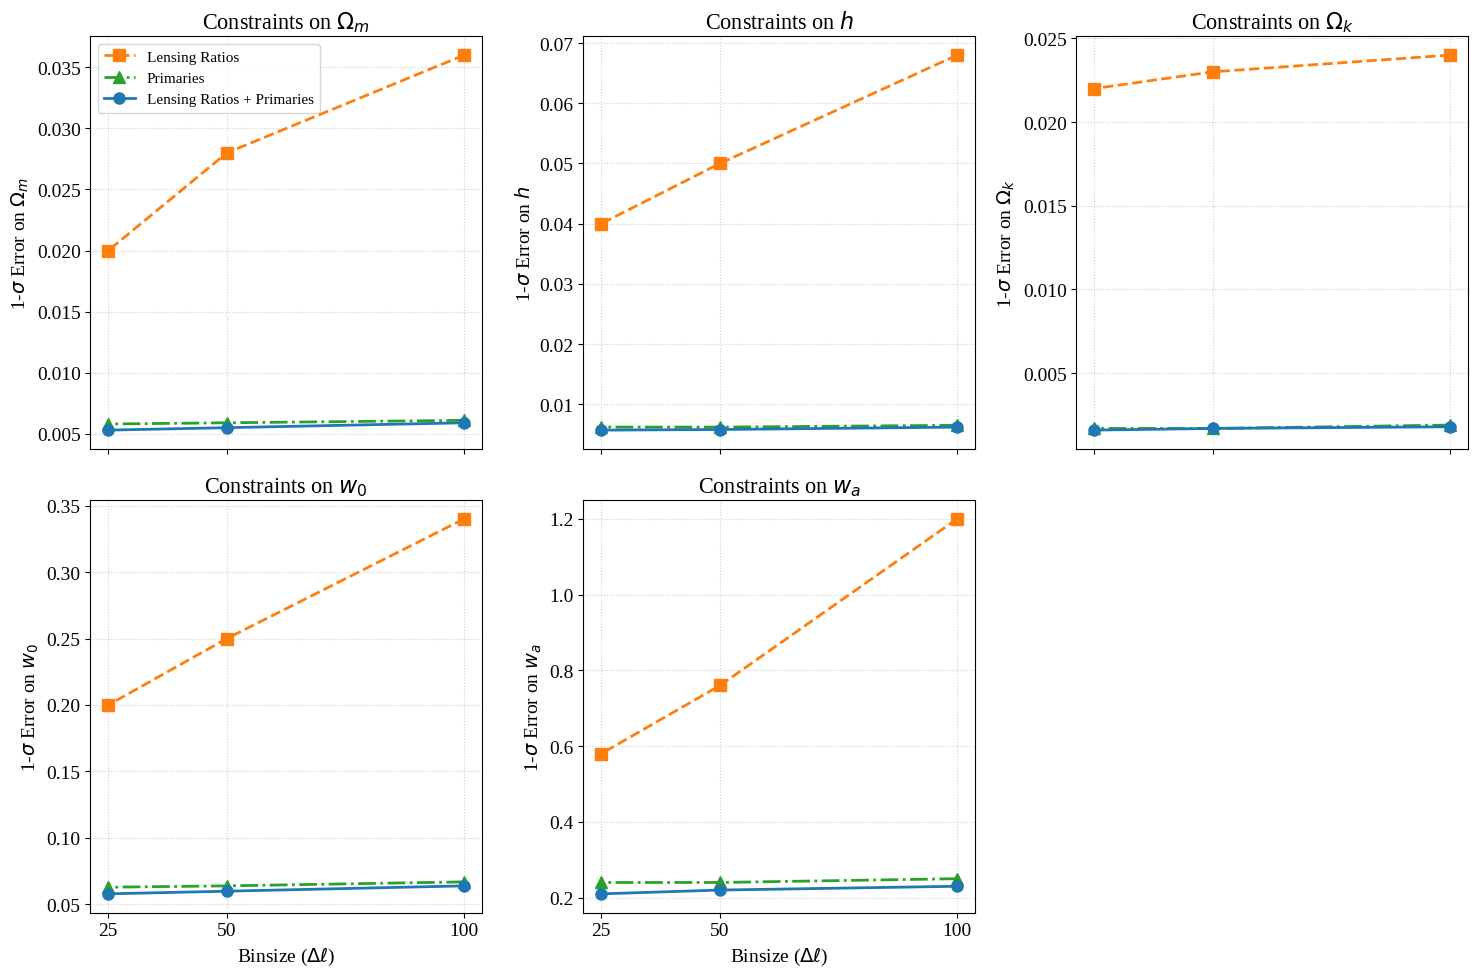

In [37]:
# plot results

binsizes = [100, 50, 25]

# 2. Dictionary for your 1-sigma errors (Y-axis) using raw strings
errors_Omega_m = {
    'Lensing Ratios': [0.036, 0.028, 0.020],
    'Primaries': [0.0061, 0.0059, 0.0058],
    'Lensing Ratios + Primaries': [0.0059, 0.0055, 0.0053]
}
errors_h = {
    'Lensing Ratios': [0.068, 0.050, 0.040],
    'Primaries': [0.0065, 0.0062, 0.0062],
    'Lensing Ratios + Primaries': [0.0062, 0.0058, 0.0057]
}
errors_Omega_k = {
    'Lensing Ratios': [0.024, 0.023, 0.022],
    'Primaries': [0.0019, 0.0017, 0.0017],
    'Lensing Ratios + Primaries': [0.0018, 0.0017, 0.0016]
}
errors_w0 = {
    'Lensing Ratios': [0.34, 0.25, 0.20],
    'Primaries': [0.067, 0.064, 0.063],
    'Lensing Ratios + Primaries': [0.064, 0.060, 0.058]
}
errors_wa = {
    'Lensing Ratios': [1.2, 0.76, 0.58],
    'Primaries': [0.25, 0.24, 0.24],
    'Lensing Ratios + Primaries': [0.23, 0.22, 0.21]
}

# 3. Plotting Configuration
# 1. Create a 2x3 grid of subplots
fig, axs = plt.subplots(2, 3, figsize=(15, 10), sharex=True)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Liberation Serif'
plt.rcParams['font.size'] = 14

# Unpack the first row (3 plots)
ax11, ax12, ax13 = axs[0, 0], axs[0, 1], axs[0, 2]
# Unpack the second row (2 plots + 1 extra we will remove)
ax21, ax22, ax23 = axs[1, 0], axs[1, 1], axs[1, 2]

# Remove the unused 6th subplot slot and center the other two rows slightly if desired,
# or simply leave it blank. Removing it keeps it clean:
fig.delaxes(ax23)

# Style configuration
styles = {
    'Lensing Ratios + Primaries': {'color': '#1f77b4', 'marker': 'o', 'ls': '-'},
    'Lensing Ratios': {'color': '#ff7f0e', 'marker': 's', 'ls': '--'},
    'Primaries': {'color': '#2ca02c', 'marker': '^', 'ls': '-.'}
}

# --- Ax11: Omega_m Errors ---
for label, err_list in errors_Omega_m.items():
    ax11.plot(binsizes, err_list, label=label, **styles[label], lw=2, ms=8)
ax11.set_ylabel(r'1-$\sigma$ Error on $\Omega_m$', fontsize=14)
ax11.set_title(r'Constraints on $\Omega_m$', fontsize=16)
ax11.set_xticks(binsizes)
ax11.grid(True, linestyle=':', alpha=0.6)
ax11.legend(frameon=True, fontsize=11)

# --- Ax12: h Errors ---
for label, err_list in errors_h.items():
    ax12.plot(binsizes, err_list, label=label, **styles[label], lw=2, ms=8)
ax12.set_ylabel(r'1-$\sigma$ Error on $h$', fontsize=14)
ax12.set_title(r'Constraints on $h$', fontsize=16)
ax12.set_xticks(binsizes)
ax12.grid(True, linestyle=':', alpha=0.6)

# --- Ax13: Omega_k Errors ---
for label, err_list in errors_Omega_k.items():
    ax13.plot(binsizes, err_list, label=label, **styles[label], lw=2, ms=8)
ax13.set_ylabel(r'1-$\sigma$ Error on $\Omega_k$', fontsize=14)
ax13.set_title(r'Constraints on $\Omega_k$', fontsize=16)
ax13.set_xticks(binsizes)
ax13.grid(True, linestyle=':', alpha=0.6)

# --- Ax21: w0 Errors ---
for label, err_list in errors_w0.items():
    ax21.plot(binsizes, err_list, label=label, **styles[label], lw=2, ms=8)
ax21.set_ylabel(r'1-$\sigma$ Error on $w_0$', fontsize=14)
ax21.set_xlabel(r'Binsize ($\Delta \ell$)', fontsize=14)
ax21.set_title(r'Constraints on $w_0$', fontsize=16)
ax21.set_xticks(binsizes)
ax21.grid(True, linestyle=':', alpha=0.6)

# --- Ax22: wa Errors ---
for label, err_list in errors_wa.items():
    ax22.plot(binsizes, err_list, label=label, **styles[label], lw=2, ms=8)
ax22.set_ylabel(r'1-$\sigma$ Error on $w_a$', fontsize=14)
ax22.set_xlabel(r'Binsize ($\Delta \ell$)', fontsize=14)
ax22.set_title(r'Constraints on $w_a$', fontsize=16)
ax22.set_xticks(binsizes)
ax22.grid(True, linestyle=':', alpha=0.6)

# Also explicitly add an x-axis label to the leftmost bottom plot since sharex might skip it
ax21.set_xlabel(r'Binsize ($\Delta \ell$)', fontsize=14)

plt.tight_layout()
plt.show()

### Flat $\Lambda$CDM: $\Omega_m, h$

#### Lensing Ratios

Plot successfully saved to: plots/Fisher Forecasts/lensing_ratios_flat_lcdm_all_photometric_bins_fisher_forecast_binzise_=_100.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.317\pm 0.025$ | $\Omega_m = 0.317^{+0.048}_{-0.048}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.317\pm 0.025$ | $\Omega_m = 0.317^{+0.049}_{-0.049}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.674\pm 0.061$ | $h = 0.67^{+0.12}_{-0.12}$ |
|  | Fisher Forecast (No Priors) | $h = 0.673\pm 0.064$ | $h = 0.67^{+0.13}_{-0.12}$ |
| --- | --- | --- | --- |

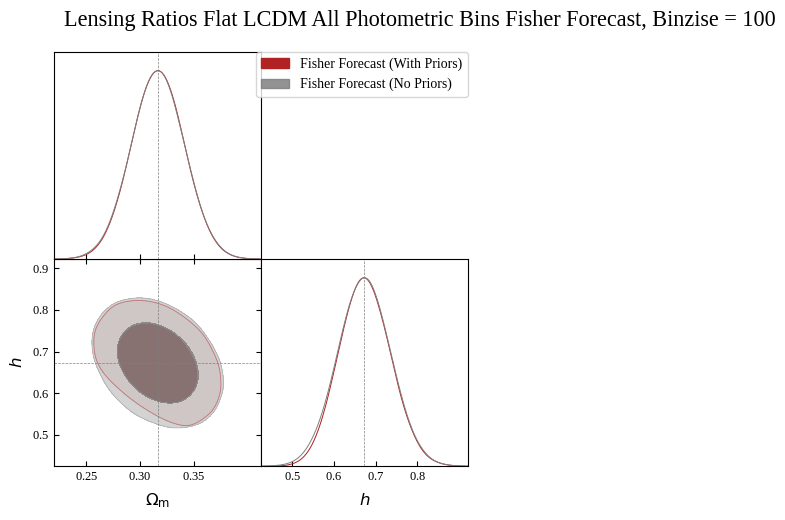

total_time:  0:00:48.881003


In [60]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=100,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=None,
    cmb_noise_EE=None,
    cmb_noise_TE=None,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['CG', 'GL'],
    cmb_primaries=False,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h']
params_to_plot = ['Omega_m', 'h']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_LCDM_LR_All_Photometric_Bins_Binsize=100.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_LCDM_LR_All_Photometric_Bins_Binsize=100.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Lensing Ratios Flat LCDM All Photometric Bins Fisher Forecast, Binzise = 100",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Plot successfully saved to: plots/Fisher Forecasts/lensing_ratios_flat_lcdm_all_photometric_bins_fisher_forecast_binzise_=_50.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.317\pm 0.019$ | $\Omega_m = 0.317^{+0.037}_{-0.037}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.317\pm 0.019$ | $\Omega_m = 0.317^{+0.037}_{-0.038}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.673\pm 0.053$ | $h = 0.67^{+0.11}_{-0.10}$ |
|  | Fisher Forecast (No Priors) | $h = 0.673\pm 0.055$ | $h = 0.67^{+0.11}_{-0.11}$ |
| --- | --- | --- | --- |

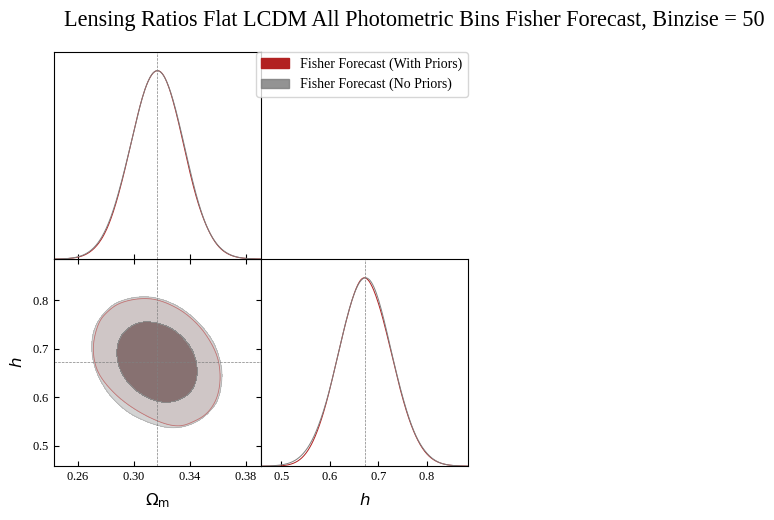

total_time:  0:01:08.935994


In [61]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=50,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=None,
    cmb_noise_EE=None,
    cmb_noise_TE=None,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['CG', 'GL'],
    cmb_primaries=False,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h']
params_to_plot = ['Omega_m', 'h']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_LCDM_LR_All_Photometric_Bins_Binsize=50.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_LCDM_LR_All_Photometric_Bins_Binsize=50.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Lensing Ratios Flat LCDM All Photometric Bins Fisher Forecast, Binzise = 50",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Plot successfully saved to: plots/Fisher Forecasts/lensing_ratios_flat_lcdm_all_photometric_bins_fisher_forecast_binzise_=_25.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.317\pm 0.014$ | $\Omega_m = 0.317^{+0.028}_{-0.028}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.317\pm 0.014$ | $\Omega_m = 0.317^{+0.028}_{-0.028}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.673\pm 0.047$ | $h = 0.673^{+0.093}_{-0.092}$ |
|  | Fisher Forecast (No Priors) | $h = 0.673\pm 0.048$ | $h = 0.673^{+0.094}_{-0.094}$ |
| --- | --- | --- | --- |

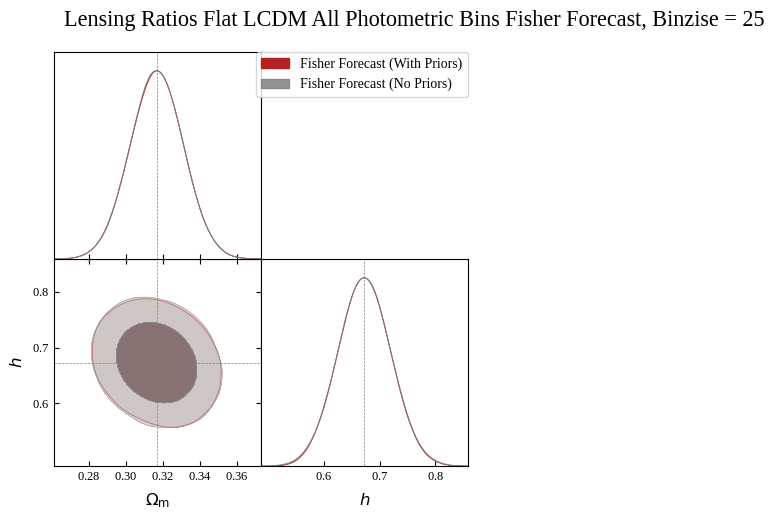

total_time:  0:01:29.622368


In [62]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=25,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=None,
    cmb_noise_EE=None,
    cmb_noise_TE=None,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['CG', 'GL'],
    cmb_primaries=False,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h']
params_to_plot = ['Omega_m', 'h']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_LCDM_LR_All_Photometric_Bins_Binsize=25.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_LCDM_LR_All_Photometric_Bins_Binsize=25.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Lensing Ratios Flat LCDM All Photometric Bins Fisher Forecast, Binzise = 25",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

#### Primaries

Plot successfully saved to: plots/Fisher Forecasts/primaries_flat_lcdm_all_photometric_bins_fisher_forecast_binzise_=_100.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.3176^{+0.0061}_{-0.0080}$ | $\Omega_m = 0.318^{+0.014}_{-0.013}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3166\pm 0.0078$ | $\Omega_m = 0.317^{+0.015}_{-0.015}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6720^{+0.0062}_{-0.0047}$ | $h = 0.6720^{+0.0098}_{-0.010}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6727\pm 0.0060$ | $h = 0.673^{+0.012}_{-0.012}$ |
| --- | --- | --- | --- |

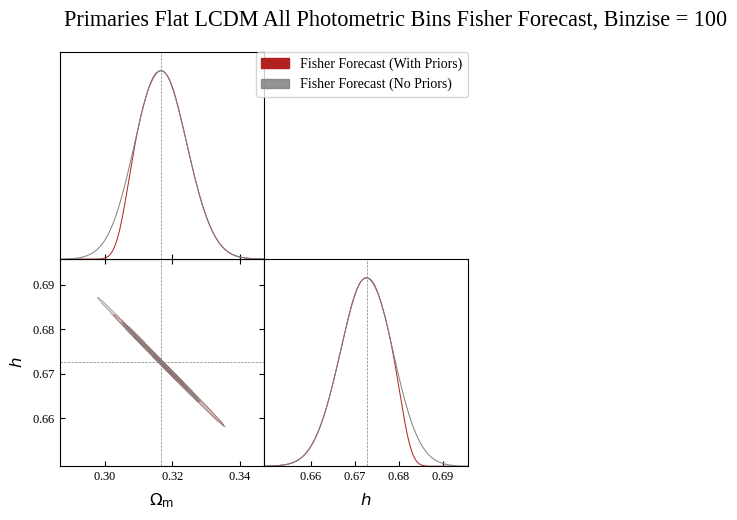

total_time:  0:01:06.165027


In [63]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=100,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_cmb_noise_TT,
    cmb_noise_EE=SO_cmb_noise_EE,
    cmb_noise_TE=SO_cmb_noise_TE,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['TT', 'TE', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h']
params_to_plot = ['Omega_m', 'h']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_LCDM_Primaries_All_Photometric_Bins_Binsize=100.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_LCDM_Primaries_All_Photometric_Bins_Binsize=100.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Primaries Flat LCDM All Photometric Bins Fisher Forecast, Binzise = 100",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Plot successfully saved to: plots/Fisher Forecasts/primaries_flat_lcdm_all_photometric_bins_fisher_forecast_binzise_=_50.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.3174^{+0.0060}_{-0.0077}$ | $\Omega_m = 0.317^{+0.013}_{-0.013}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3166\pm 0.0074$ | $\Omega_m = 0.317^{+0.015}_{-0.014}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6721^{+0.0059}_{-0.0046}$ | $h = 0.6721^{+0.0096}_{-0.010}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6727\pm 0.0057$ | $h = 0.673^{+0.011}_{-0.011}$ |
| --- | --- | --- | --- |

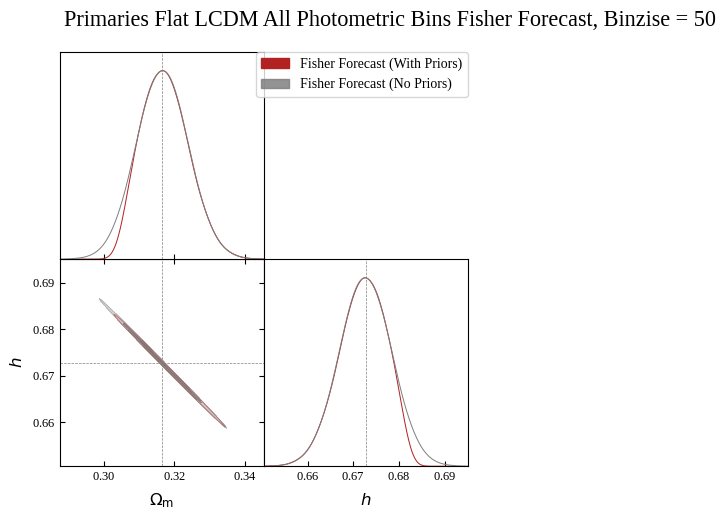

total_time:  0:01:31.027949


In [65]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=50,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_cmb_noise_TT,
    cmb_noise_EE=SO_cmb_noise_EE,
    cmb_noise_TE=SO_cmb_noise_TE,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['TT', 'TE', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h']
params_to_plot = ['Omega_m', 'h']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_LCDM_Primaries_All_Photometric_Bins_Binsize=50.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_LCDM_Primaries_All_Photometric_Bins_Binsize=50.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Primaries Flat LCDM All Photometric Bins Fisher Forecast, Binzise = 50",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Plot successfully saved to: plots/Fisher Forecasts/primaries_flat_lcdm_all_photometric_bins_fisher_forecast_binzise_=_25.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.3174^{+0.0061}_{-0.0075}$ | $\Omega_m = 0.317^{+0.013}_{-0.012}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3166\pm 0.0074$ | $\Omega_m = 0.317^{+0.014}_{-0.014}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6721^{+0.0058}_{-0.0047}$ | $h = 0.6721^{+0.0096}_{-0.0099}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6727\pm 0.0057$ | $h = 0.673^{+0.011}_{-0.011}$ |
| --- | --- | --- | --- |

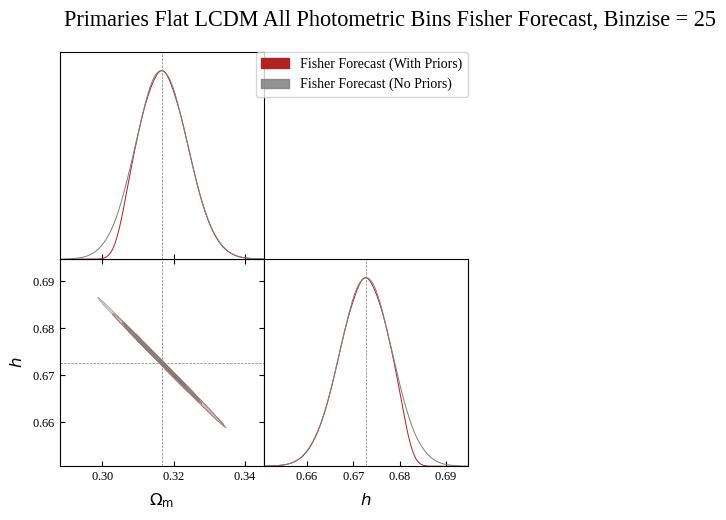

total_time:  0:02:13.922707


In [66]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=25,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_cmb_noise_TT,
    cmb_noise_EE=SO_cmb_noise_EE,
    cmb_noise_TE=SO_cmb_noise_TE,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['TT', 'TE', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h']
params_to_plot = ['Omega_m', 'h']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_LCDM_Primaries_All_Photometric_Bins_Binsize=25.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_LCDM_Primaries_All_Photometric_Bins_Binsize=25.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Primaries Flat LCDM All Photometric Bins Fisher Forecast, Binzise = 25",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

#### Lensing Ratios and Primaries

Plot successfully saved to: plots/Fisher Forecasts/lensing_ratios_+_primaries_flat_lcdm_all_photometric_bins_fisher_forecast_binzise_=_100.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.3167\pm 0.0048$ | $\Omega_m = 0.3167^{+0.0096}_{-0.0092}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3166\pm 0.0049$ | $\Omega_m = 0.3166^{+0.0096}_{-0.0096}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6726\pm 0.0037$ | $h = 0.6726^{+0.0071}_{-0.0073}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6727\pm 0.0038$ | $h = 0.6727^{+0.0074}_{-0.0073}$ |
| --- | --- | --- | --- |

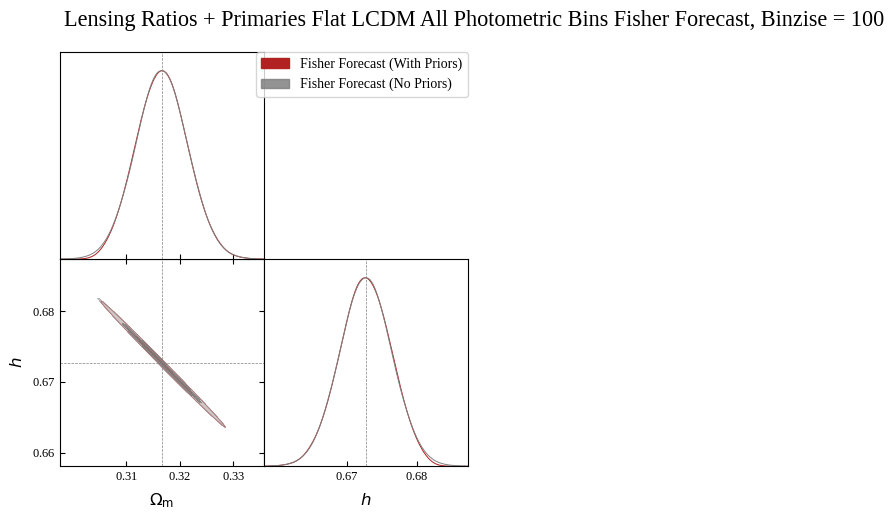

total_time:  0:01:13.318154


In [67]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=100,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_cmb_noise_TT,
    cmb_noise_EE=SO_cmb_noise_EE,
    cmb_noise_TE=SO_cmb_noise_TE,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['CG', 'GL', 'TT', 'TE', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h']
params_to_plot = ['Omega_m', 'h']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_LCDM_LRP_All_Photometric_Bins_Binsize=100.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_LCDM_LRP_All_Photometric_Bins_Binsize=100.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Lensing Ratios + Primaries Flat LCDM All Photometric Bins Fisher Forecast, Binzise = 100",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Plot successfully saved to: plots/Fisher Forecasts/lensing_ratios_+_primaries_flat_lcdm_all_photometric_bins_fisher_forecast_binzise_=_50.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.3166\pm 0.0044$ | $\Omega_m = 0.3166^{+0.0087}_{-0.0086}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3166\pm 0.0044$ | $\Omega_m = 0.3166^{+0.0088}_{-0.0087}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6727\pm 0.0034$ | $h = 0.6727^{+0.0066}_{-0.0067}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6727\pm 0.0034$ | $h = 0.6727^{+0.0067}_{-0.0067}$ |
| --- | --- | --- | --- |

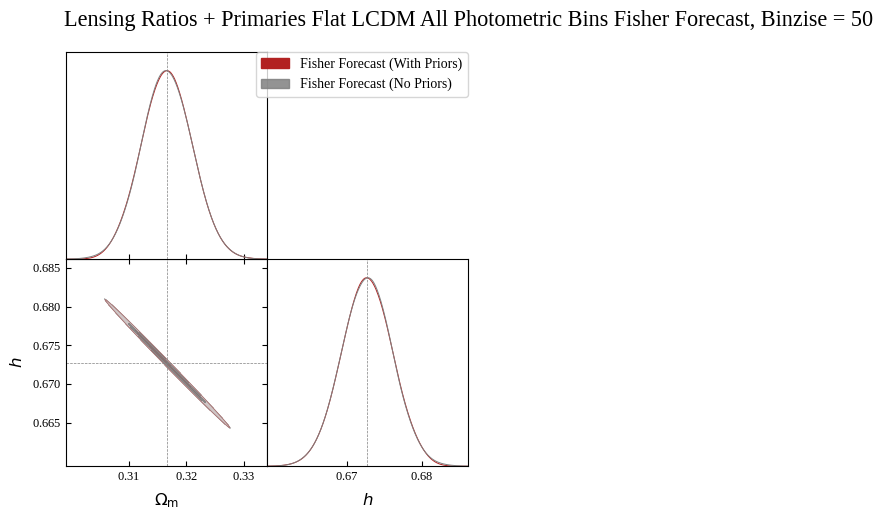

total_time:  0:01:38.827987


In [68]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=50,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_cmb_noise_TT,
    cmb_noise_EE=SO_cmb_noise_EE,
    cmb_noise_TE=SO_cmb_noise_TE,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['CG', 'GL', 'TT', 'TE', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h']
params_to_plot = ['Omega_m', 'h']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_LCDM_LRP_All_Photometric_Bins_Binsize=50.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_LCDM_LRP_All_Photometric_Bins_Binsize=50.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Lensing Ratios + Primaries Flat LCDM All Photometric Bins Fisher Forecast, Binzise = 50",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Plot successfully saved to: plots/Fisher Forecasts/lensing_ratios_+_primaries_flat_lcdm_all_photometric_bins_fisher_forecast_binzise_=_25.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.3166\pm 0.0039$ | $\Omega_m = 0.3166^{+0.0077}_{-0.0076}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3166\pm 0.0039$ | $\Omega_m = 0.3166^{+0.0078}_{-0.0077}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6727\pm 0.0030$ | $h = 0.6727^{+0.0059}_{-0.0059}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6727\pm 0.0030$ | $h = 0.6727^{+0.0059}_{-0.0059}$ |
| --- | --- | --- | --- |

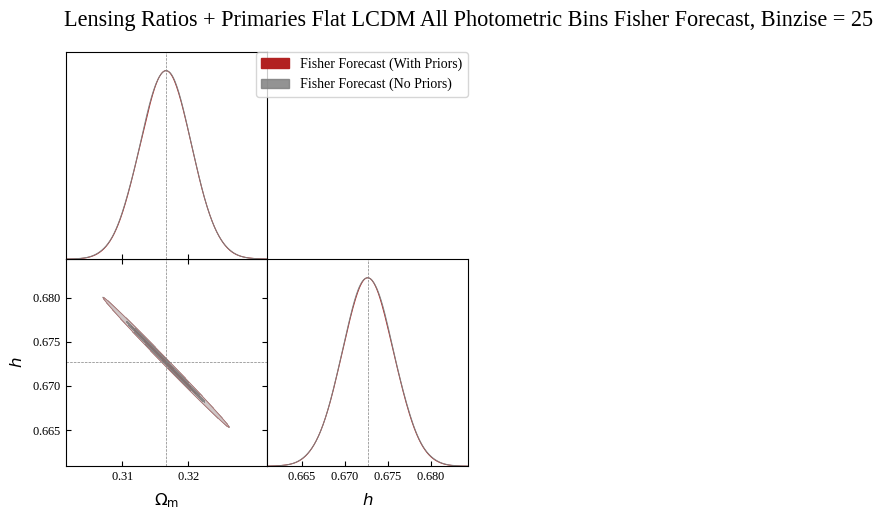

total_time:  0:02:31.540756


In [69]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=25,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_cmb_noise_TT,
    cmb_noise_EE=SO_cmb_noise_EE,
    cmb_noise_TE=SO_cmb_noise_TE,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['CG', 'GL', 'TT', 'TE', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h']
params_to_plot = ['Omega_m', 'h']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_LCDM_LRP_All_Photometric_Bins_Binsize=25.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h\n'
)
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_LCDM_LRP_All_Photometric_Bins_Binsize=25.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Lensing Ratios + Primaries Flat LCDM All Photometric Bins Fisher Forecast, Binzise = 25",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

### Curved $\Lambda$CDM: $\Omega_m, h, \Omega_k$

#### Lensing Ratios

Plot successfully saved to: plots/Fisher Forecasts/lensing_ratios_curved_lcdm_all_photometric_bins_fisher_forecast_binzise_=_100.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.320\pm 0.026$ | $\Omega_m = 0.320^{+0.053}_{-0.051}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.317\pm 0.028$ | $\Omega_m = 0.317^{+0.054}_{-0.054}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.693\pm 0.060$ | $h = 0.69^{+0.12}_{-0.11}$ |
|  | Fisher Forecast (No Priors) | $h = 0.685\pm 0.063$ | $h = 0.69^{+0.12}_{-0.12}$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Fisher Forecast (With Priors) | $\Omega_k = 0.003\pm 0.023$ | $\Omega_k = 0.003^{+0.045}_{-0.044}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.002\pm 0.023$ | $\Omega_k = 0.002^{+0.045}_{-0.045}$ |
| --- | --- | --- | --- |

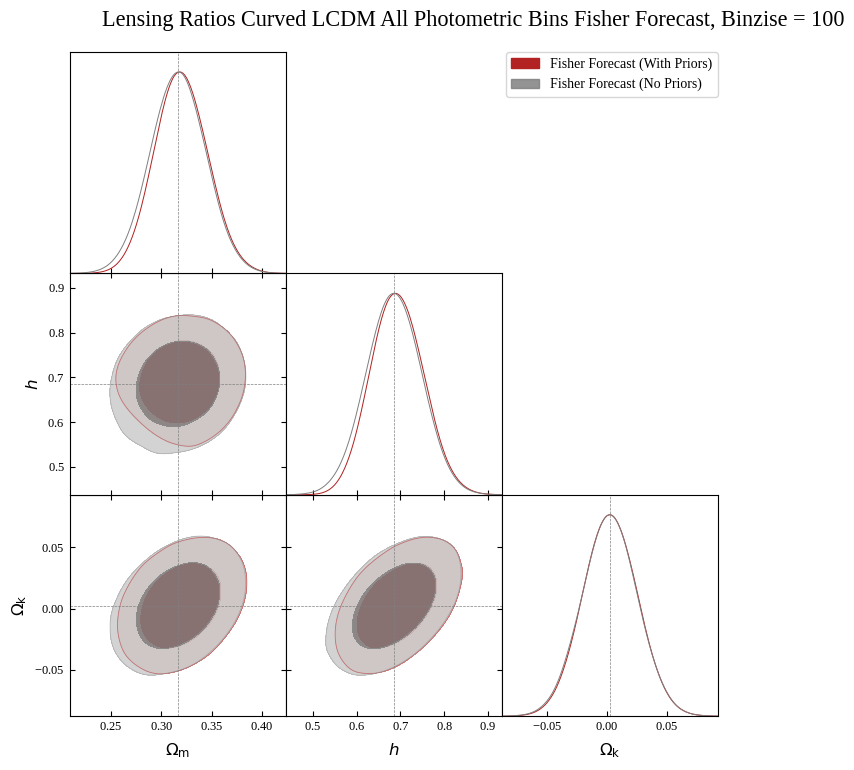

total_time:  0:01:04.015606


In [51]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=curved_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=100,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=None,
    cmb_noise_EE=None,
    cmb_noise_TE=None,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['CG', 'GL'],
    cmb_primaries=False,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h', 'Omega_k']
params_to_plot = ['Omega_m', 'h', 'Omega_k']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Curved_LCDM_LR_All_Photometric_Bins_Binsize=100.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h Omega_k',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, Omega_k\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Curved_LCDM_LR_All_Photometric_Bins_Binsize=100.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h Omega_k',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, Omega_k\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Lensing Ratios Curved LCDM All Photometric Bins Fisher Forecast, Binzise = 100",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Plot successfully saved to: plots/Fisher Forecasts/lensing_ratios_curved_lcdm_all_photometric_bins_fisher_forecast_binzise_=_50.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.317\pm 0.021$ | $\Omega_m = 0.317^{+0.042}_{-0.042}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.317\pm 0.021$ | $\Omega_m = 0.317^{+0.042}_{-0.042}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.687\pm 0.048$ | $h = 0.687^{+0.095}_{-0.093}$ |
|  | Fisher Forecast (No Priors) | $h = 0.685\pm 0.049$ | $h = 0.685^{+0.095}_{-0.096}$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Fisher Forecast (With Priors) | $\Omega_k = 0.002\pm 0.021$ | $\Omega_k = 0.002^{+0.042}_{-0.042}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.002\pm 0.021$ | $\Omega_k = 0.002^{+0.042}_{-0.042}$ |
| --- | --- | --- | --- |

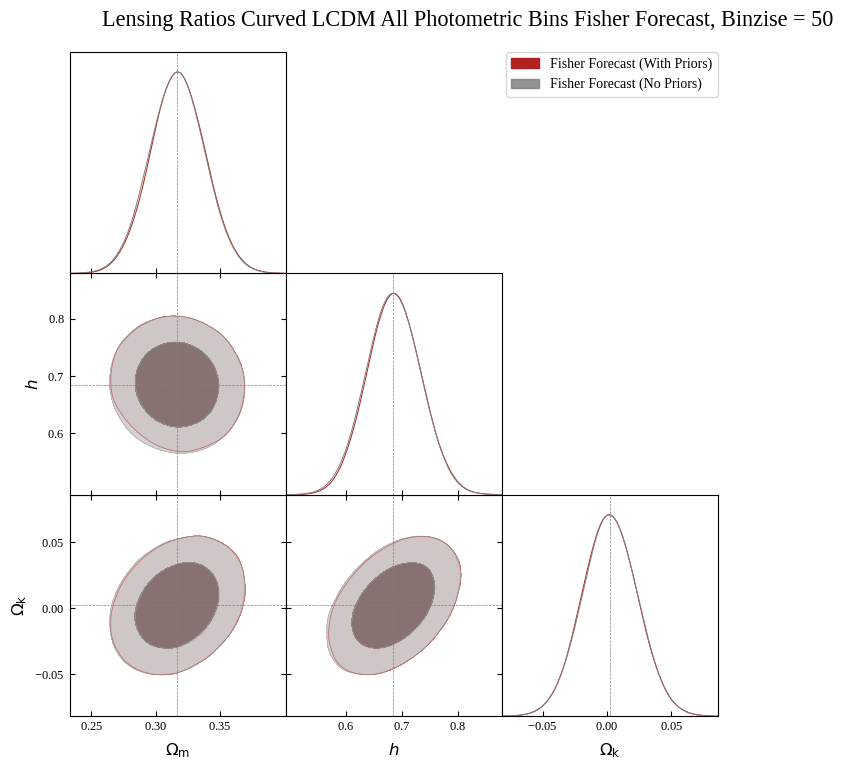

total_time:  0:01:20.476953


In [52]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=curved_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=50,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=None,
    cmb_noise_EE=None,
    cmb_noise_TE=None,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['CG', 'GL'],
    cmb_primaries=False,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h', 'Omega_k']
params_to_plot = ['Omega_m', 'h', 'Omega_k']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Curved_LCDM_LR_All_Photometric_Bins_Binsize=50.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h Omega_k',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, Omega_k\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Curved_LCDM_LR_All_Photometric_Bins_Binsize=50.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h Omega_k',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, Omega_k\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Lensing Ratios Curved LCDM All Photometric Bins Fisher Forecast, Binzise = 50",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Plot successfully saved to: plots/Fisher Forecasts/lensing_ratios_curved_lcdm_all_photometric_bins_fisher_forecast_binzise_=_25.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.317\pm 0.017$ | $\Omega_m = 0.317^{+0.033}_{-0.033}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.317\pm 0.017$ | $\Omega_m = 0.317^{+0.033}_{-0.033}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.685\pm 0.040$ | $h = 0.685^{+0.078}_{-0.078}$ |
|  | Fisher Forecast (No Priors) | $h = 0.685\pm 0.040$ | $h = 0.685^{+0.078}_{-0.078}$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Fisher Forecast (With Priors) | $\Omega_k = 0.002\pm 0.020$ | $\Omega_k = 0.002^{+0.040}_{-0.040}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.002\pm 0.020$ | $\Omega_k = 0.002^{+0.040}_{-0.040}$ |
| --- | --- | --- | --- |

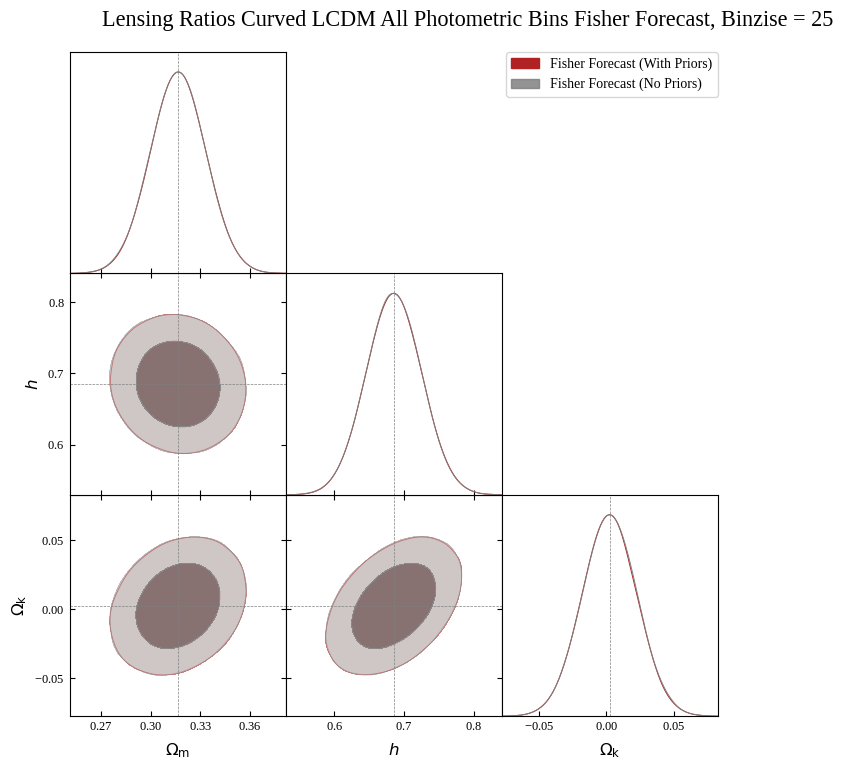

total_time:  0:01:59.210498


In [53]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=curved_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=25,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=None,
    cmb_noise_EE=None,
    cmb_noise_TE=None,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['CG', 'GL'],
    cmb_primaries=False,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h', 'Omega_k']
params_to_plot = ['Omega_m', 'h', 'Omega_k']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Curved_LCDM_LR_All_Photometric_Bins_Binsize=25.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h Omega_k',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, Omega_k\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Curved_LCDM_LR_All_Photometric_Bins_Binsize=25.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h Omega_k',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, Omega_k\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Lensing Ratios Curved LCDM All Photometric Bins Fisher Forecast, Binzise = 25",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

#### Primaries

Plot successfully saved to: plots/Fisher Forecasts/primaries_curved_lcdm_all_photometric_bins_fisher_forecast_binzise_=_100.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.332^{+0.015}_{-0.031}$ | $\Omega_m = 0.332^{+0.048}_{-0.040}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.317\pm 0.033$ | $\Omega_m = 0.317^{+0.066}_{-0.065}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.670^{+0.030}_{-0.016}$ | $h = 0.670^{+0.040}_{-0.048}$ |
|  | Fisher Forecast (No Priors) | $h = 0.685\pm 0.033$ | $h = 0.685^{+0.065}_{-0.065}$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Fisher Forecast (With Priors) | $\Omega_k = 0.0002^{+0.0042}_{-0.0027}$ | $\Omega_k = 0.0002^{+0.0064}_{-0.0072}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.0023\pm 0.0047$ | $\Omega_k = 0.0023^{+0.0092}_{-0.0092}$ |
| --- | --- | --- | --- |

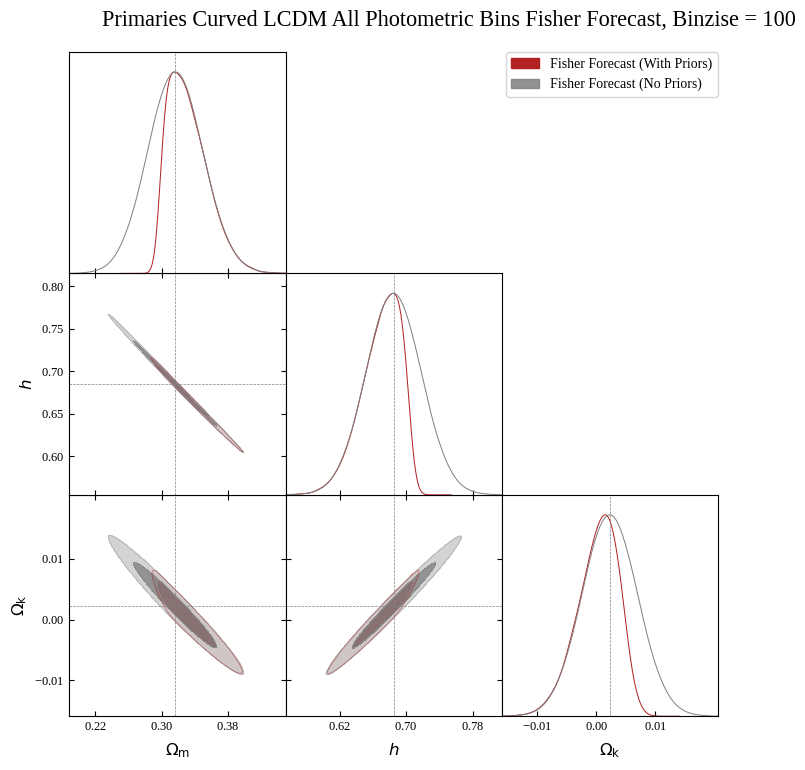

total_time:  0:01:41.448880


In [54]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=curved_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=100,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_cmb_noise_TT,
    cmb_noise_EE=SO_cmb_noise_EE,
    cmb_noise_TE=SO_cmb_noise_TE,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['TT', 'TE', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h', 'Omega_k']
params_to_plot = ['Omega_m', 'h', 'Omega_k']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Curved_LCDM_Primaries_All_Photometric_Bins_Binsize=100.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h Omega_k',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, Omega_k\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Curved_LCDM_Primaries_All_Photometric_Bins_Binsize=100.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h Omega_k',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, Omega_k\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Primaries Curved LCDM All Photometric Bins Fisher Forecast, Binzise = 100",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Plot successfully saved to: plots/Fisher Forecasts/primaries_curved_lcdm_all_photometric_bins_fisher_forecast_binzise_=_50.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.332^{+0.014}_{-0.030}$ | $\Omega_m = 0.332^{+0.047}_{-0.038}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.317\pm 0.032$ | $\Omega_m = 0.317^{+0.064}_{-0.062}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.670^{+0.029}_{-0.015}$ | $h = 0.670^{+0.039}_{-0.046}$ |
|  | Fisher Forecast (No Priors) | $h = 0.685\pm 0.032$ | $h = 0.685^{+0.063}_{-0.063}$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Fisher Forecast (With Priors) | $\Omega_k = 0.0004^{+0.0040}_{-0.0026}$ | $\Omega_k = 0.0004^{+0.0061}_{-0.0068}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.0023\pm 0.0045$ | $\Omega_k = 0.0023^{+0.0088}_{-0.0088}$ |
| --- | --- | --- | --- |

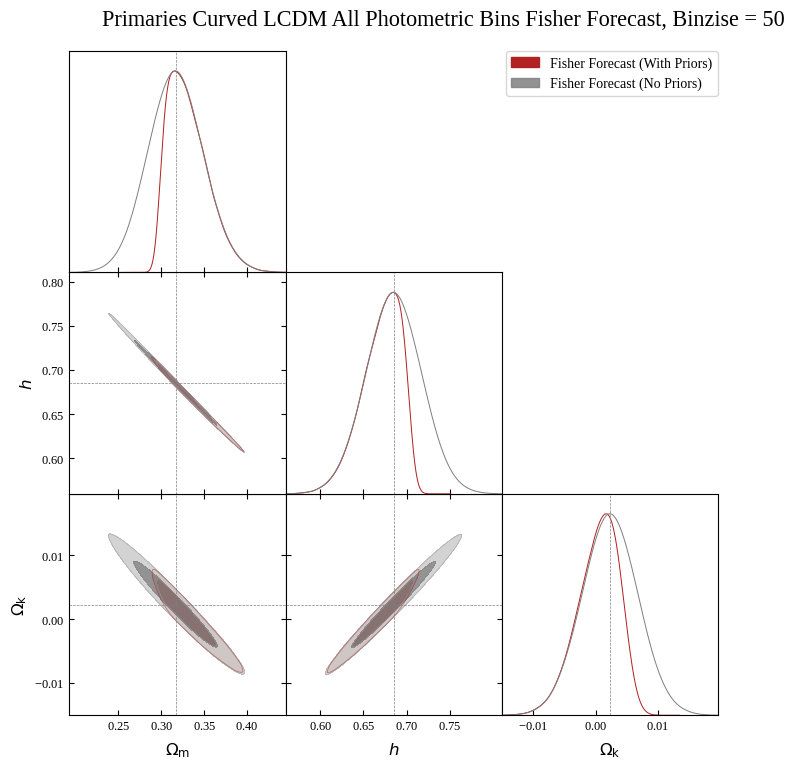

total_time:  0:02:03.029814


In [55]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=curved_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=50,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_cmb_noise_TT,
    cmb_noise_EE=SO_cmb_noise_EE,
    cmb_noise_TE=SO_cmb_noise_TE,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['TT', 'TE', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h', 'Omega_k']
params_to_plot = ['Omega_m', 'h', 'Omega_k']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Curved_LCDM_Primaries_All_Photometric_Bins_Binsize=50.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h Omega_k',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, Omega_k\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Curved_LCDM_Primaries_All_Photometric_Bins_Binsize=50.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h w0',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, w0\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Primaries Curved LCDM All Photometric Bins Fisher Forecast, Binzise = 50",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Plot successfully saved to: plots/Fisher Forecasts/primaries_curved_lcdm_all_photometric_bins_fisher_forecast_binzise_=_25.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.331^{+0.014}_{-0.030}$ | $\Omega_m = 0.331^{+0.046}_{-0.038}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.317\pm 0.032$ | $\Omega_m = 0.317^{+0.063}_{-0.062}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.671^{+0.029}_{-0.015}$ | $h = 0.671^{+0.039}_{-0.046}$ |
|  | Fisher Forecast (No Priors) | $h = 0.685\pm 0.032$ | $h = 0.685^{+0.062}_{-0.062}$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Fisher Forecast (With Priors) | $\Omega_k = 0.0004^{+0.0040}_{-0.0026}$ | $\Omega_k = 0.0004^{+0.0060}_{-0.0068}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.0023\pm 0.0044$ | $\Omega_k = 0.0023^{+0.0087}_{-0.0087}$ |
| --- | --- | --- | --- |

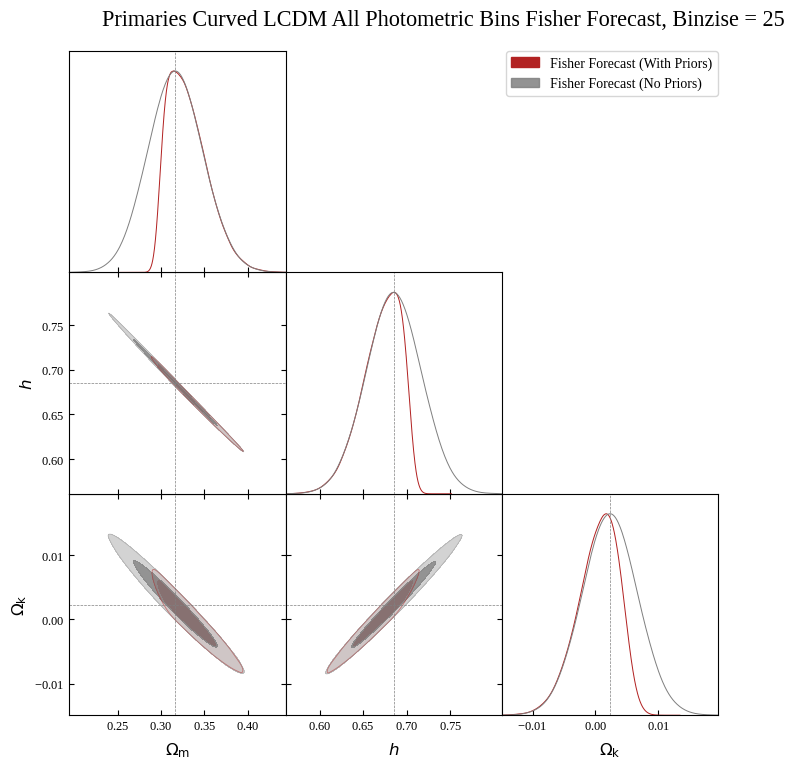

total_time:  0:02:49.118598


In [56]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=curved_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=25,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_cmb_noise_TT,
    cmb_noise_EE=SO_cmb_noise_EE,
    cmb_noise_TE=SO_cmb_noise_TE,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['TT', 'TE', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h', 'Omega_k']
params_to_plot = ['Omega_m', 'h', 'Omega_k']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Curved_LCDM_Primaries_All_Photometric_Bins_Binsize=25.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h Omega_k',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, Omega_k\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Curved_LCDM_Primaries_All_Photometric_Bins_Binsize=25.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h Omega_k',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, Omega_k\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Primaries Curved LCDM All Photometric Bins Fisher Forecast, Binzise = 25",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

#### Lensing Ratios and Primaries

Plot successfully saved to: plots/Fisher Forecasts/lensing_ratios_+_primaries_curved_lcdm_all_photometric_bins_fisher_forecast_binzise_=_100.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.319^{+0.010}_{-0.015}$ | $\Omega_m = 0.319^{+0.025}_{-0.023}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.317\pm 0.014$ | $\Omega_m = 0.317^{+0.028}_{-0.028}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.682^{+0.015}_{-0.011}$ | $h = 0.682^{+0.024}_{-0.025}$ |
|  | Fisher Forecast (No Priors) | $h = 0.685\pm 0.015$ | $h = 0.685^{+0.029}_{-0.029}$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Fisher Forecast (With Priors) | $\Omega_k = 0.0020^{+0.0023}_{-0.0021}$ | $\Omega_k = 0.0020^{+0.0041}_{-0.0044}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.0023\pm 0.0024$ | $\Omega_k = 0.0023^{+0.0046}_{-0.0046}$ |
| --- | --- | --- | --- |

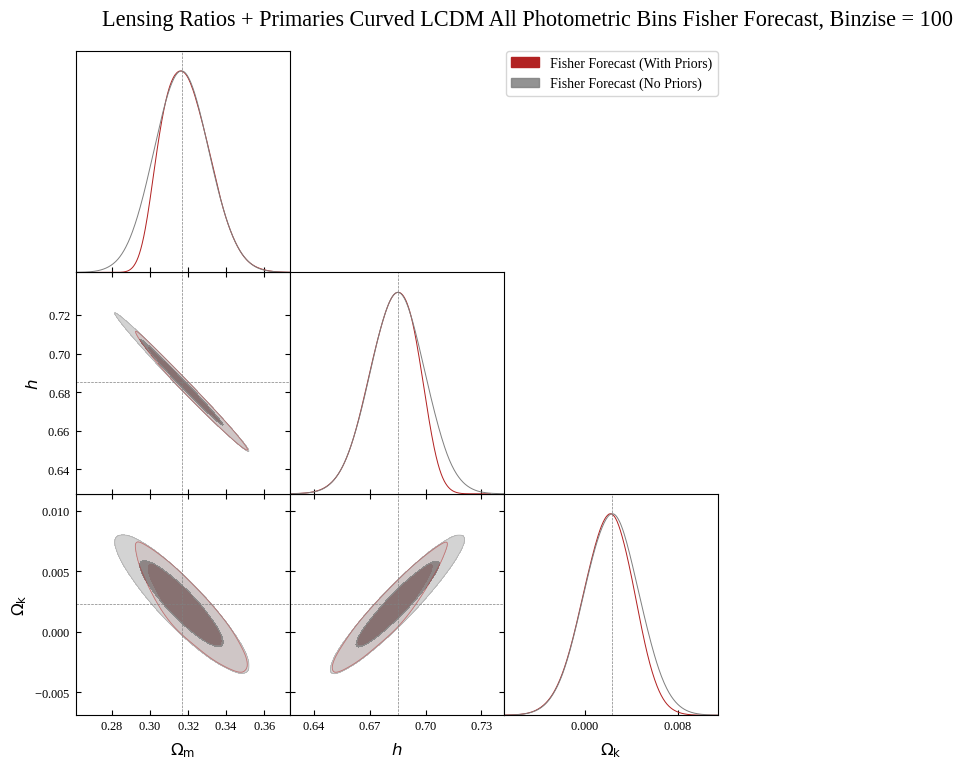

total_time:  0:01:42.610246


In [57]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=curved_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=100,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_cmb_noise_TT,
    cmb_noise_EE=SO_cmb_noise_EE,
    cmb_noise_TE=SO_cmb_noise_TE,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['CG', 'GL', 'TT', 'TE', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h', 'Omega_k']
params_to_plot = ['Omega_m', 'h', 'Omega_k']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Curved_LCDM_LRP_All_Photometric_Bins_Binsize=100.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h Omega_k',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, Omega_k\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Curved_LCDM_LRP_All_Photometric_Bins_Binsize=100.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h Omega_k',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, Omega_k\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Lensing Ratios + Primaries Curved LCDM All Photometric Bins Fisher Forecast, Binzise = 100",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Plot successfully saved to: plots/Fisher Forecasts/lensing_ratios_+_primaries_curved_lcdm_all_photometric_bins_fisher_forecast_binzise_=_50.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.3178^{+0.0096}_{-0.012}$ | $\Omega_m = 0.318^{+0.021}_{-0.020}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.317\pm 0.012$ | $\Omega_m = 0.317^{+0.023}_{-0.023}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.684^{+0.012}_{-0.010}$ | $h = 0.684^{+0.021}_{-0.022}$ |
|  | Fisher Forecast (No Priors) | $h = 0.685\pm 0.012$ | $h = 0.685^{+0.023}_{-0.023}$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Fisher Forecast (With Priors) | $\Omega_k = 0.0022\pm 0.0019$ | $\Omega_k = 0.0022^{+0.0037}_{-0.0039}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.0023\pm 0.0020$ | $\Omega_k = 0.0023^{+0.0040}_{-0.0039}$ |
| --- | --- | --- | --- |

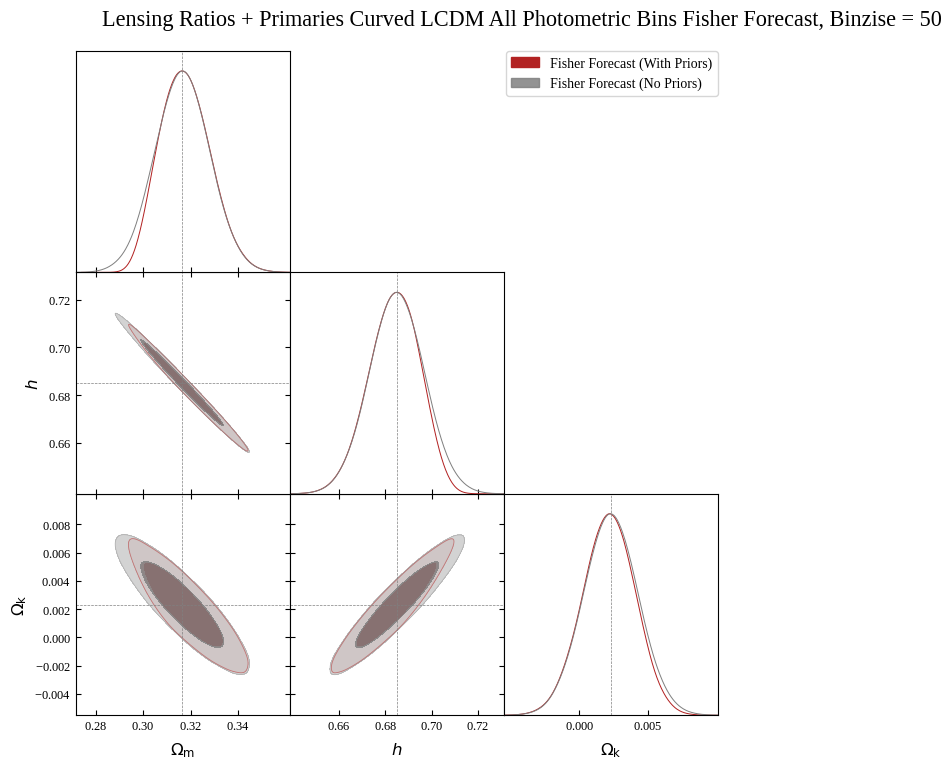

total_time:  0:02:07.494551


In [58]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=curved_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=50,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_cmb_noise_TT,
    cmb_noise_EE=SO_cmb_noise_EE,
    cmb_noise_TE=SO_cmb_noise_TE,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['CG', 'GL', 'TT', 'TE', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h', 'Omega_k']
params_to_plot = ['Omega_m', 'h', 'Omega_k']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Curved_LCDM_LRP_All_Photometric_Bins_Binsize=50.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h Omega_k',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, Omega_k\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Curved_LCDM_LRP_All_Photometric_Bins_Binsize=50.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h Omega_k',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, Omega_k\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Lensing Ratios + Primaries Curved LCDM All Photometric Bins Fisher Forecast, Binzise = 50",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Plot successfully saved to: plots/Fisher Forecasts/lensing_ratios_+_primaries_curved_lcdm_all_photometric_bins_fisher_forecast_binzise_=_25.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.3169\pm 0.0087$ | $\Omega_m = 0.317^{+0.017}_{-0.016}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3166\pm 0.0090$ | $\Omega_m = 0.317^{+0.018}_{-0.018}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6847\pm 0.0092$ | $h = 0.685^{+0.018}_{-0.018}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6850\pm 0.0095$ | $h = 0.685^{+0.019}_{-0.019}$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Fisher Forecast (With Priors) | $\Omega_k = 0.0023\pm 0.0017$ | $\Omega_k = 0.0023^{+0.0034}_{-0.0034}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.0023\pm 0.0018$ | $\Omega_k = 0.0023^{+0.0034}_{-0.0034}$ |
| --- | --- | --- | --- |

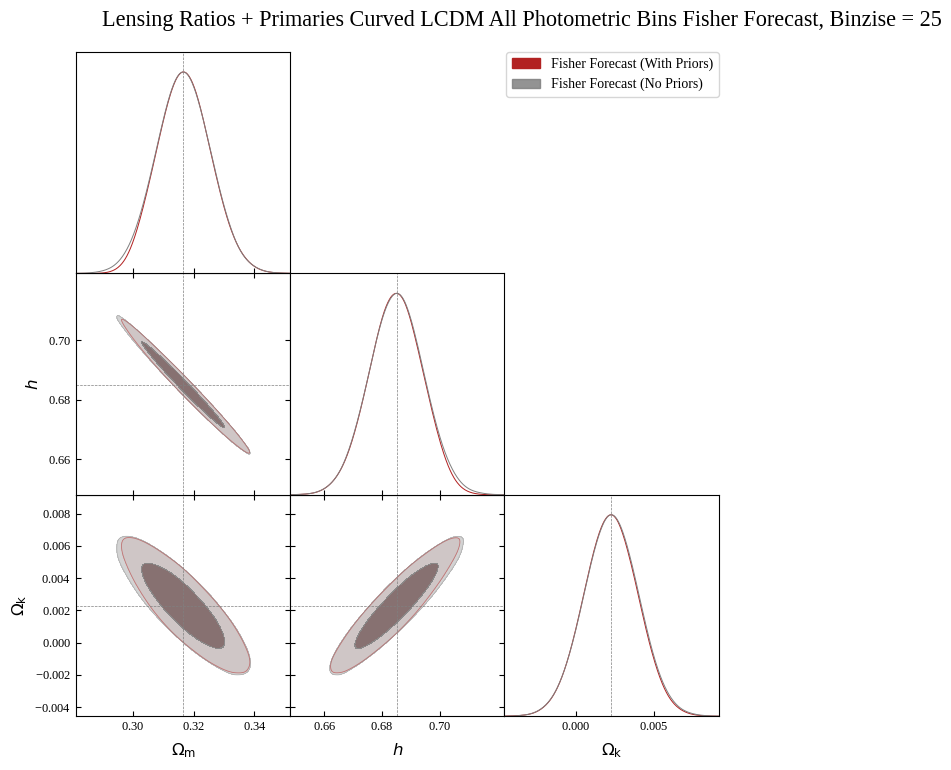

total_time:  0:03:18.223631


In [59]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=curved_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=25,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_cmb_noise_TT,
    cmb_noise_EE=SO_cmb_noise_EE,
    cmb_noise_TE=SO_cmb_noise_TE,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['CG', 'GL', 'TT', 'TE', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h', 'Omega_k']
params_to_plot = ['Omega_m', 'h', 'Omega_k']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Curved_LCDM_LRP_All_Photometric_Bins_Binsize=25.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h Omega_k',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, Omega_k\n'
)
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Curved_LCDM_LRP_All_Photometric_Bins_Binsize=25.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h Omega_k',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, Omega_k\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Lensing Ratios + Primaries Curved LCDM All Photometric Bins Fisher Forecast, Binzise = 25",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

### Flat wCDM: $\Omega_m, h, w_0$

#### Lensing Ratios

Plot successfully saved to: plots/Fisher Forecasts/lensing_ratios_flat_wcdm_all_photometric_bins_fisher_forecast_binzise_=_100.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.318\pm 0.029$ | $\Omega_m = 0.318^{+0.058}_{-0.056}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.316\pm 0.030$ | $\Omega_m = 0.316^{+0.058}_{-0.059}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.697\pm 0.052$ | $h = 0.70^{+0.10}_{-0.10}$ |
|  | Fisher Forecast (No Priors) | $h = 0.695\pm 0.053$ | $h = 0.70^{+0.10}_{-0.10}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -1.05\pm 0.14$ | $w_0 = -1.05^{+0.28}_{-0.28}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -1.06\pm 0.14$ | $w_0 = -1.06^{+0.28}_{-0.28}$ |
| --- | --- | --- | --- |

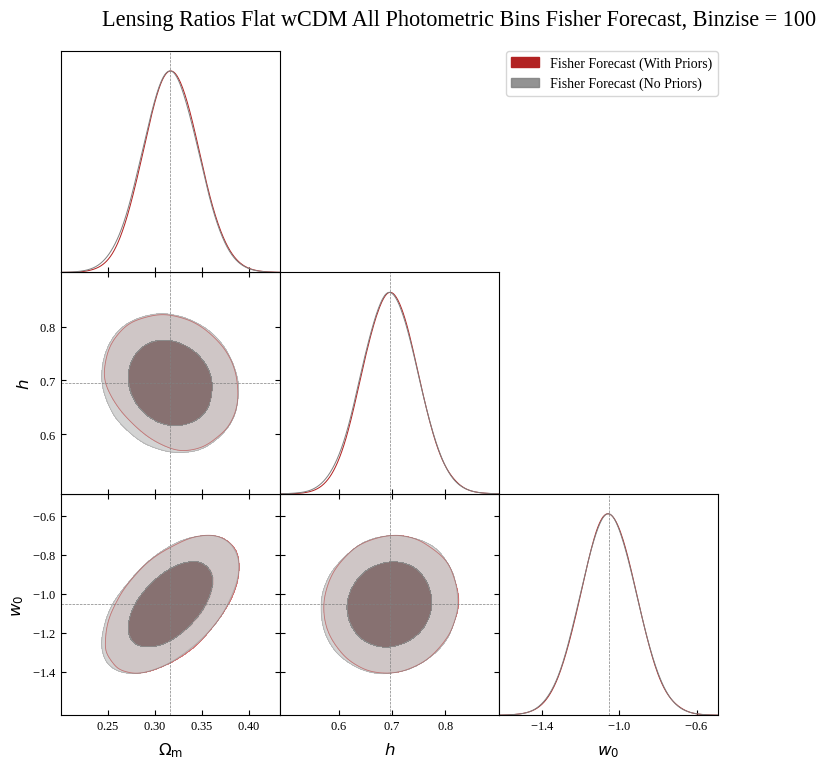

total_time:  0:01:04.424712


In [42]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_wCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=100,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=None,
    cmb_noise_EE=None,
    cmb_noise_TE=None,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['CG', 'GL'],
    cmb_primaries=False,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h', 'w0']
params_to_plot = ['Omega_m', 'h', 'w0']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_wCDM_LR_All_Photometric_Bins_Binsize=100.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h w0',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, w0\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_wCDM_LR_All_Photometric_Bins_Binsize=100.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h w0',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, w0\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Lensing Ratios Flat wCDM All Photometric Bins Fisher Forecast, Binzise = 100",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Plot successfully saved to: plots/Fisher Forecasts/lensing_ratios_flat_wcdm_all_photometric_bins_fisher_forecast_binzise_=_50.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.317\pm 0.021$ | $\Omega_m = 0.317^{+0.042}_{-0.042}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.317\pm 0.022$ | $\Omega_m = 0.317^{+0.042}_{-0.042}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.695\pm 0.041$ | $h = 0.695^{+0.081}_{-0.080}$ |
|  | Fisher Forecast (No Priors) | $h = 0.695\pm 0.041$ | $h = 0.695^{+0.081}_{-0.081}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -1.05\pm 0.13$ | $w_0 = -1.05^{+0.26}_{-0.26}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -1.06\pm 0.13$ | $w_0 = -1.06^{+0.26}_{-0.26}$ |
| --- | --- | --- | --- |

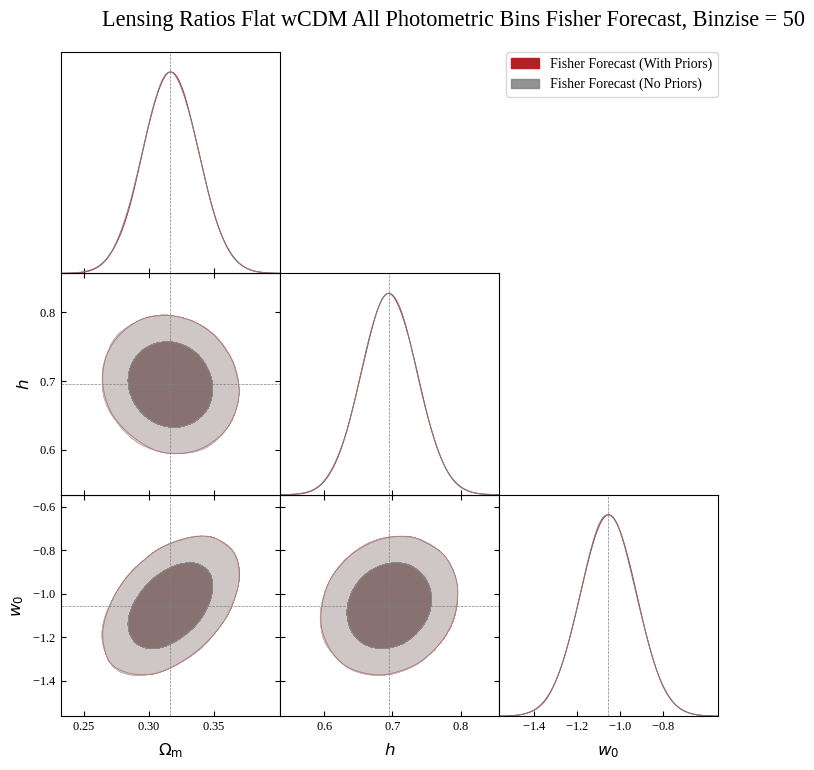

total_time:  0:01:17.661964


In [43]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_wCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=50,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=None,
    cmb_noise_EE=None,
    cmb_noise_TE=None,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['CG', 'GL'],
    cmb_primaries=False,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h', 'w0']
params_to_plot = ['Omega_m', 'h', 'w0']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_wCDM_LR_All_Photometric_Bins_Binsize=50.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h w0',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, w0\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_wCDM_LR_All_Photometric_Bins_Binsize=50.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h w0',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, w0\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Lensing Ratios Flat wCDM All Photometric Bins Fisher Forecast, Binzise = 50",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Plot successfully saved to: plots/Fisher Forecasts/lensing_ratios_flat_wcdm_all_photometric_bins_fisher_forecast_binzise_=_25.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.317\pm 0.014$ | $\Omega_m = 0.317^{+0.027}_{-0.027}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.317\pm 0.014$ | $\Omega_m = 0.317^{+0.027}_{-0.027}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.695\pm 0.029$ | $h = 0.695^{+0.058}_{-0.058}$ |
|  | Fisher Forecast (No Priors) | $h = 0.695\pm 0.029$ | $h = 0.695^{+0.058}_{-0.057}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -1.06\pm 0.12$ | $w_0 = -1.06^{+0.24}_{-0.24}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -1.05\pm 0.12$ | $w_0 = -1.05^{+0.23}_{-0.24}$ |
| --- | --- | --- | --- |

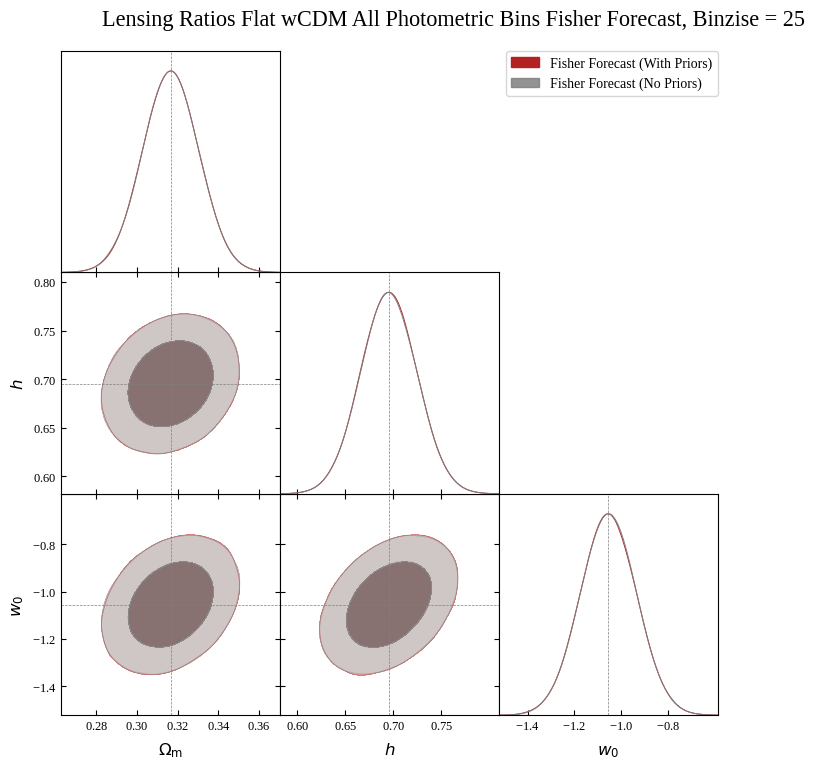

total_time:  0:01:55.551553


In [44]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_wCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=25,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=None,
    cmb_noise_EE=None,
    cmb_noise_TE=None,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['CG', 'GL'],
    cmb_primaries=False,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h', 'w0']
params_to_plot = ['Omega_m', 'h', 'w0']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_wCDM_LR_All_Photometric_Bins_Binsize=25.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h w0',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, w0\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_wCDM_LR_All_Photometric_Bins_Binsize=25.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h w0',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, w0\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Lensing Ratios Flat wCDM All Photometric Bins Fisher Forecast, Binzise = 25",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

#### Primaries

Plot successfully saved to: plots/Fisher Forecasts/primaries_flat_wcdm_all_photometric_bins_fisher_forecast_binzise_=_100.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.3165\pm 0.0012$ | $\Omega_m = 0.3165^{+0.0024}_{-0.0024}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3165\pm 0.0012$ | $\Omega_m = 0.3165^{+0.0024}_{-0.0023}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6951\pm 0.0014$ | $h = 0.6951^{+0.0028}_{-0.0028}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6951\pm 0.0014$ | $h = 0.6951^{+0.0027}_{-0.0027}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -1.0550\pm 0.0090$ | $w_0 = -1.055^{+0.018}_{-0.018}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -1.0550\pm 0.0090$ | $w_0 = -1.055^{+0.018}_{-0.018}$ |
| --- | --- | --- | --- |

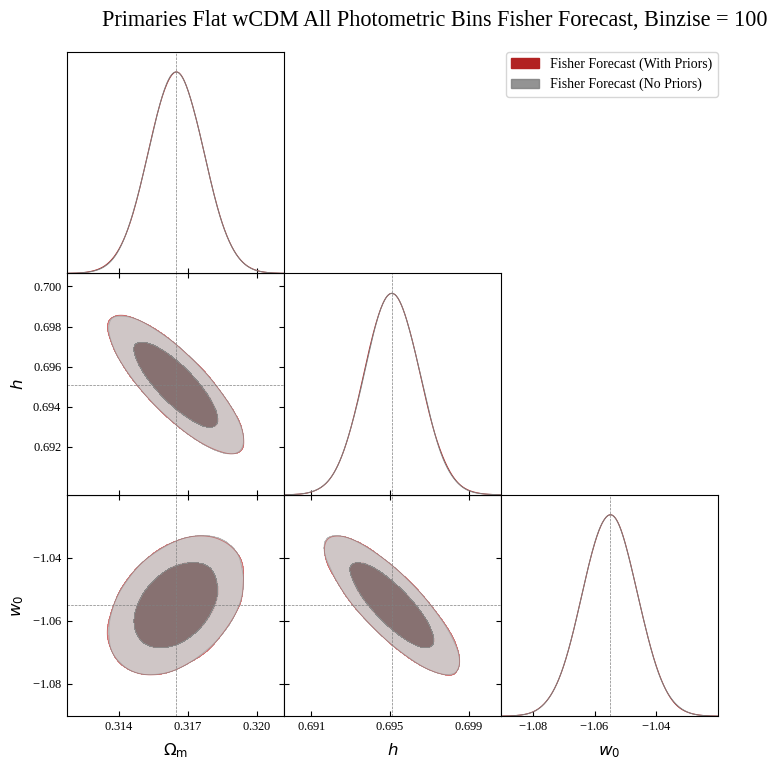

total_time:  0:01:21.169776


In [45]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_wCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=100,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_cmb_noise_TT,
    cmb_noise_EE=SO_cmb_noise_EE,
    cmb_noise_TE=SO_cmb_noise_TE,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['TT', 'TE', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h', 'w0']
params_to_plot = ['Omega_m', 'h', 'w0']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_wCDM_Primaries_All_Photometric_Bins_Binsize=100.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h w0',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, w0\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_wCDM_Primaries_All_Photometric_Bins_Binsize=100.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h w0',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, w0\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Primaries Flat wCDM All Photometric Bins Fisher Forecast, Binzise = 100",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Plot successfully saved to: plots/Fisher Forecasts/primaries_flat_wcdm_all_photometric_bins_fisher_forecast_binzise_=_50.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.3165\pm 0.0010$ | $\Omega_m = 0.3165^{+0.0020}_{-0.0020}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3165\pm 0.0010$ | $\Omega_m = 0.3165^{+0.0020}_{-0.0020}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6951\pm 0.0013$ | $h = 0.6951^{+0.0025}_{-0.0025}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6951\pm 0.0013$ | $h = 0.6951^{+0.0025}_{-0.0025}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -1.0550\pm 0.0086$ | $w_0 = -1.055^{+0.017}_{-0.017}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -1.0550\pm 0.0086$ | $w_0 = -1.055^{+0.017}_{-0.017}$ |
| --- | --- | --- | --- |

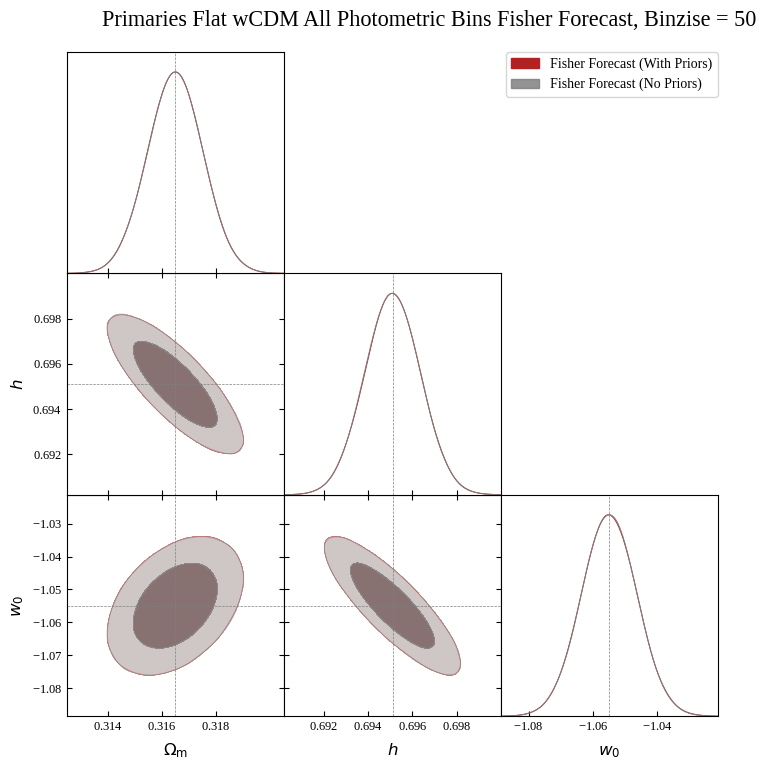

total_time:  0:01:49.838145


In [46]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_wCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=50,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_cmb_noise_TT,
    cmb_noise_EE=SO_cmb_noise_EE,
    cmb_noise_TE=SO_cmb_noise_TE,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['TT', 'TE', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h', 'w0']
params_to_plot = ['Omega_m', 'h', 'w0']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_wCDM_Primaries_All_Photometric_Bins_Binsize=50.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h w0',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, w0\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_wCDM_Primaries_All_Photometric_Bins_Binsize=50.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h w0',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, w0\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Primaries Flat wCDM All Photometric Bins Fisher Forecast, Binzise = 50",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Plot successfully saved to: plots/Fisher Forecasts/primaries_flat_wcdm_all_photometric_bins_fisher_forecast_binzise_=_25.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.31650\pm 0.00098$ | $\Omega_m = 0.3165^{+0.0019}_{-0.0019}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.31650\pm 0.00098$ | $\Omega_m = 0.3165^{+0.0019}_{-0.0019}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6951\pm 0.0012$ | $h = 0.6951^{+0.0024}_{-0.0024}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6951\pm 0.0012$ | $h = 0.6951^{+0.0024}_{-0.0024}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -1.0550\pm 0.0085$ | $w_0 = -1.055^{+0.017}_{-0.017}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -1.0550\pm 0.0085$ | $w_0 = -1.055^{+0.017}_{-0.017}$ |
| --- | --- | --- | --- |

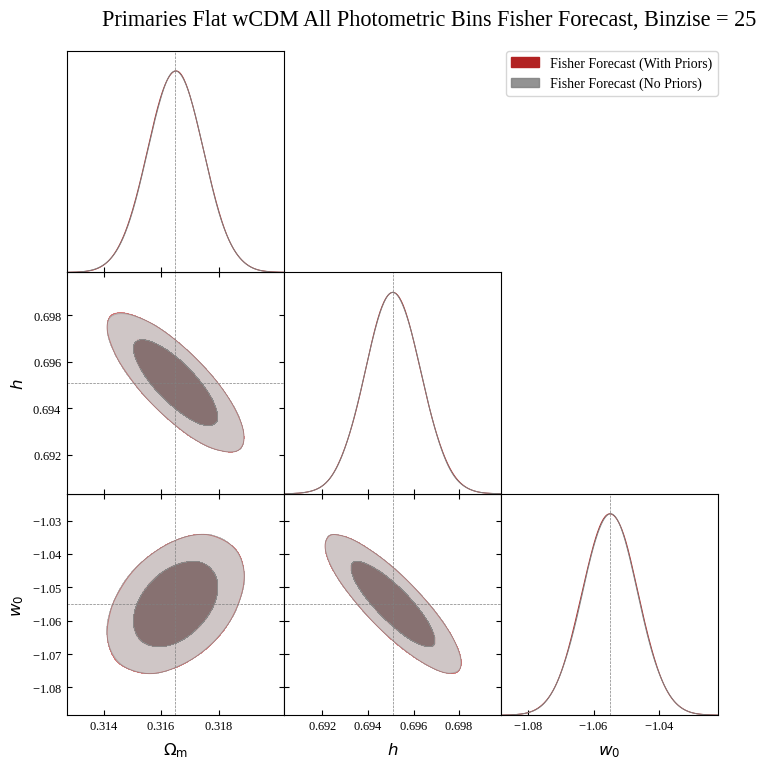

total_time:  0:02:33.950455


In [47]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_wCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=25,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_cmb_noise_TT,
    cmb_noise_EE=SO_cmb_noise_EE,
    cmb_noise_TE=SO_cmb_noise_TE,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['TT', 'TE', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h', 'w0']
params_to_plot = ['Omega_m', 'h', 'w0']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_wCDM_Primaries_All_Photometric_Bins_Binsize=25.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h w0',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, w0\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_wCDM_Primaries_All_Photometric_Bins_Binsize=25.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h w0',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, w0\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Primaries Flat wCDM All Photometric Bins Fisher Forecast, Binzise = 25",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

#### Lensing Ratios and Primaries

Plot successfully saved to: plots/Fisher Forecasts/lensing_ratios_+_primaries_flat_wcdm_all_photometric_bins_fisher_forecast_binzise_=_100.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.3165\pm 0.0012$ | $\Omega_m = 0.3165^{+0.0024}_{-0.0024}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3165\pm 0.0012$ | $\Omega_m = 0.3165^{+0.0024}_{-0.0024}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6951\pm 0.0013$ | $h = 0.6951^{+0.0026}_{-0.0026}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6951\pm 0.0013$ | $h = 0.6951^{+0.0026}_{-0.0026}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -1.0550\pm 0.0073$ | $w_0 = -1.055^{+0.014}_{-0.014}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -1.0550\pm 0.0073$ | $w_0 = -1.055^{+0.014}_{-0.014}$ |
| --- | --- | --- | --- |

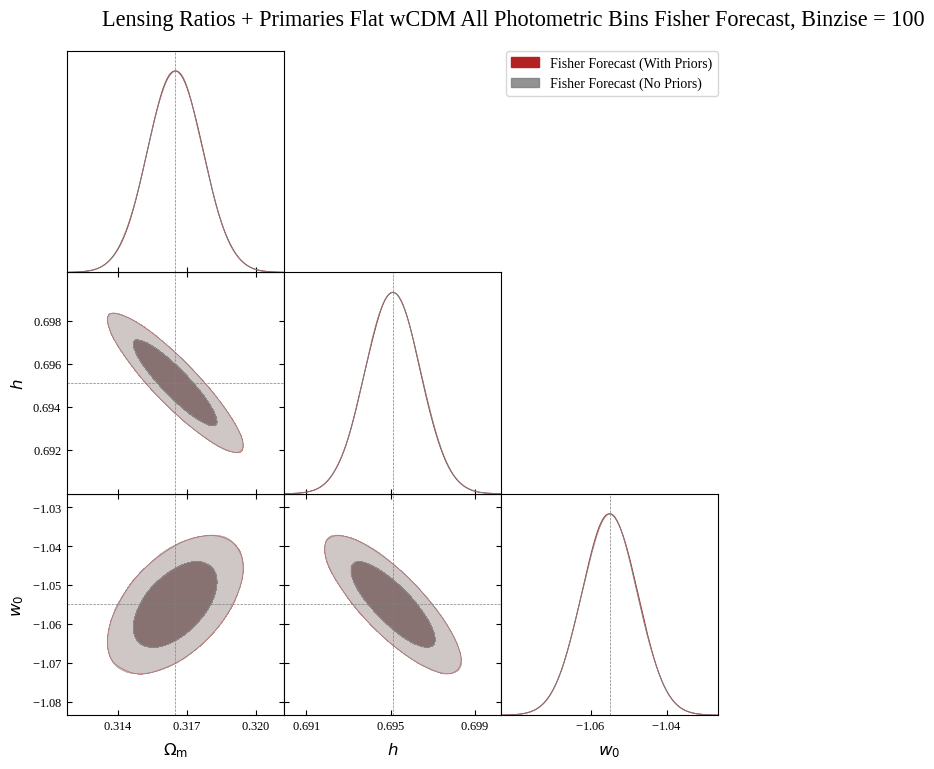

total_time:  0:01:21.986665


In [48]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_wCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=100,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_cmb_noise_TT,
    cmb_noise_EE=SO_cmb_noise_EE,
    cmb_noise_TE=SO_cmb_noise_TE,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['CG', 'GL', 'TT', 'TE', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h', 'w0']
params_to_plot = ['Omega_m', 'h', 'w0']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_wCDM_LRP_All_Photometric_Bins_Binsize=100.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h w0',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, w0\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_wCDM_LRP_All_Photometric_Bins_Binsize=100.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h w0',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, w0\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Lensing Ratios + Primaries Flat wCDM All Photometric Bins Fisher Forecast, Binzise = 100",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Plot successfully saved to: plots/Fisher Forecasts/lensing_ratios_+_primaries_flat_wcdm_all_photometric_bins_fisher_forecast_binzise_=_50.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.3165\pm 0.0010$ | $\Omega_m = 0.3165^{+0.0020}_{-0.0020}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3165\pm 0.0010$ | $\Omega_m = 0.3165^{+0.0020}_{-0.0020}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6951\pm 0.0012$ | $h = 0.6951^{+0.0023}_{-0.0023}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6951\pm 0.0012$ | $h = 0.6951^{+0.0023}_{-0.0023}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -1.0550\pm 0.0070$ | $w_0 = -1.055^{+0.014}_{-0.014}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -1.0550\pm 0.0070$ | $w_0 = -1.055^{+0.014}_{-0.014}$ |
| --- | --- | --- | --- |

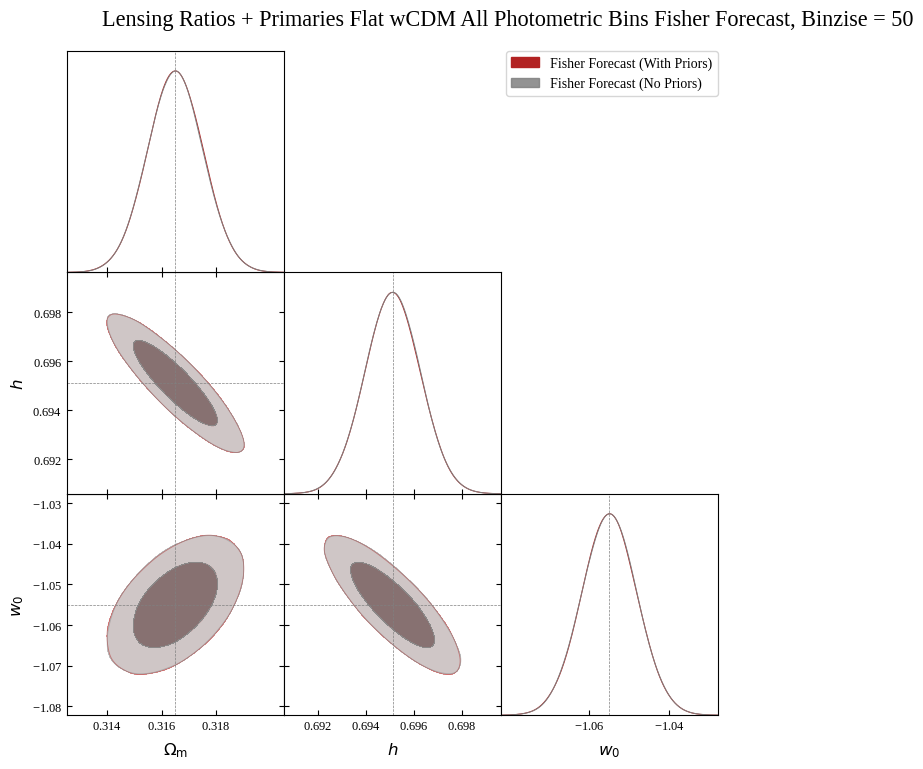

total_time:  0:01:52.805274


In [49]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_wCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=50,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_cmb_noise_TT,
    cmb_noise_EE=SO_cmb_noise_EE,
    cmb_noise_TE=SO_cmb_noise_TE,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['CG', 'GL', 'TT', 'TE', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h', 'w0']
params_to_plot = ['Omega_m', 'h', 'w0']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_wCDM_LRP_All_Photometric_Bins_Binsize=50.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h w0',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, w0\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_wCDM_LRP_All_Photometric_Bins_Binsize=50.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h w0',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, w0\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Lensing Ratios + Primaries Flat wCDM All Photometric Bins Fisher Forecast, Binzise = 50",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Plot successfully saved to: plots/Fisher Forecasts/lensing_ratios_+_primaries_flat_wcdm_all_photometric_bins_fisher_forecast_binzise_=_25.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.31650\pm 0.00097$ | $\Omega_m = 0.3165^{+0.0019}_{-0.0019}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.31650\pm 0.00097$ | $\Omega_m = 0.3165^{+0.0019}_{-0.0019}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6951\pm 0.0011$ | $h = 0.6951^{+0.0022}_{-0.0022}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6951\pm 0.0011$ | $h = 0.6951^{+0.0022}_{-0.0022}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -1.0550\pm 0.0069$ | $w_0 = -1.055^{+0.013}_{-0.013}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -1.0550\pm 0.0069$ | $w_0 = -1.055^{+0.013}_{-0.013}$ |
| --- | --- | --- | --- |

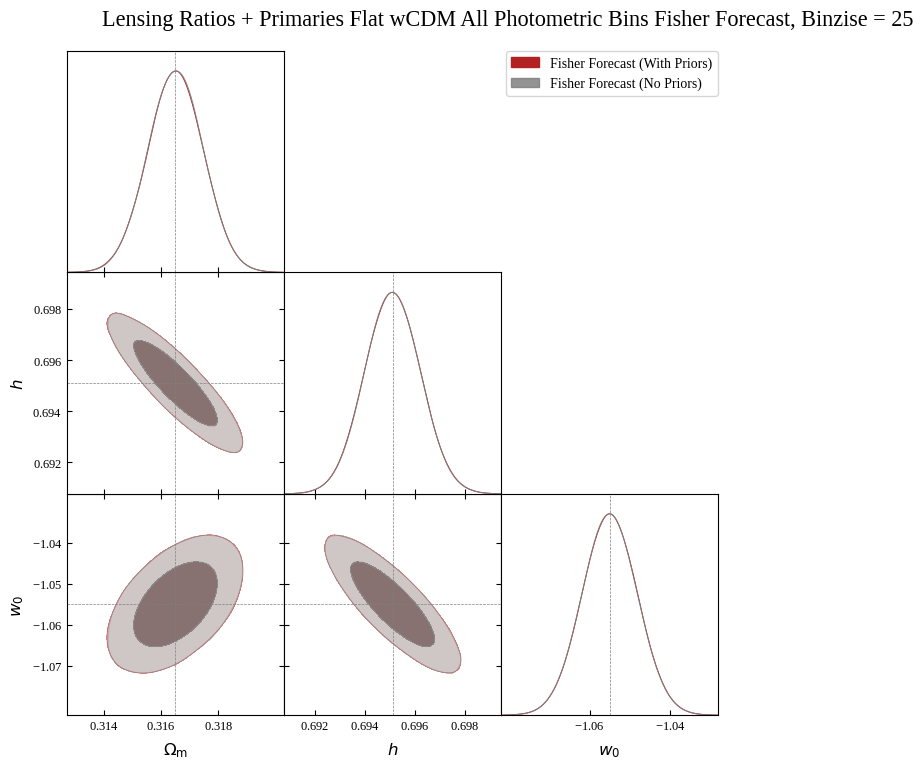

total_time:  0:03:00.267447


In [50]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_wCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=25,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_cmb_noise_TT,
    cmb_noise_EE=SO_cmb_noise_EE,
    cmb_noise_TE=SO_cmb_noise_TE,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['CG', 'GL', 'TT', 'TE', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h', 'w0']
params_to_plot = ['Omega_m', 'h', 'w0']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_wCDM_LRP_All_Photometric_Bins_Binsize=25.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h w0',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, w0\n'
)
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_wCDM_LRP_All_Photometric_Bins_Binsize=25.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h w0',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, w0\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Lensing Ratios + Primaries Flat wCDM All Photometric Bins Fisher Forecast, Binzise = 25",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

### Flat w0waCDM: $\Omega_m, h, w_0, w_a$

#### Lensing Ratios

Plot successfully saved to: plots/Fisher Forecasts/lensing_ratios_flat_w0wa_all_photometric_bins_fisher_forecast_binzise_=_100.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.313\pm 0.034$ | $\Omega_m = 0.313^{+0.067}_{-0.067}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.316\pm 0.035$ | $\Omega_m = 0.316^{+0.069}_{-0.070}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.685\pm 0.060$ | $h = 0.69^{+0.12}_{-0.11}$ |
|  | Fisher Forecast (No Priors) | $h = 0.668\pm 0.064$ | $h = 0.67^{+0.13}_{-0.13}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.82^{+0.35}_{-0.24}$ | $w_0 = -0.82^{+0.51}_{-0.52}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.75\pm 0.33$ | $w_0 = -0.75^{+0.65}_{-0.65}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.72^{+0.89}_{-1.1}$ | $w_a = -0.7^{+1.9}_{-1.9}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.9\pm 1.1$ | $w_a = -0.9^{+2.2}_{-2.2}$ |
| --- | --- | --- | --- |

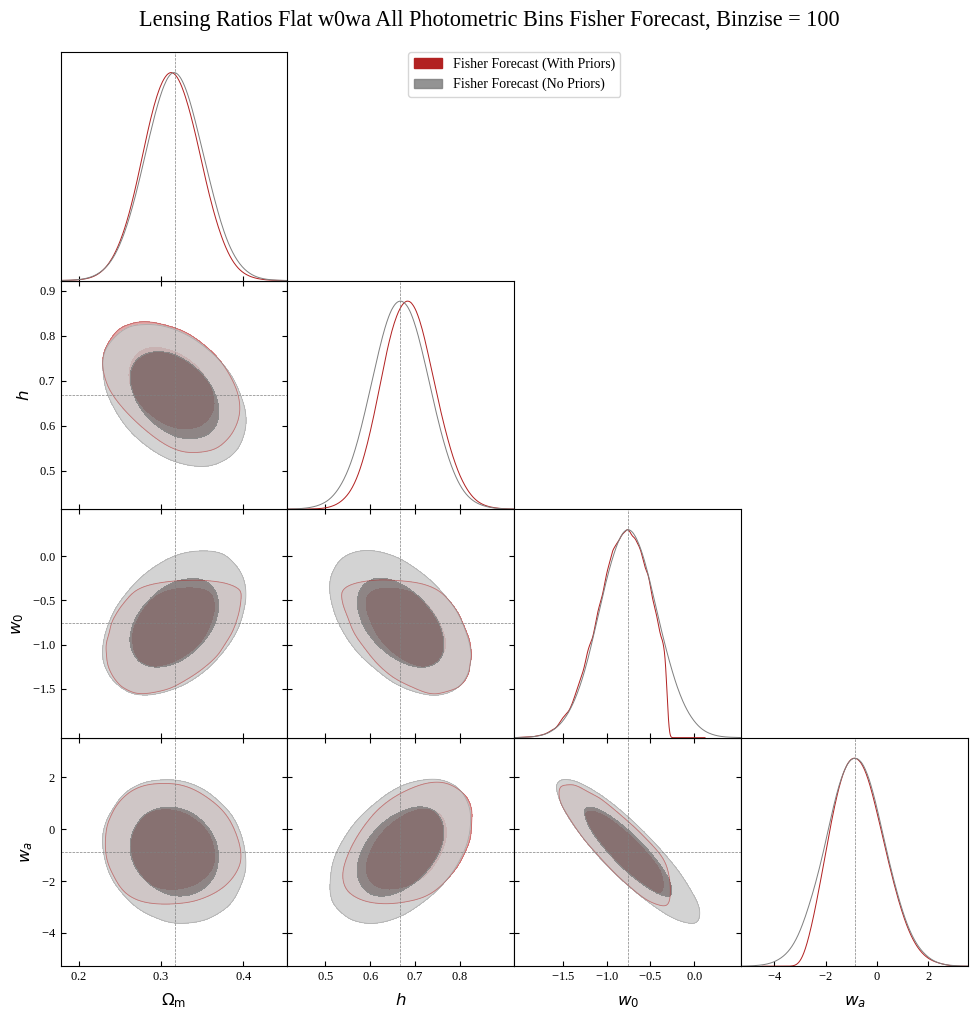

total_time:  0:01:17.987429


In [33]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_w0waCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=100,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=None,
    cmb_noise_EE=None,
    cmb_noise_TE=None,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['CG', 'GL'],
    cmb_primaries=False,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h', 'w0', 'wa']
params_to_plot = ['Omega_m', 'h', 'w0', 'wa']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_w0waCDM_LR_All_Photometric_Bins_Binsize=100.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h w0 wa',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, w0, wa\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_w0waCDM_LR_All_Photometric_Bins_Binsize=100.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h w0 wa',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, w0, wa\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Lensing Ratios Flat w0wa All Photometric Bins Fisher Forecast, Binzise = 100",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Plot successfully saved to: plots/Fisher Forecasts/lensing_ratios_flat_w0wa_all_photometric_bins_fisher_forecast_binzise_=_50.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.314\pm 0.027$ | $\Omega_m = 0.314^{+0.053}_{-0.053}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.317\pm 0.028$ | $\Omega_m = 0.317^{+0.054}_{-0.055}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.675\pm 0.047$ | $h = 0.675^{+0.092}_{-0.091}$ |
|  | Fisher Forecast (No Priors) | $h = 0.667\pm 0.048$ | $h = 0.667^{+0.095}_{-0.095}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.78^{+0.24}_{-0.21}$ | $w_0 = -0.78^{+0.43}_{-0.42}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.75\pm 0.24$ | $w_0 = -0.75^{+0.47}_{-0.47}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.83\pm 0.72$ | $w_a = -0.8^{+1.5}_{-1.4}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.86\pm 0.75$ | $w_a = -0.9^{+1.5}_{-1.5}$ |
| --- | --- | --- | --- |

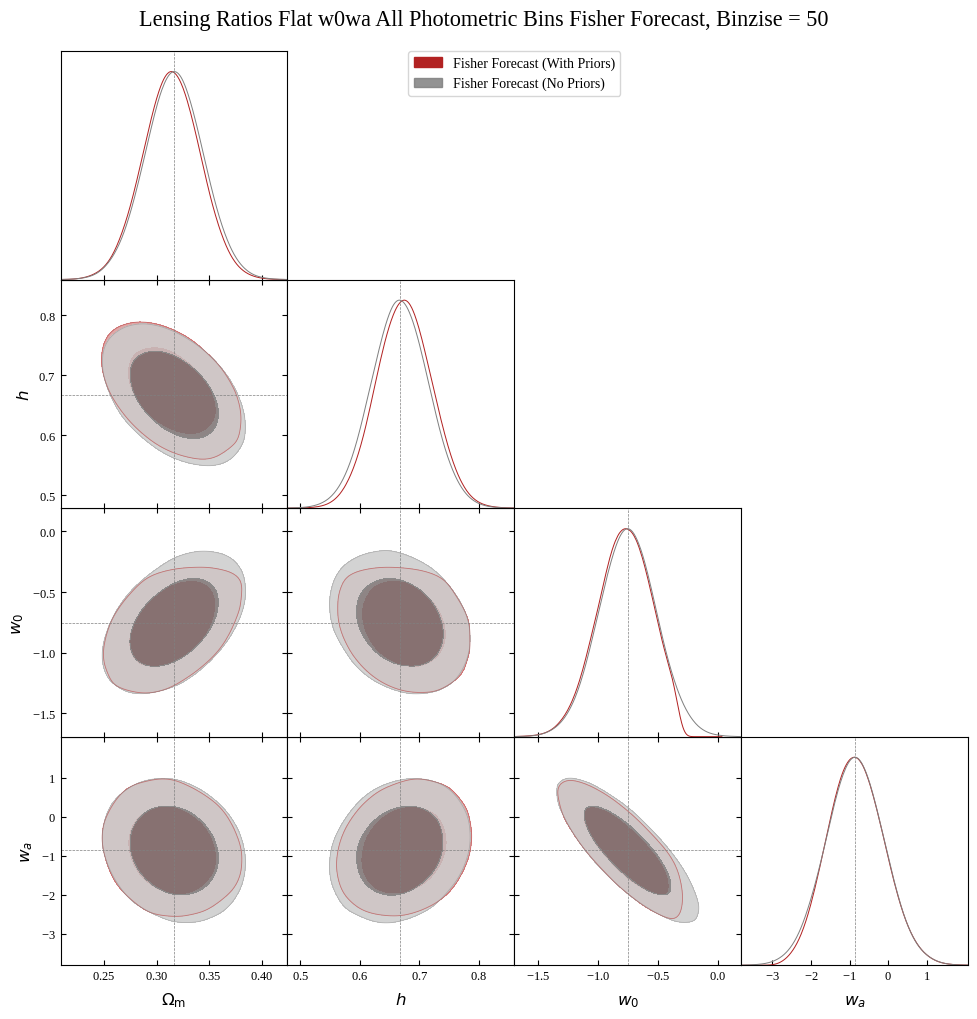

total_time:  0:01:41.019179


In [34]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_w0waCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=50,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=None,
    cmb_noise_EE=None,
    cmb_noise_TE=None,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['CG', 'GL'],
    cmb_primaries=False,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h', 'w0', 'wa']
params_to_plot = ['Omega_m', 'h', 'w0', 'wa']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_w0waCDM_LR_All_Photometric_Bins_Binsize=50.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h w0 wa',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, w0, wa\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_w0waCDM_LR_All_Photometric_Bins_Binsize=50.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h w0 wa',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, w0, wa\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Lensing Ratios Flat w0wa All Photometric Bins Fisher Forecast, Binzise = 50",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Plot successfully saved to: plots/Fisher Forecasts/lensing_ratios_flat_w0wa_all_photometric_bins_fisher_forecast_binzise_=_25.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.315\pm 0.020$ | $\Omega_m = 0.315^{+0.040}_{-0.040}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.317\pm 0.021$ | $\Omega_m = 0.317^{+0.040}_{-0.040}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.671\pm 0.039$ | $h = 0.671^{+0.076}_{-0.075}$ |
|  | Fisher Forecast (No Priors) | $h = 0.667\pm 0.039$ | $h = 0.667^{+0.076}_{-0.076}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.76\pm 0.19$ | $w_0 = -0.76^{+0.36}_{-0.38}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.75\pm 0.20$ | $w_0 = -0.75^{+0.38}_{-0.38}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.85\pm 0.57$ | $w_a = -0.9^{+1.1}_{-1.1}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.86\pm 0.58$ | $w_a = -0.9^{+1.1}_{-1.1}$ |
| --- | --- | --- | --- |

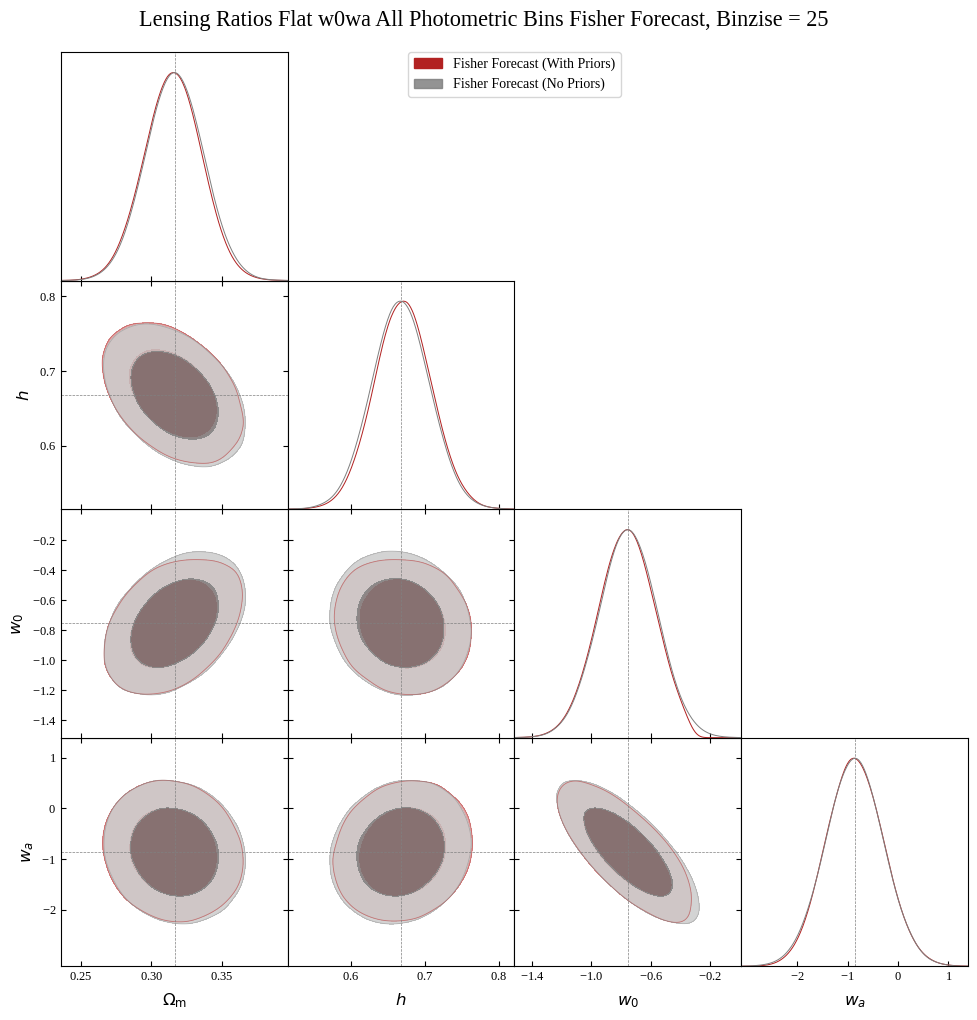

total_time:  0:02:24.783604


In [35]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_w0waCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=25,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=None,
    cmb_noise_EE=None,
    cmb_noise_TE=None,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['CG', 'GL'],
    cmb_primaries=False,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h', 'w0', 'wa']
params_to_plot = ['Omega_m', 'h', 'w0', 'wa']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_w0waCDM_LR_All_Photometric_Bins_Binsize=25.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h w0 wa',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, w0, wa\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_w0waCDM_LR_All_Photometric_Bins_Binsize=25.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h w0 wa',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, w0, wa\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Lensing Ratios Flat w0wa All Photometric Bins Fisher Forecast, Binzise = 25",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

#### Primaries

Plot successfully saved to: plots/Fisher Forecasts/primaries_flat_w0wa_all_photometric_bins_fisher_forecast_binzise_=_100.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.3166\pm 0.0058$ | $\Omega_m = 0.317^{+0.011}_{-0.011}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3166\pm 0.0058$ | $\Omega_m = 0.317^{+0.011}_{-0.011}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6674\pm 0.0058$ | $h = 0.667^{+0.011}_{-0.011}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6674\pm 0.0058$ | $h = 0.667^{+0.011}_{-0.011}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.752\pm 0.050$ | $w_0 = -0.752^{+0.098}_{-0.097}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.752\pm 0.050$ | $w_0 = -0.752^{+0.097}_{-0.097}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.86\pm 0.22$ | $w_a = -0.86^{+0.42}_{-0.42}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.86\pm 0.22$ | $w_a = -0.86^{+0.42}_{-0.42}$ |
| --- | --- | --- | --- |

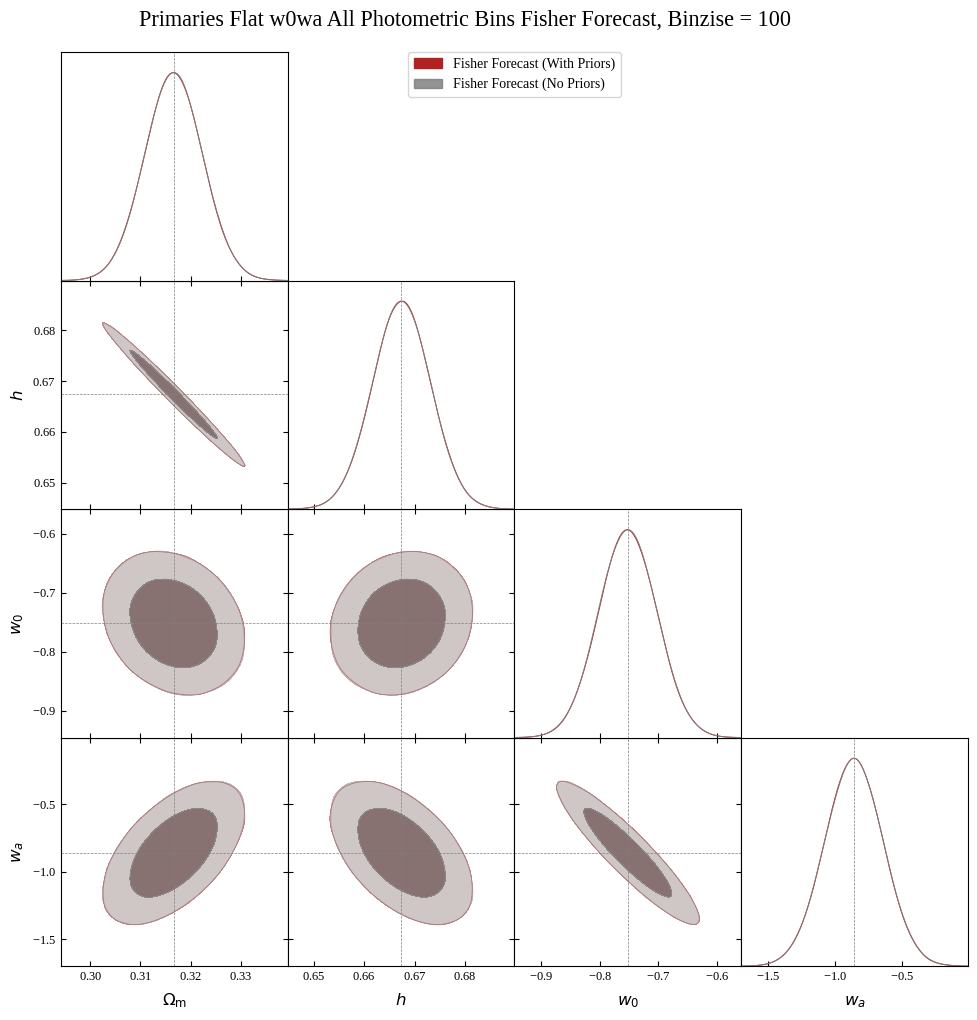

total_time:  0:01:42.223145


In [36]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_w0waCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=100,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_cmb_noise_TT,
    cmb_noise_EE=SO_cmb_noise_EE,
    cmb_noise_TE=SO_cmb_noise_TE,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['TT', 'TE', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h', 'w0', 'wa']
params_to_plot = ['Omega_m', 'h', 'w0', 'wa']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_w0waCDM_Primaries_All_Photometric_Bins_Binsize=100.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h w0 wa',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, w0, wa\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_w0waCDM_Primaries_All_Photometric_Bins_Binsize=100.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h w0 wa',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, w0, wa\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Primaries Flat w0wa All Photometric Bins Fisher Forecast, Binzise = 100",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Plot successfully saved to: plots/Fisher Forecasts/primaries_flat_w0wa_all_photometric_bins_fisher_forecast_binzise_=_50.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.3166\pm 0.0056$ | $\Omega_m = 0.317^{+0.011}_{-0.011}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3166\pm 0.0055$ | $\Omega_m = 0.317^{+0.011}_{-0.011}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6674\pm 0.0056$ | $h = 0.667^{+0.011}_{-0.011}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6674\pm 0.0055$ | $h = 0.667^{+0.011}_{-0.011}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.752\pm 0.048$ | $w_0 = -0.752^{+0.094}_{-0.094}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.752\pm 0.048$ | $w_0 = -0.752^{+0.094}_{-0.094}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.86\pm 0.21$ | $w_a = -0.86^{+0.41}_{-0.41}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.86\pm 0.21$ | $w_a = -0.86^{+0.41}_{-0.41}$ |
| --- | --- | --- | --- |

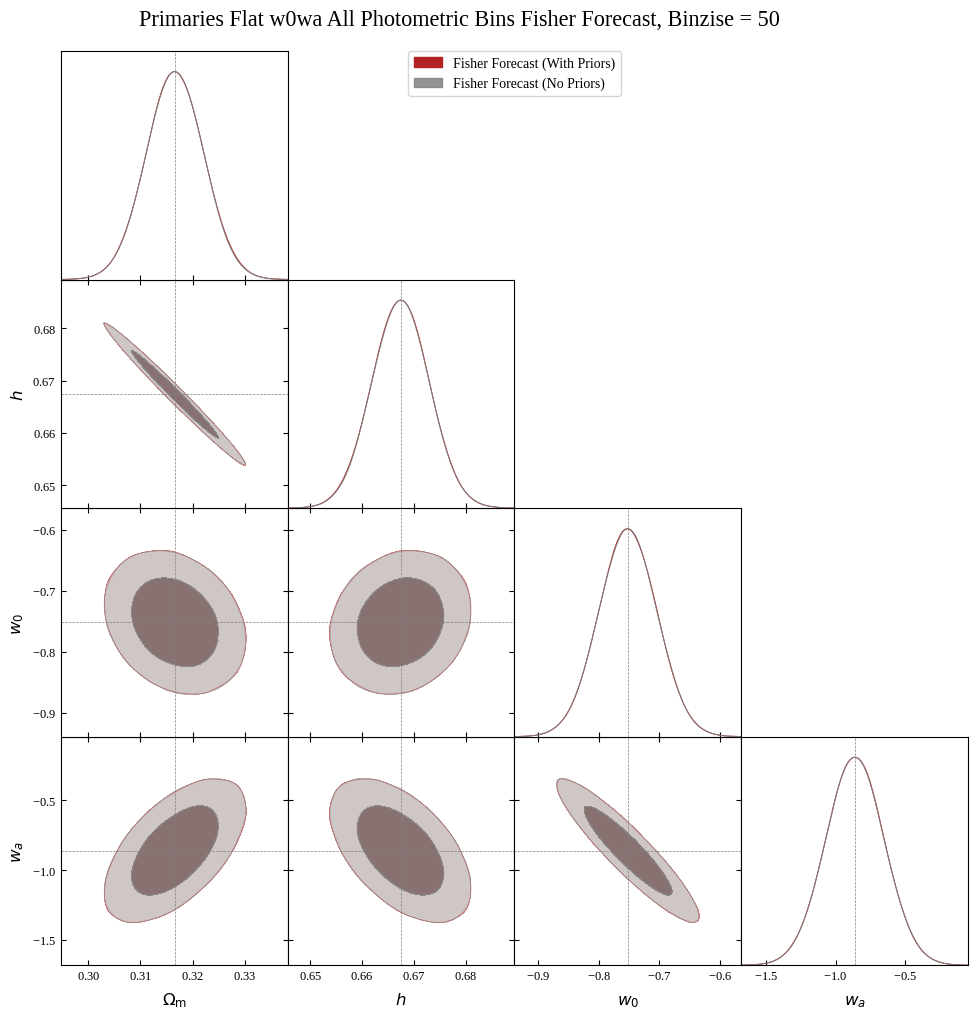

total_time:  0:02:11.073277


In [37]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_w0waCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=50,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_cmb_noise_TT,
    cmb_noise_EE=SO_cmb_noise_EE,
    cmb_noise_TE=SO_cmb_noise_TE,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['TT', 'TE', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h', 'w0', 'wa']
params_to_plot = ['Omega_m', 'h', 'w0', 'wa']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_w0waCDM_Primaries_All_Photometric_Bins_Binsize=50.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h w0 wa',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, w0, wa\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_w0waCDM_Primaries_All_Photometric_Bins_Binsize=50.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h w0 wa',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, w0, wa\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Primaries Flat w0wa All Photometric Bins Fisher Forecast, Binzise = 50",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Plot successfully saved to: plots/Fisher Forecasts/primaries_flat_w0wa_all_photometric_bins_fisher_forecast_binzise_=_25.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.3166\pm 0.0055$ | $\Omega_m = 0.317^{+0.011}_{-0.011}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3166\pm 0.0055$ | $\Omega_m = 0.317^{+0.011}_{-0.011}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6674\pm 0.0055$ | $h = 0.667^{+0.011}_{-0.011}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6674\pm 0.0055$ | $h = 0.667^{+0.011}_{-0.011}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.752\pm 0.048$ | $w_0 = -0.752^{+0.094}_{-0.094}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.752\pm 0.048$ | $w_0 = -0.752^{+0.094}_{-0.094}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.86\pm 0.21$ | $w_a = -0.86^{+0.41}_{-0.41}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.86\pm 0.21$ | $w_a = -0.86^{+0.41}_{-0.41}$ |
| --- | --- | --- | --- |

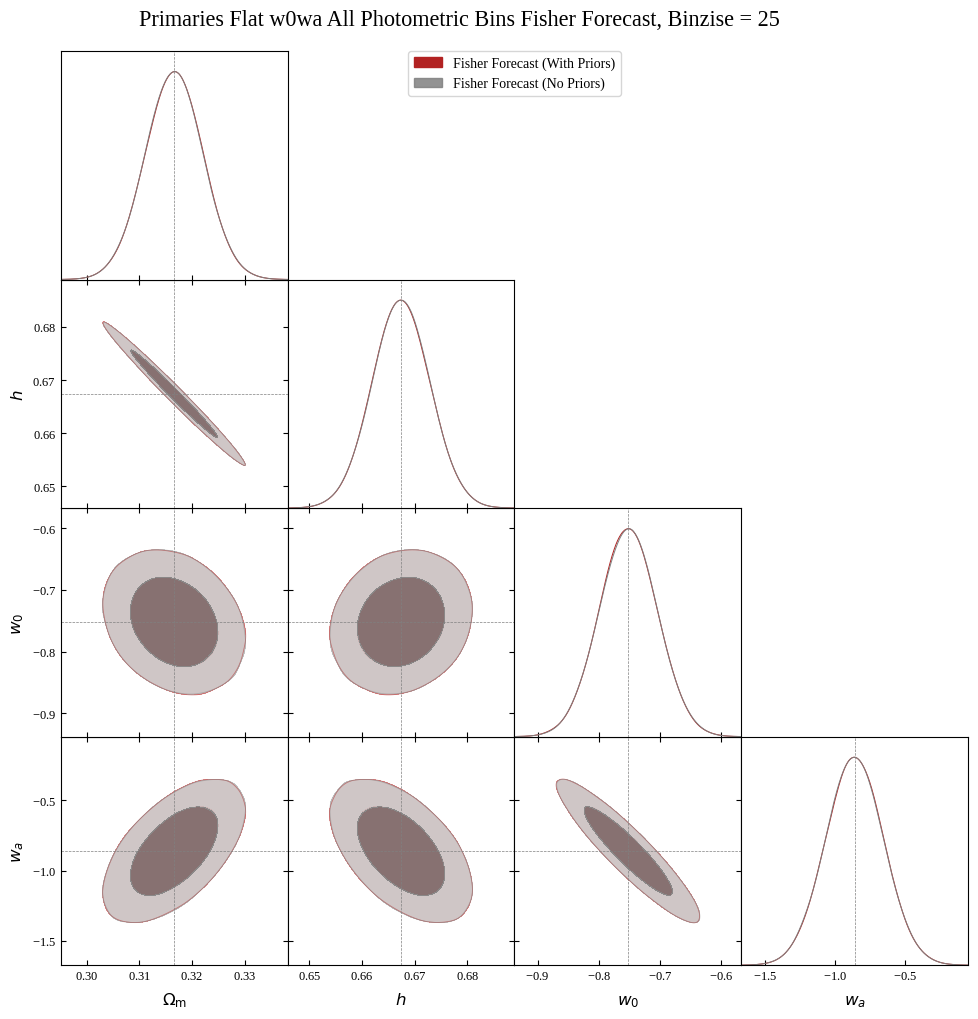

total_time:  0:03:07.916898


In [38]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_w0waCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=25,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_cmb_noise_TT,
    cmb_noise_EE=SO_cmb_noise_EE,
    cmb_noise_TE=SO_cmb_noise_TE,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['TT', 'TE', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h', 'w0', 'wa']
params_to_plot = ['Omega_m', 'h', 'w0', 'wa']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_w0waCDM_Primaries_All_Photometric_Bins_Binsize=25.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h w0 wa',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, w0, wa\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_w0waCDM_Primaries_All_Photometric_Bins_Binsize=25.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h w0 wa',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, w0, wa\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Primaries Flat w0wa All Photometric Bins Fisher Forecast, Binzise = 25",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

#### Lensing Ratios and Primaries

Plot successfully saved to: plots/Fisher Forecasts/lensing_ratios_+_primaries_flat_w0wa_all_photometric_bins_fisher_forecast_binzise_=_100.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.3166\pm 0.0056$ | $\Omega_m = 0.317^{+0.011}_{-0.011}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3166\pm 0.0056$ | $\Omega_m = 0.317^{+0.011}_{-0.011}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6674\pm 0.0055$ | $h = 0.667^{+0.011}_{-0.011}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6674\pm 0.0055$ | $h = 0.667^{+0.011}_{-0.011}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.752\pm 0.048$ | $w_0 = -0.752^{+0.095}_{-0.095}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.752\pm 0.048$ | $w_0 = -0.752^{+0.095}_{-0.095}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.86\pm 0.20$ | $w_a = -0.86^{+0.40}_{-0.40}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.86\pm 0.20$ | $w_a = -0.86^{+0.40}_{-0.40}$ |
| --- | --- | --- | --- |

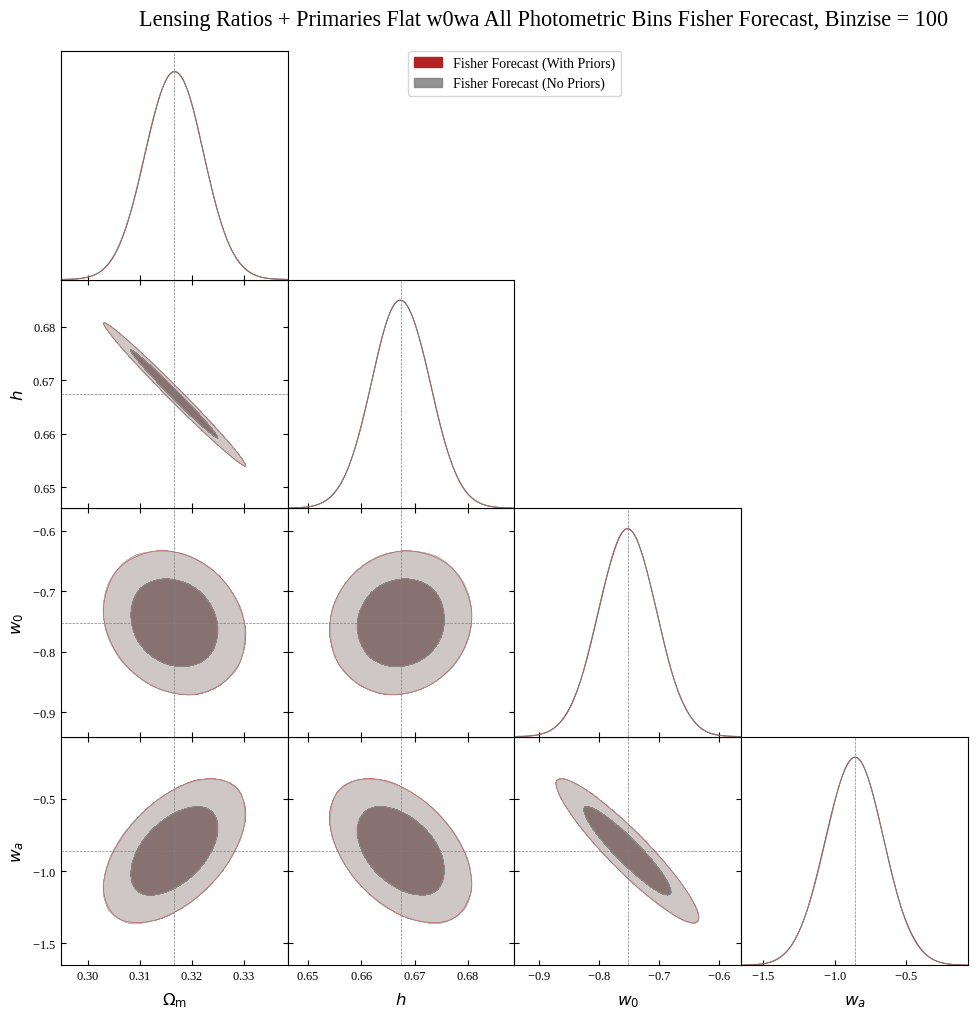

total_time:  0:01:41.395673


In [39]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_w0waCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=100,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_cmb_noise_TT,
    cmb_noise_EE=SO_cmb_noise_EE,
    cmb_noise_TE=SO_cmb_noise_TE,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['CG', 'GL', 'TT', 'TE', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h', 'w0', 'wa']
params_to_plot = ['Omega_m', 'h', 'w0', 'wa']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_w0waCDM_LRP_All_Photometric_Bins_Binsize=100.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h w0 wa',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, w0, wa\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_w0waCDM_LRP_All_Photometric_Bins_Binsize=100.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h w0 wa',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, w0, wa\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Lensing Ratios + Primaries Flat w0wa All Photometric Bins Fisher Forecast, Binzise = 100",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Plot successfully saved to: plots/Fisher Forecasts/lensing_ratios_+_primaries_flat_w0wa_all_photometric_bins_fisher_forecast_binzise_=_50.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.3166\pm 0.0052$ | $\Omega_m = 0.317^{+0.010}_{-0.010}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3166\pm 0.0053$ | $\Omega_m = 0.317^{+0.010}_{-0.010}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6674\pm 0.0052$ | $h = 0.667^{+0.010}_{-0.010}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6674\pm 0.0052$ | $h = 0.667^{+0.010}_{-0.010}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.752\pm 0.046$ | $w_0 = -0.752^{+0.090}_{-0.090}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.752\pm 0.046$ | $w_0 = -0.752^{+0.091}_{-0.090}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.86\pm 0.19$ | $w_a = -0.86^{+0.38}_{-0.38}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.86\pm 0.19$ | $w_a = -0.86^{+0.38}_{-0.38}$ |
| --- | --- | --- | --- |

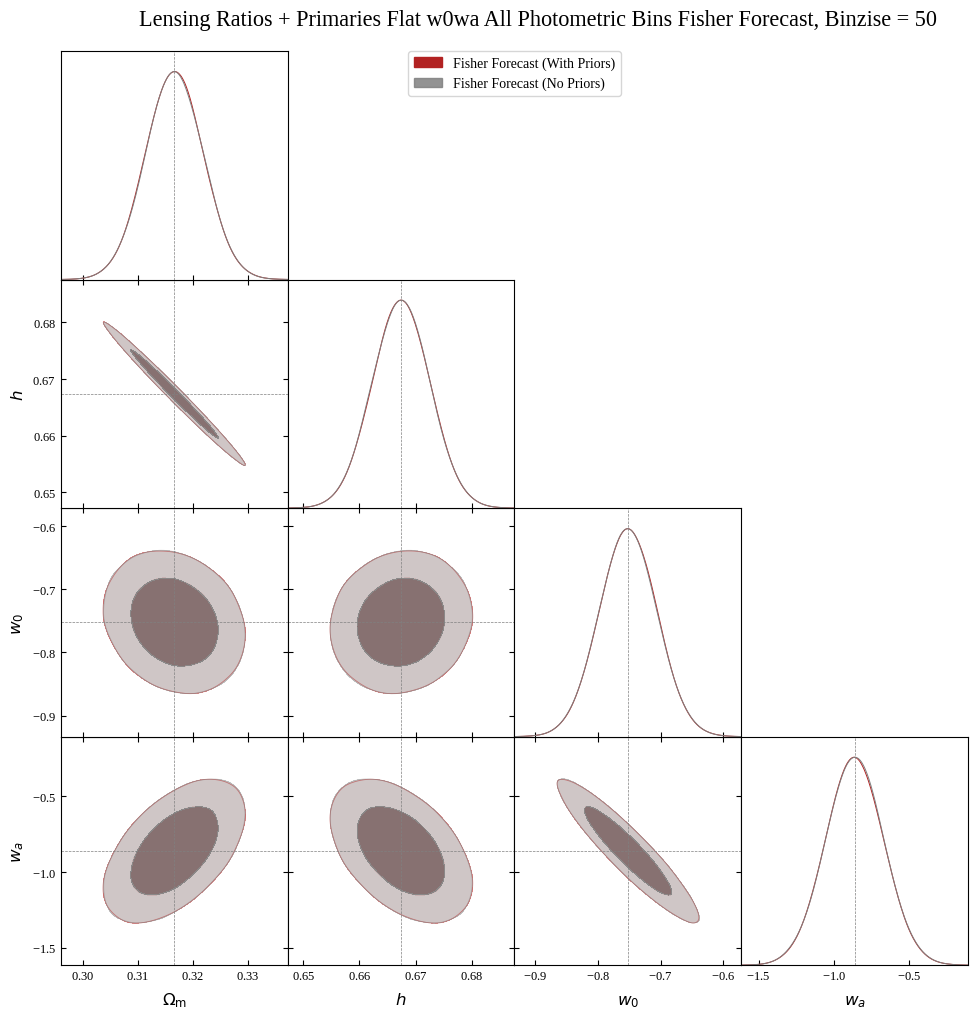

total_time:  0:02:12.506626


In [40]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_w0waCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=50,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_cmb_noise_TT,
    cmb_noise_EE=SO_cmb_noise_EE,
    cmb_noise_TE=SO_cmb_noise_TE,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['CG', 'GL', 'TT', 'TE', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h', 'w0', 'wa']
params_to_plot = ['Omega_m', 'h', 'w0', 'wa']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_w0waCDM_LRP_All_Photometric_Bins_Binsize=50.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h w0 wa',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, w0, wa\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_w0waCDM_LRP_All_Photometric_Bins_Binsize=50.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h w0 wa',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, w0, wa\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Lensing Ratios + Primaries Flat w0wa All Photometric Bins Fisher Forecast, Binzise = 50",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Plot successfully saved to: plots/Fisher Forecasts/lensing_ratios_+_primaries_flat_w0wa_all_photometric_bins_fisher_forecast_binzise_=_25.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.3166\pm 0.0051$ | $\Omega_m = 0.317^{+0.010}_{-0.010}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3166\pm 0.0051$ | $\Omega_m = 0.317^{+0.010}_{-0.010}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6674\pm 0.0050$ | $h = 0.6674^{+0.0098}_{-0.0098}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6674\pm 0.0050$ | $h = 0.6674^{+0.0099}_{-0.0099}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.752\pm 0.045$ | $w_0 = -0.752^{+0.088}_{-0.088}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.752\pm 0.045$ | $w_0 = -0.752^{+0.088}_{-0.088}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.86\pm 0.19$ | $w_a = -0.86^{+0.37}_{-0.37}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.86\pm 0.19$ | $w_a = -0.86^{+0.37}_{-0.37}$ |
| --- | --- | --- | --- |

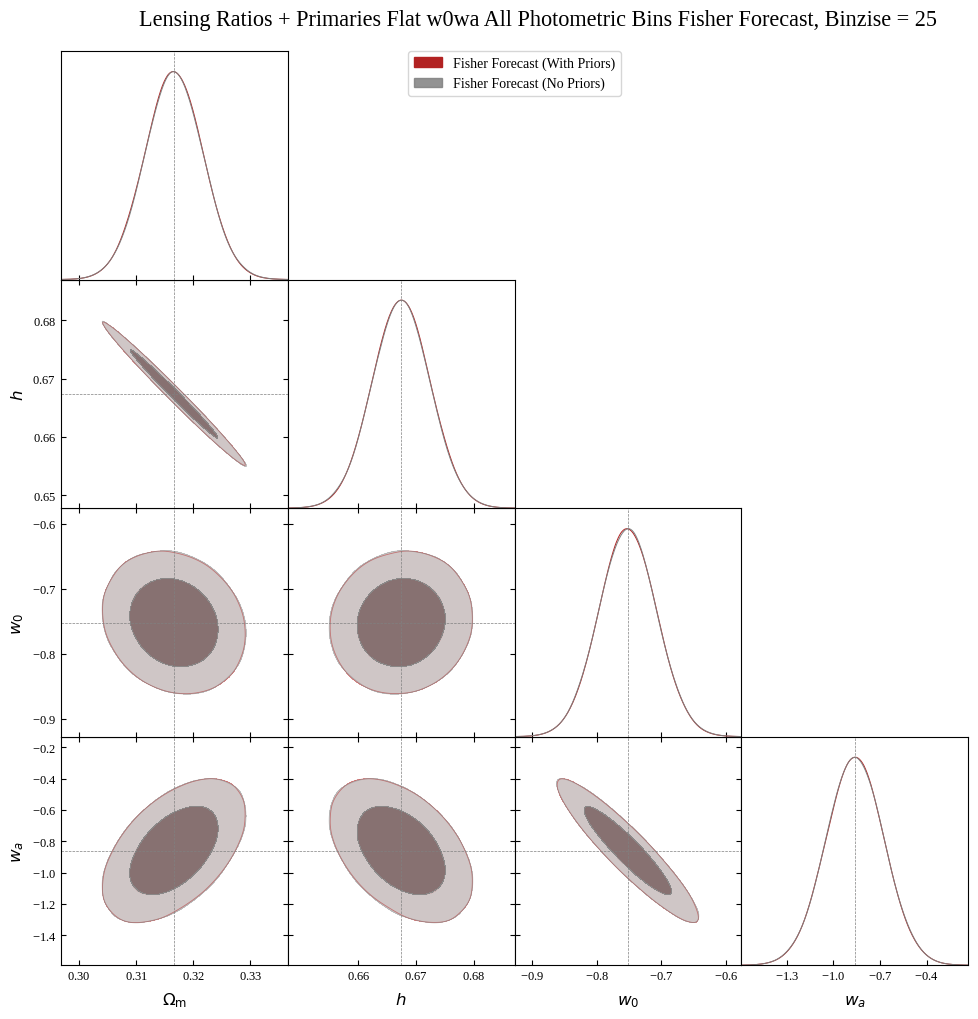

total_time:  0:03:41.523052


In [41]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_w0waCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=25,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_cmb_noise_TT,
    cmb_noise_EE=SO_cmb_noise_EE,
    cmb_noise_TE=SO_cmb_noise_TE,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['CG', 'GL', 'TT', 'TE', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h', 'w0', 'wa']
params_to_plot = ['Omega_m', 'h', 'w0', 'wa']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_w0waCDM_LRP_All_Photometric_Bins_Binsize=25.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h w0 wa',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, w0, wa\n'
)
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_w0waCDM_LRP_All_Photometric_Bins_Binsize=25.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h w0 wa',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, w0, wa\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Lensing Ratios + Primaries Flat w0wa All Photometric Bins Fisher Forecast, Binzise = 25",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

### Curved w0waCDM: $\Omega_m, h, \Omega_k, w_0, w_a$

#### Lensing Ratios

Plot successfully saved to: plots/Fisher Forecasts/lensing_ratios_curved_w0wa_all_photometric_bins_fisher_forecast_binzise_=_100.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.313\pm 0.034$ | $\Omega_m = 0.313^{+0.068}_{-0.067}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.316\pm 0.036$ | $\Omega_m = 0.316^{+0.070}_{-0.070}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.685\pm 0.062$ | $h = 0.68^{+0.12}_{-0.12}$ |
|  | Fisher Forecast (No Priors) | $h = 0.667\pm 0.068$ | $h = 0.67^{+0.13}_{-0.13}$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Fisher Forecast (With Priors) | $\Omega_k = -0.001\pm 0.023$ | $\Omega_k = -0.001^{+0.046}_{-0.046}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.000\pm 0.024$ | $\Omega_k = 0.000^{+0.047}_{-0.047}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.82^{+0.36}_{-0.24}$ | $w_0 = -0.82^{+0.51}_{-0.54}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.75\pm 0.34$ | $w_0 = -0.75^{+0.67}_{-0.68}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.72^{+0.89}_{-1.1}$ | $w_a = -0.7^{+1.9}_{-1.9}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.9\pm 1.2$ | $w_a = -0.9^{+2.3}_{-2.3}$ |
| --- | --- | --- | --- |

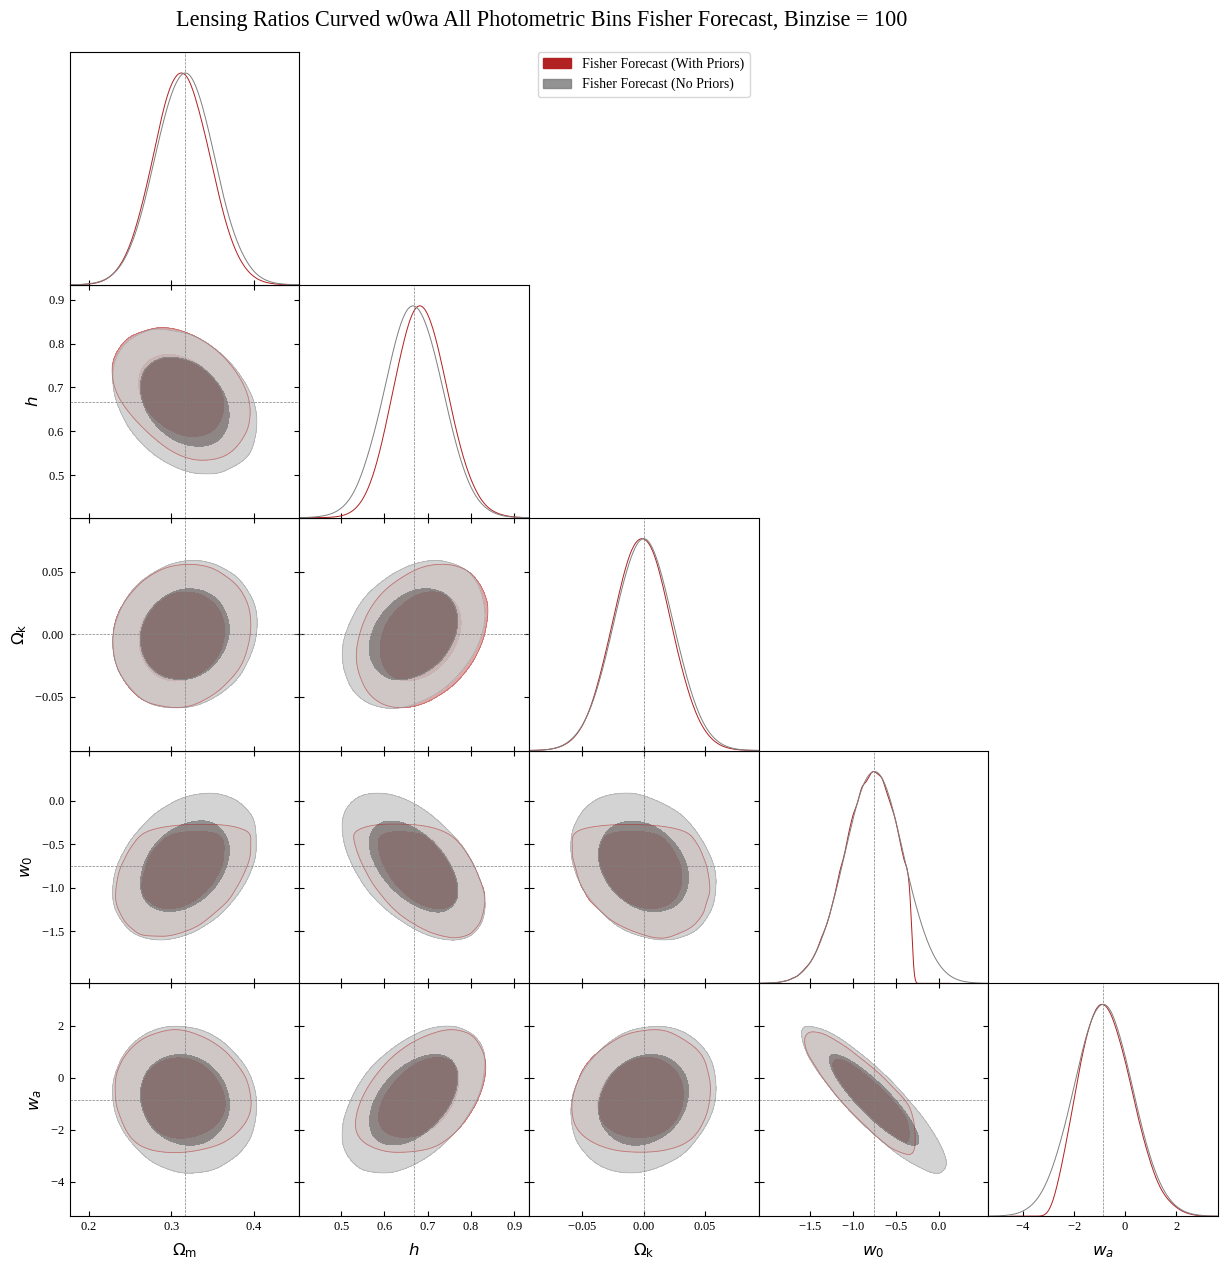

total_time:  0:01:36.017864


In [17]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=curved_w0waCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=100,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=None,
    cmb_noise_EE=None,
    cmb_noise_TE=None,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['CG', 'GL'],
    cmb_primaries=False,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h', 'Omega_k', 'w0', 'wa']
params_to_plot = ['Omega_m', 'h', 'Omega_k', 'w0', 'wa']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Curved_w0waCDM_LR_All_Photometric_Bins_Binsize=100.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h Omega_k w0 wa',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, Omega_k, w0, wa\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Curved_w0waCDM_LR_All_Photometric_Bins_Binsize=100.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h Omega_k w0 wa',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, Omega_k, w0, wa\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Lensing Ratios Curved w0wa All Photometric Bins Fisher Forecast, Binzise = 100",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Plot successfully saved to: plots/Fisher Forecasts/lensing_ratios_curved_w0wa_all_photometric_bins_fisher_forecast_binzise_=_50.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.314\pm 0.027$ | $\Omega_m = 0.314^{+0.053}_{-0.053}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.317\pm 0.028$ | $\Omega_m = 0.317^{+0.054}_{-0.054}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.674\pm 0.048$ | $h = 0.674^{+0.095}_{-0.094}$ |
|  | Fisher Forecast (No Priors) | $h = 0.667\pm 0.050$ | $h = 0.667^{+0.098}_{-0.097}$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Fisher Forecast (With Priors) | $\Omega_k = -0.001\pm 0.022$ | $\Omega_k = -0.001^{+0.044}_{-0.044}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.000\pm 0.023$ | $\Omega_k = 0.000^{+0.044}_{-0.044}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.78^{+0.25}_{-0.21}$ | $w_0 = -0.78^{+0.43}_{-0.42}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.75\pm 0.25$ | $w_0 = -0.75^{+0.48}_{-0.48}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.83\pm 0.72$ | $w_a = -0.8^{+1.4}_{-1.4}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.86\pm 0.76$ | $w_a = -0.9^{+1.5}_{-1.5}$ |
| --- | --- | --- | --- |

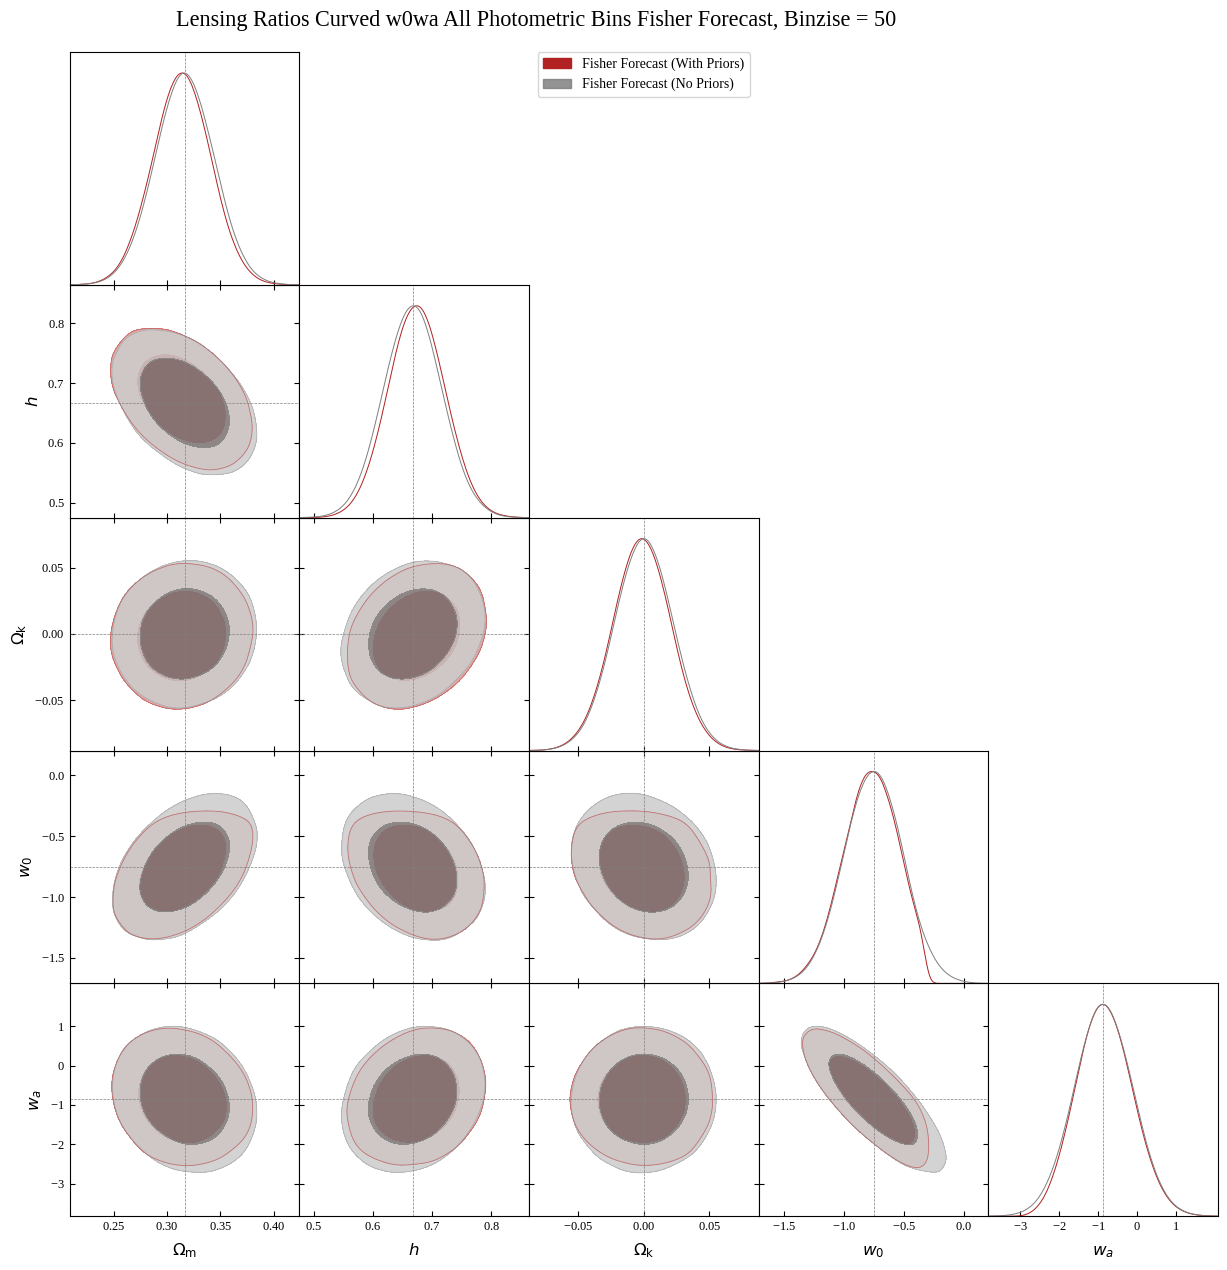

total_time:  0:02:01.902847


In [18]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=curved_w0waCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=50,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=None,
    cmb_noise_EE=None,
    cmb_noise_TE=None,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['CG', 'GL'],
    cmb_primaries=False,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h', 'Omega_k', 'w0', 'wa']
params_to_plot = ['Omega_m', 'h', 'Omega_k', 'w0', 'wa']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Curved_w0waCDM_LR_All_Photometric_Bins_Binsize=50.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h Omega_k w0 wa',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, Omega_k, w0, wa\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Curved_w0waCDM_LR_All_Photometric_Bins_Binsize=50.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h Omega_k w0 wa',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, Omega_k, w0, wa\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Lensing Ratios Curved w0wa All Photometric Bins Fisher Forecast, Binzise = 50",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Plot successfully saved to: plots/Fisher Forecasts/lensing_ratios_curved_w0wa_all_photometric_bins_fisher_forecast_binzise_=_25.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.315\pm 0.020$ | $\Omega_m = 0.315^{+0.040}_{-0.040}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.317\pm 0.021$ | $\Omega_m = 0.317^{+0.040}_{-0.041}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.670\pm 0.040$ | $h = 0.670^{+0.079}_{-0.078}$ |
|  | Fisher Forecast (No Priors) | $h = 0.667\pm 0.040$ | $h = 0.667^{+0.079}_{-0.079}$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Fisher Forecast (With Priors) | $\Omega_k = -0.001\pm 0.021$ | $\Omega_k = -0.001^{+0.042}_{-0.042}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.000\pm 0.022$ | $\Omega_k = 0.000^{+0.042}_{-0.042}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.77\pm 0.19$ | $w_0 = -0.77^{+0.38}_{-0.37}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.75\pm 0.20$ | $w_0 = -0.75^{+0.39}_{-0.39}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.84\pm 0.57$ | $w_a = -0.8^{+1.1}_{-1.1}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.86\pm 0.58$ | $w_a = -0.9^{+1.1}_{-1.1}$ |
| --- | --- | --- | --- |

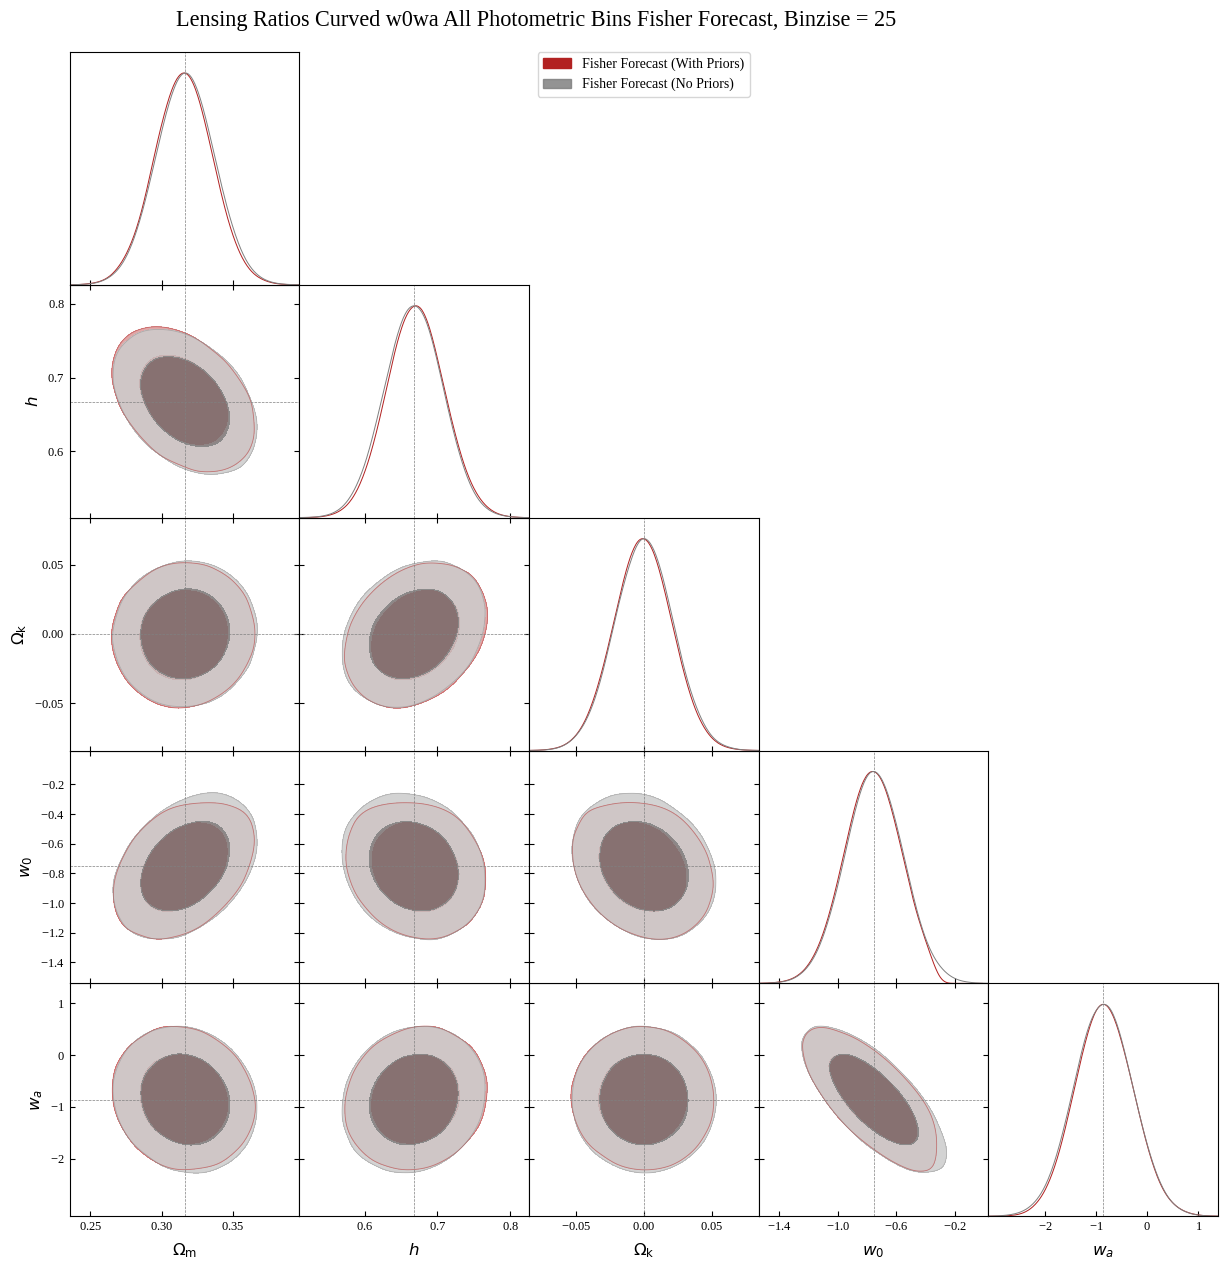

total_time:  0:02:59.780530


In [19]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=curved_w0waCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=25,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=None,
    cmb_noise_EE=None,
    cmb_noise_TE=None,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['CG', 'GL'],
    cmb_primaries=False,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h', 'Omega_k', 'w0', 'wa']
params_to_plot = ['Omega_m', 'h', 'Omega_k', 'w0', 'wa']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Curved_w0waCDM_LR_All_Photometric_Bins_Binsize=25.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h Omega_k w0 wa',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, Omega_k, w0, wa\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Curved_w0waCDM_LR_All_Photometric_Bins_Binsize=25.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h Omega_k w0 wa',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, Omega_k, w0, wa\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Lensing Ratios Curved w0wa All Photometric Bins Fisher Forecast, Binzise = 25",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

#### Primaries

Plot successfully saved to: plots/Fisher Forecasts/primaries_curved_w0wa_all_photometric_bins_fisher_forecast_binzise_=_100.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.3166\pm 0.0061$ | $\Omega_m = 0.317^{+0.012}_{-0.012}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3166\pm 0.0061$ | $\Omega_m = 0.317^{+0.012}_{-0.012}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6674\pm 0.0066$ | $h = 0.667^{+0.013}_{-0.013}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6674\pm 0.0065$ | $h = 0.667^{+0.013}_{-0.013}$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Fisher Forecast (With Priors) | $\Omega_k = 0.0000\pm 0.0019$ | $\Omega_k = 0.0000^{+0.0036}_{-0.0037}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.0000\pm 0.0019$ | $\Omega_k = 0.0000^{+0.0036}_{-0.0036}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.752\pm 0.067$ | $w_0 = -0.75^{+0.13}_{-0.13}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.752\pm 0.067$ | $w_0 = -0.75^{+0.13}_{-0.13}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.86\pm 0.25$ | $w_a = -0.86^{+0.49}_{-0.49}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.86\pm 0.25$ | $w_a = -0.86^{+0.49}_{-0.49}$ |
| --- | --- | --- | --- |

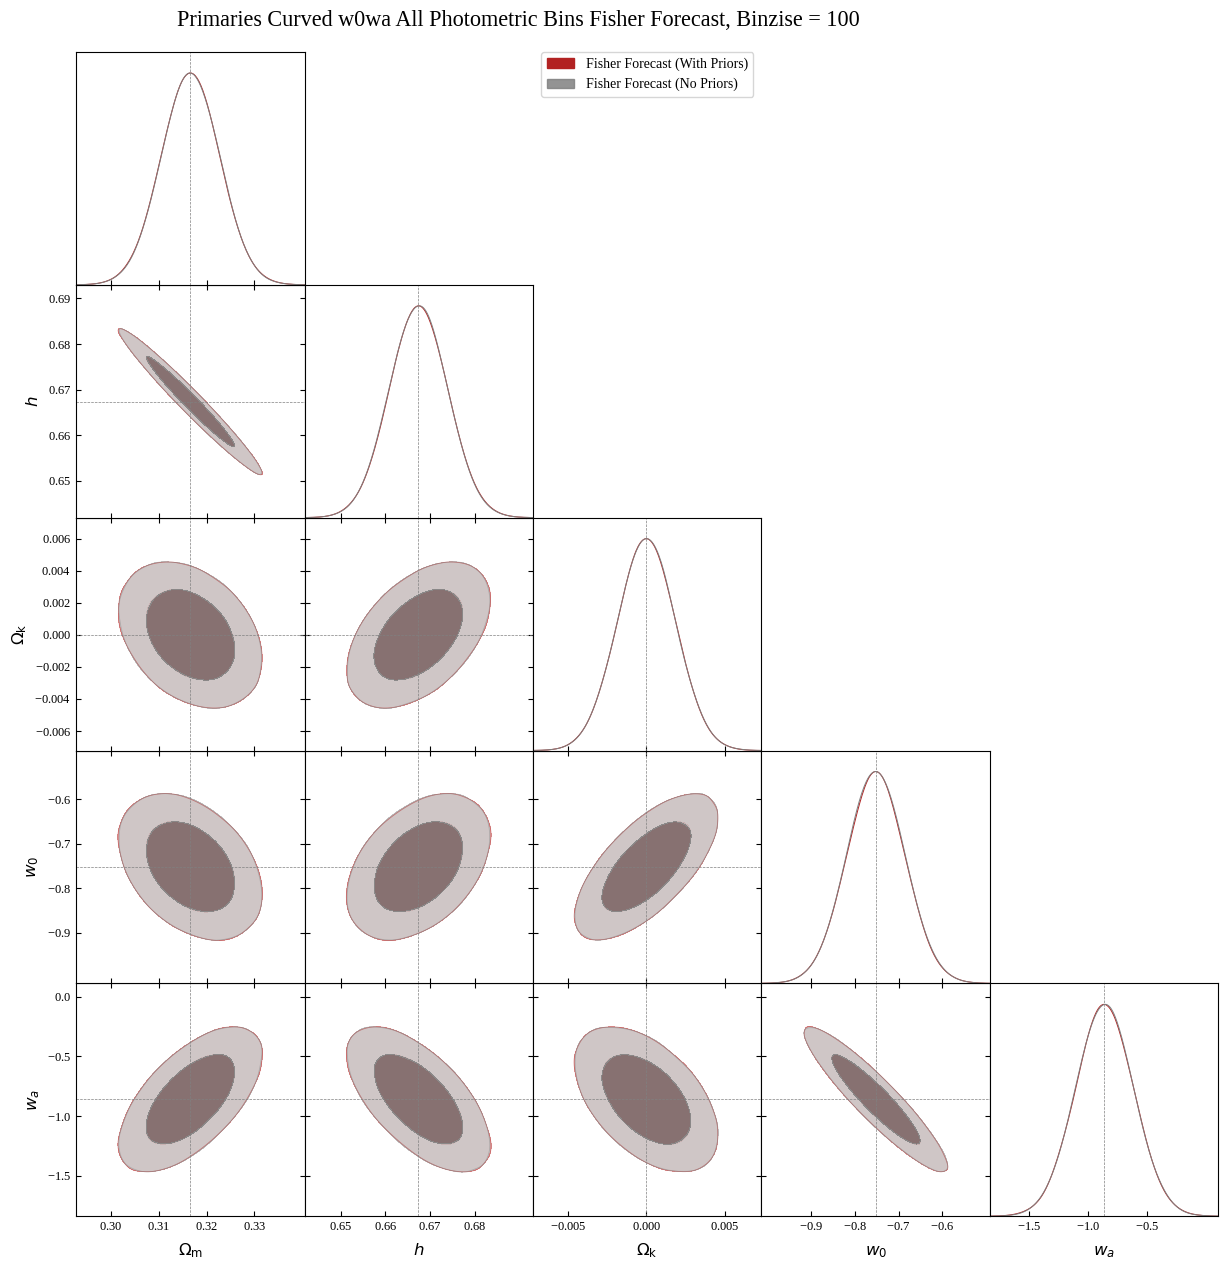

total_time:  0:02:13.714307


In [20]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=curved_w0waCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=100,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_cmb_noise_TT,
    cmb_noise_EE=SO_cmb_noise_EE,
    cmb_noise_TE=SO_cmb_noise_TE,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['TT', 'TE', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h', 'Omega_k', 'w0', 'wa']
params_to_plot = ['Omega_m', 'h', 'Omega_k', 'w0', 'wa']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Curved_w0waCDM_Primaries_All_Photometric_Bins_Binsize=100.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h Omega_k w0 wa',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, Omega_k, w0, wa\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Curved_w0waCDM_Primaries_All_Photometric_Bins_Binsize=100.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h Omega_k w0 wa',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, Omega_k, w0, wa\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Primaries Curved w0wa All Photometric Bins Fisher Forecast, Binzise = 100",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Plot successfully saved to: plots/Fisher Forecasts/primaries_curved_w0wa_all_photometric_bins_fisher_forecast_binzise_=_50.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.3166\pm 0.0058$ | $\Omega_m = 0.317^{+0.011}_{-0.011}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3166\pm 0.0058$ | $\Omega_m = 0.317^{+0.011}_{-0.011}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6674\pm 0.0062$ | $h = 0.667^{+0.012}_{-0.012}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6674\pm 0.0062$ | $h = 0.667^{+0.012}_{-0.012}$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Fisher Forecast (With Priors) | $\Omega_k = 0.0000\pm 0.0017$ | $\Omega_k = 0.0000^{+0.0034}_{-0.0034}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.0000\pm 0.0017$ | $\Omega_k = 0.0000^{+0.0034}_{-0.0034}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.752\pm 0.064$ | $w_0 = -0.75^{+0.13}_{-0.13}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.752\pm 0.064$ | $w_0 = -0.75^{+0.13}_{-0.13}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.86\pm 0.24$ | $w_a = -0.86^{+0.47}_{-0.47}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.86\pm 0.24$ | $w_a = -0.86^{+0.47}_{-0.47}$ |
| --- | --- | --- | --- |

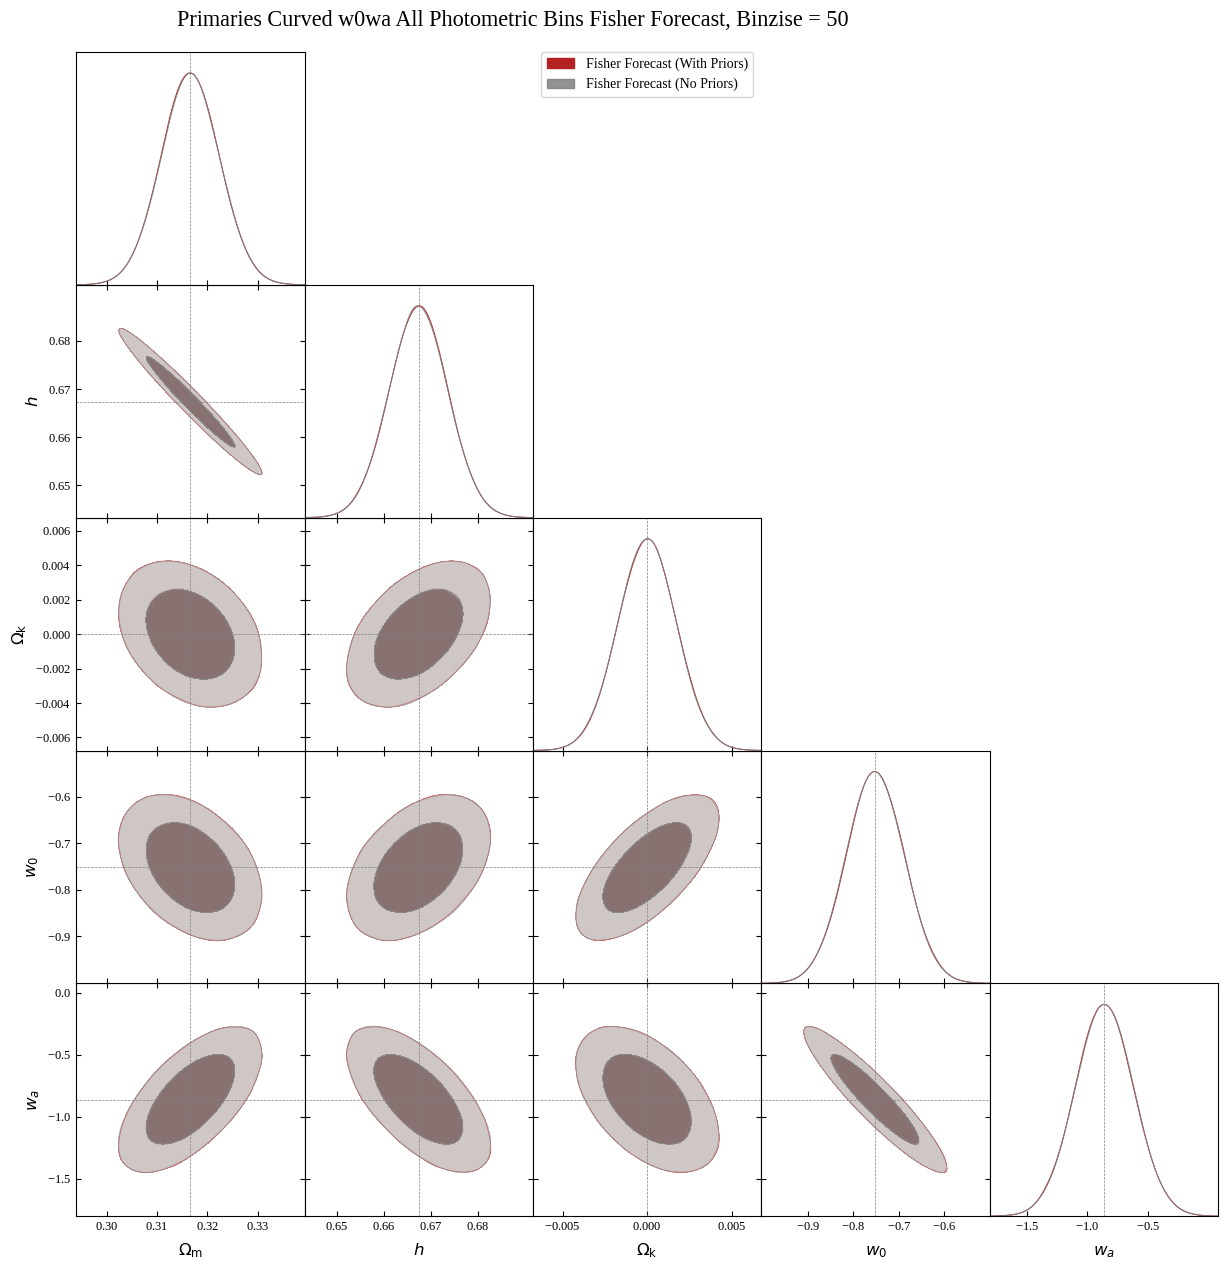

total_time:  0:02:35.143874


In [21]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=curved_w0waCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=50,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_cmb_noise_TT,
    cmb_noise_EE=SO_cmb_noise_EE,
    cmb_noise_TE=SO_cmb_noise_TE,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['TT', 'TE', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h', 'Omega_k', 'w0', 'wa']
params_to_plot = ['Omega_m', 'h', 'Omega_k', 'w0', 'wa']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Curved_w0waCDM_Primaries_All_Photometric_Bins_Binsize=50.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h Omega_k w0 wa',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, Omega_k, w0, wa\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Curved_w0waCDM_Primaries_All_Photometric_Bins_Binsize=50.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h Omega_k w0 wa',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, Omega_k, w0, wa\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Primaries Curved w0wa All Photometric Bins Fisher Forecast, Binzise = 50",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Plot successfully saved to: plots/Fisher Forecasts/primaries_curved_w0wa_all_photometric_bins_fisher_forecast_binzise_=_25.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.3166\pm 0.0058$ | $\Omega_m = 0.317^{+0.011}_{-0.011}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3166\pm 0.0058$ | $\Omega_m = 0.317^{+0.011}_{-0.011}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6674\pm 0.0062$ | $h = 0.667^{+0.012}_{-0.012}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6674\pm 0.0062$ | $h = 0.667^{+0.012}_{-0.012}$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Fisher Forecast (With Priors) | $\Omega_k = 0.0000\pm 0.0017$ | $\Omega_k = 0.0000^{+0.0033}_{-0.0033}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.0000\pm 0.0017$ | $\Omega_k = 0.0000^{+0.0033}_{-0.0033}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.752\pm 0.063$ | $w_0 = -0.75^{+0.12}_{-0.12}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.752\pm 0.063$ | $w_0 = -0.75^{+0.12}_{-0.12}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.86\pm 0.24$ | $w_a = -0.86^{+0.47}_{-0.47}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.86\pm 0.24$ | $w_a = -0.86^{+0.47}_{-0.47}$ |
| --- | --- | --- | --- |

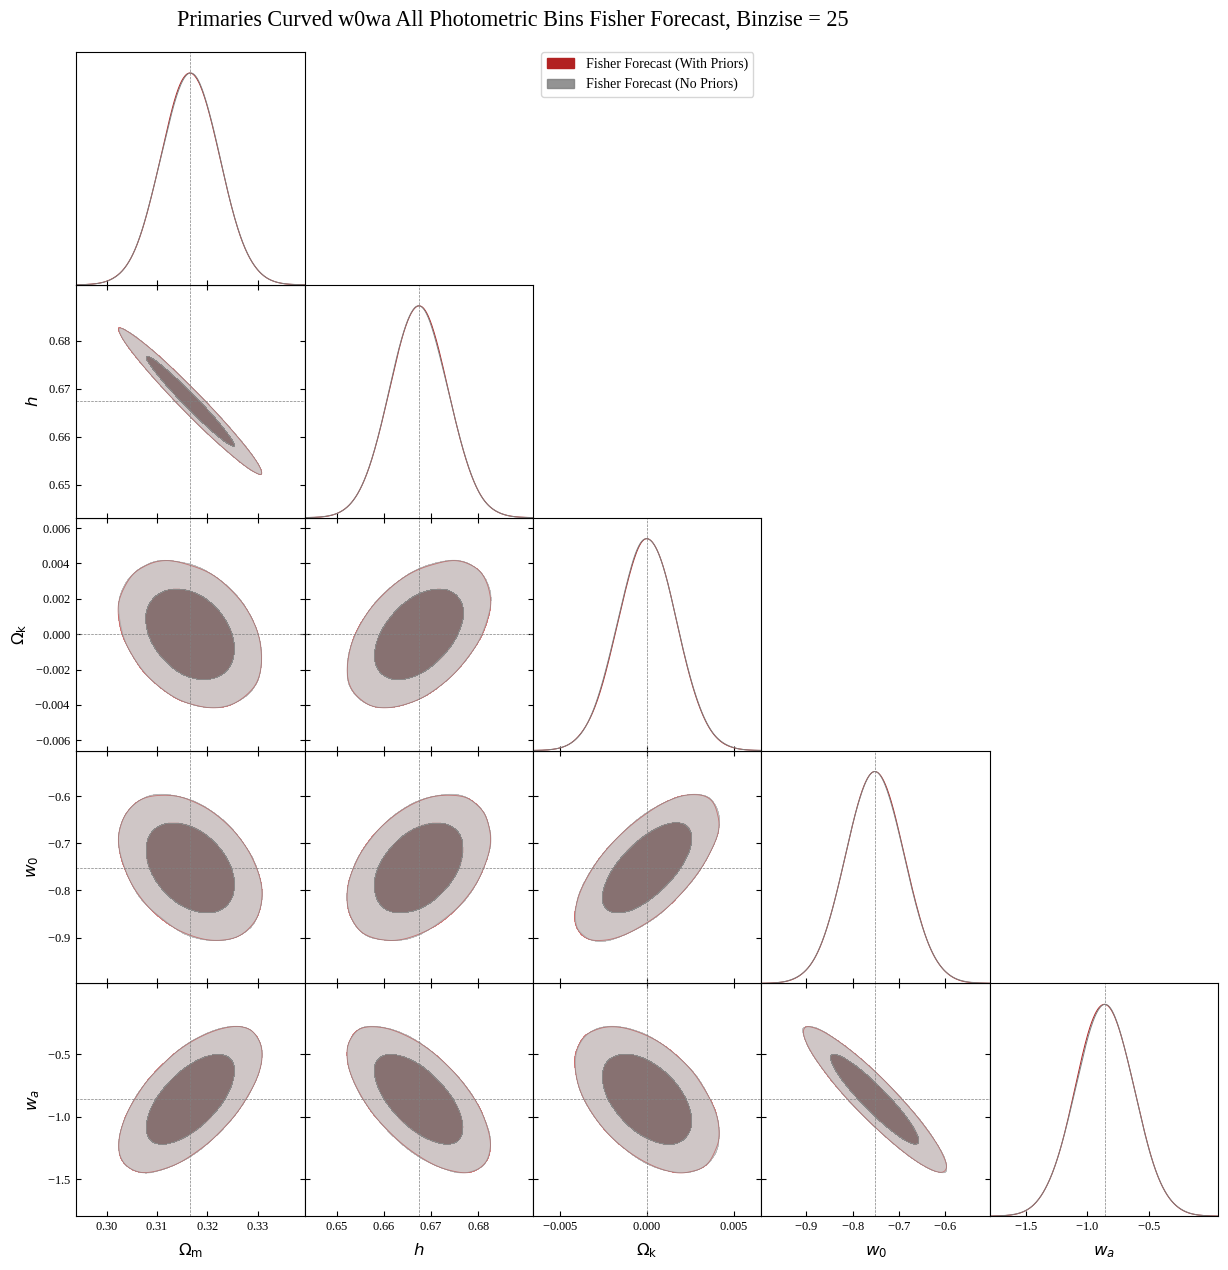

total_time:  0:03:39.601325


In [22]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=curved_w0waCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=25,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_cmb_noise_TT,
    cmb_noise_EE=SO_cmb_noise_EE,
    cmb_noise_TE=SO_cmb_noise_TE,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['TT', 'TE', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h', 'Omega_k', 'w0', 'wa']
params_to_plot = ['Omega_m', 'h', 'Omega_k', 'w0', 'wa']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Curved_w0waCDM_Primaries_All_Photometric_Bins_Binsize=25.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h Omega_k w0 wa',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, Omega_k, w0, wa\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Curved_w0waCDM_Primaries_All_Photometric_Bins_Binsize=25.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h Omega_k w0 wa',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, Omega_k, w0, wa\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Primaries Curved w0wa All Photometric Bins Fisher Forecast, Binzise = 25",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

#### Lensing Ratios and Primaries

Plot successfully saved to: plots/Fisher Forecasts/lensing_ratios_+_primaries_curved_w0wa_all_photometric_bins_fisher_forecast_binzise_=_100.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.3166\pm 0.0059$ | $\Omega_m = 0.317^{+0.011}_{-0.012}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3166\pm 0.0059$ | $\Omega_m = 0.317^{+0.012}_{-0.012}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6674\pm 0.0062$ | $h = 0.667^{+0.012}_{-0.012}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6674\pm 0.0062$ | $h = 0.667^{+0.012}_{-0.012}$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Fisher Forecast (With Priors) | $\Omega_k = 0.0000\pm 0.0018$ | $\Omega_k = 0.0000^{+0.0035}_{-0.0035}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.0000\pm 0.0018$ | $\Omega_k = 0.0000^{+0.0035}_{-0.0035}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.752\pm 0.064$ | $w_0 = -0.75^{+0.13}_{-0.13}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.752\pm 0.064$ | $w_0 = -0.75^{+0.13}_{-0.13}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.86\pm 0.23$ | $w_a = -0.86^{+0.46}_{-0.46}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.86\pm 0.23$ | $w_a = -0.86^{+0.46}_{-0.46}$ |
| --- | --- | --- | --- |

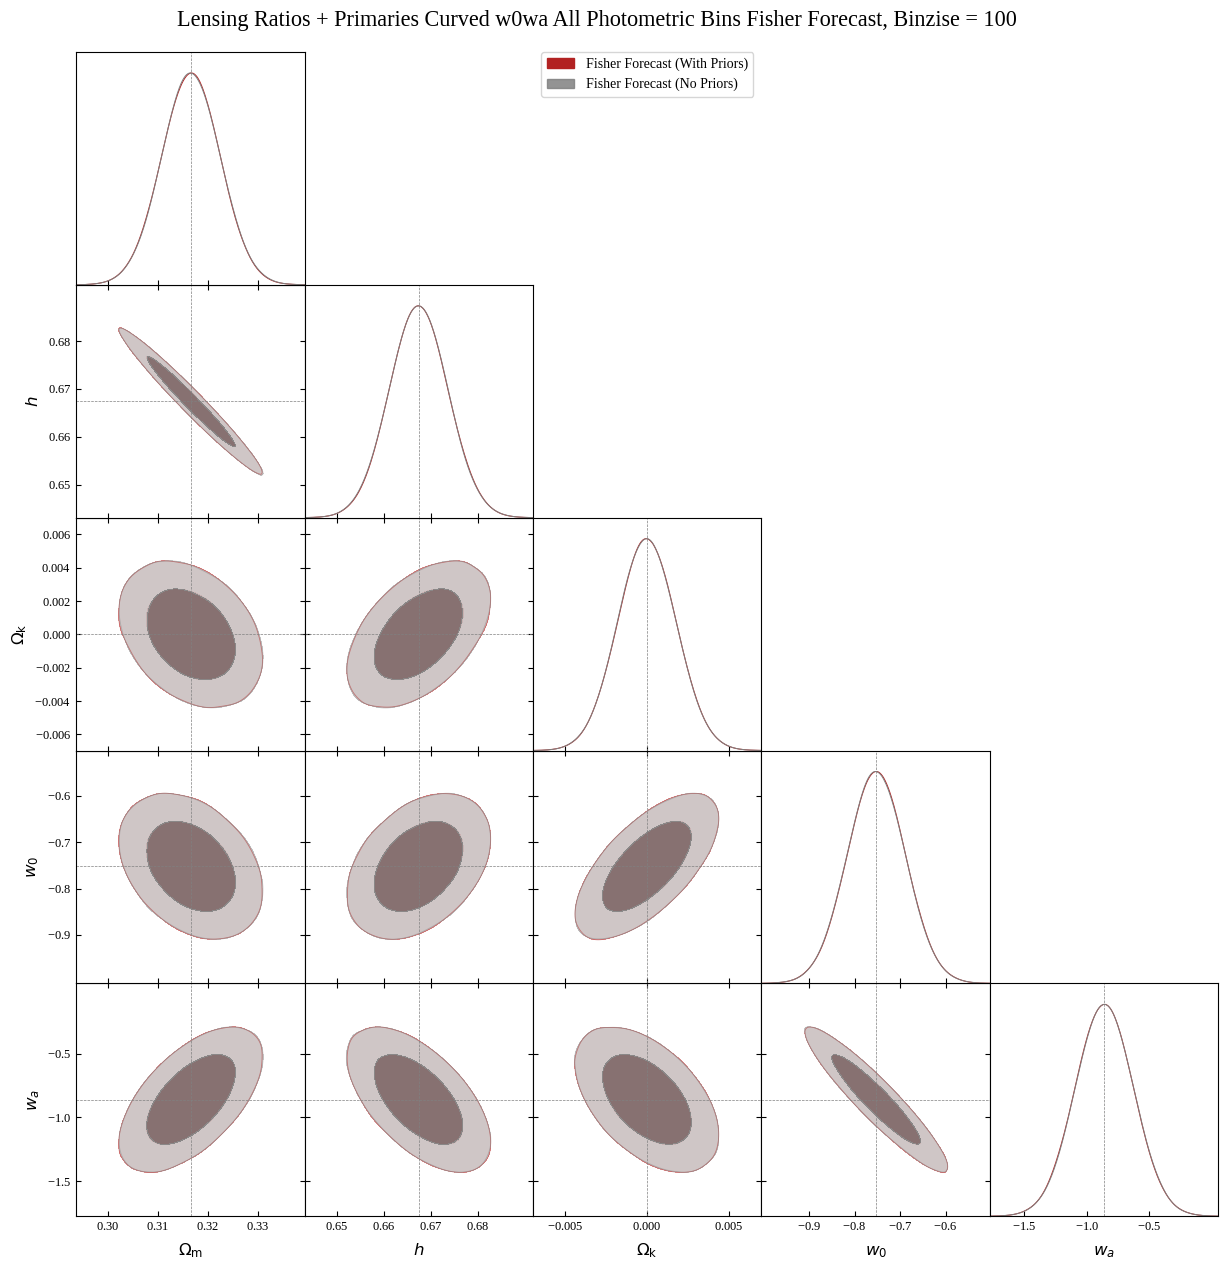

total_time:  0:02:05.876652


In [23]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=curved_w0waCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=100,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_cmb_noise_TT,
    cmb_noise_EE=SO_cmb_noise_EE,
    cmb_noise_TE=SO_cmb_noise_TE,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['CG', 'GL', 'TT', 'TE', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h', 'Omega_k', 'w0', 'wa']
params_to_plot = ['Omega_m', 'h', 'Omega_k', 'w0', 'wa']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Curved_w0waCDM_LRP_All_Photometric_Bins_Binsize=100.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h Omega_k w0 wa',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, Omega_k, w0, wa\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Curved_w0waCDM_LRP_All_Photometric_Bins_Binsize=100.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h Omega_k w0 wa',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, Omega_k, w0, wa\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Lensing Ratios + Primaries Curved w0wa All Photometric Bins Fisher Forecast, Binzise = 100",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Plot successfully saved to: plots/Fisher Forecasts/lensing_ratios_+_primaries_curved_w0wa_all_photometric_bins_fisher_forecast_binzise_=_50.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.3166\pm 0.0055$ | $\Omega_m = 0.317^{+0.011}_{-0.011}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3166\pm 0.0055$ | $\Omega_m = 0.317^{+0.011}_{-0.011}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6674\pm 0.0058$ | $h = 0.667^{+0.011}_{-0.011}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6674\pm 0.0058$ | $h = 0.667^{+0.011}_{-0.011}$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Fisher Forecast (With Priors) | $\Omega_k = 0.0000\pm 0.0017$ | $\Omega_k = 0.0000^{+0.0032}_{-0.0033}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.0000\pm 0.0017$ | $\Omega_k = 0.0000^{+0.0033}_{-0.0033}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.752\pm 0.060$ | $w_0 = -0.75^{+0.12}_{-0.12}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.752\pm 0.060$ | $w_0 = -0.75^{+0.12}_{-0.12}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.86\pm 0.22$ | $w_a = -0.86^{+0.43}_{-0.43}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.86\pm 0.22$ | $w_a = -0.86^{+0.43}_{-0.43}$ |
| --- | --- | --- | --- |

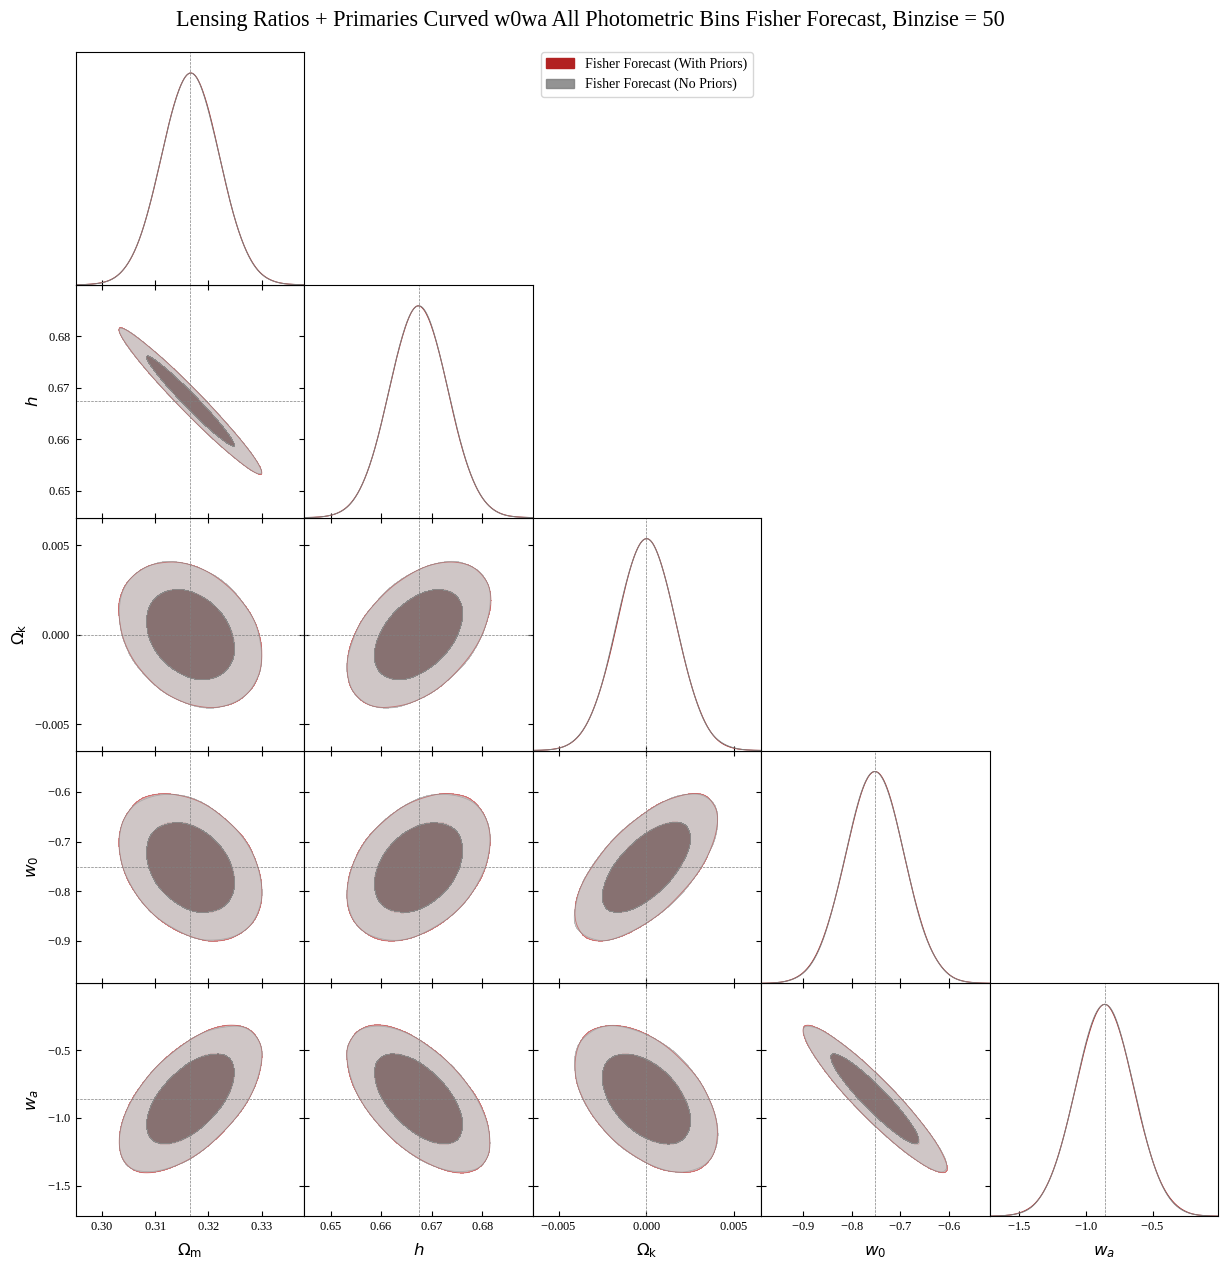

total_time:  0:02:43.344387


In [24]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=curved_w0waCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=50,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_cmb_noise_TT,
    cmb_noise_EE=SO_cmb_noise_EE,
    cmb_noise_TE=SO_cmb_noise_TE,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['CG', 'GL', 'TT', 'TE', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h', 'Omega_k', 'w0', 'wa']
params_to_plot = ['Omega_m', 'h', 'Omega_k', 'w0', 'wa']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Curved_w0waCDM_LRP_All_Photometric_Bins_Binsize=50.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h Omega_k w0 wa',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, Omega_k, w0, wa\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Curved_w0waCDM_LRP_All_Photometric_Bins_Binsize=50.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h Omega_k w0 wa',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, Omega_k, w0, wa\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Lensing Ratios + Primaries Curved w0wa All Photometric Bins Fisher Forecast, Binzise = 50",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Plot successfully saved to: plots/Fisher Forecasts/lensing_ratios_+_primaries_curved_w0wa_all_photometric_bins_fisher_forecast_binzise_=_25.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.3166\pm 0.0054$ | $\Omega_m = 0.317^{+0.010}_{-0.011}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3166\pm 0.0053$ | $\Omega_m = 0.317^{+0.010}_{-0.011}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6674\pm 0.0057$ | $h = 0.667^{+0.011}_{-0.011}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6674\pm 0.0057$ | $h = 0.667^{+0.011}_{-0.011}$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Fisher Forecast (With Priors) | $\Omega_k = 0.0000\pm 0.0016$ | $\Omega_k = 0.0000^{+0.0032}_{-0.0032}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.0000\pm 0.0016$ | $\Omega_k = 0.0000^{+0.0032}_{-0.0032}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.752\pm 0.058$ | $w_0 = -0.75^{+0.11}_{-0.11}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.752\pm 0.058$ | $w_0 = -0.75^{+0.11}_{-0.11}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.86\pm 0.21$ | $w_a = -0.86^{+0.42}_{-0.41}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.86\pm 0.21$ | $w_a = -0.86^{+0.41}_{-0.41}$ |
| --- | --- | --- | --- |

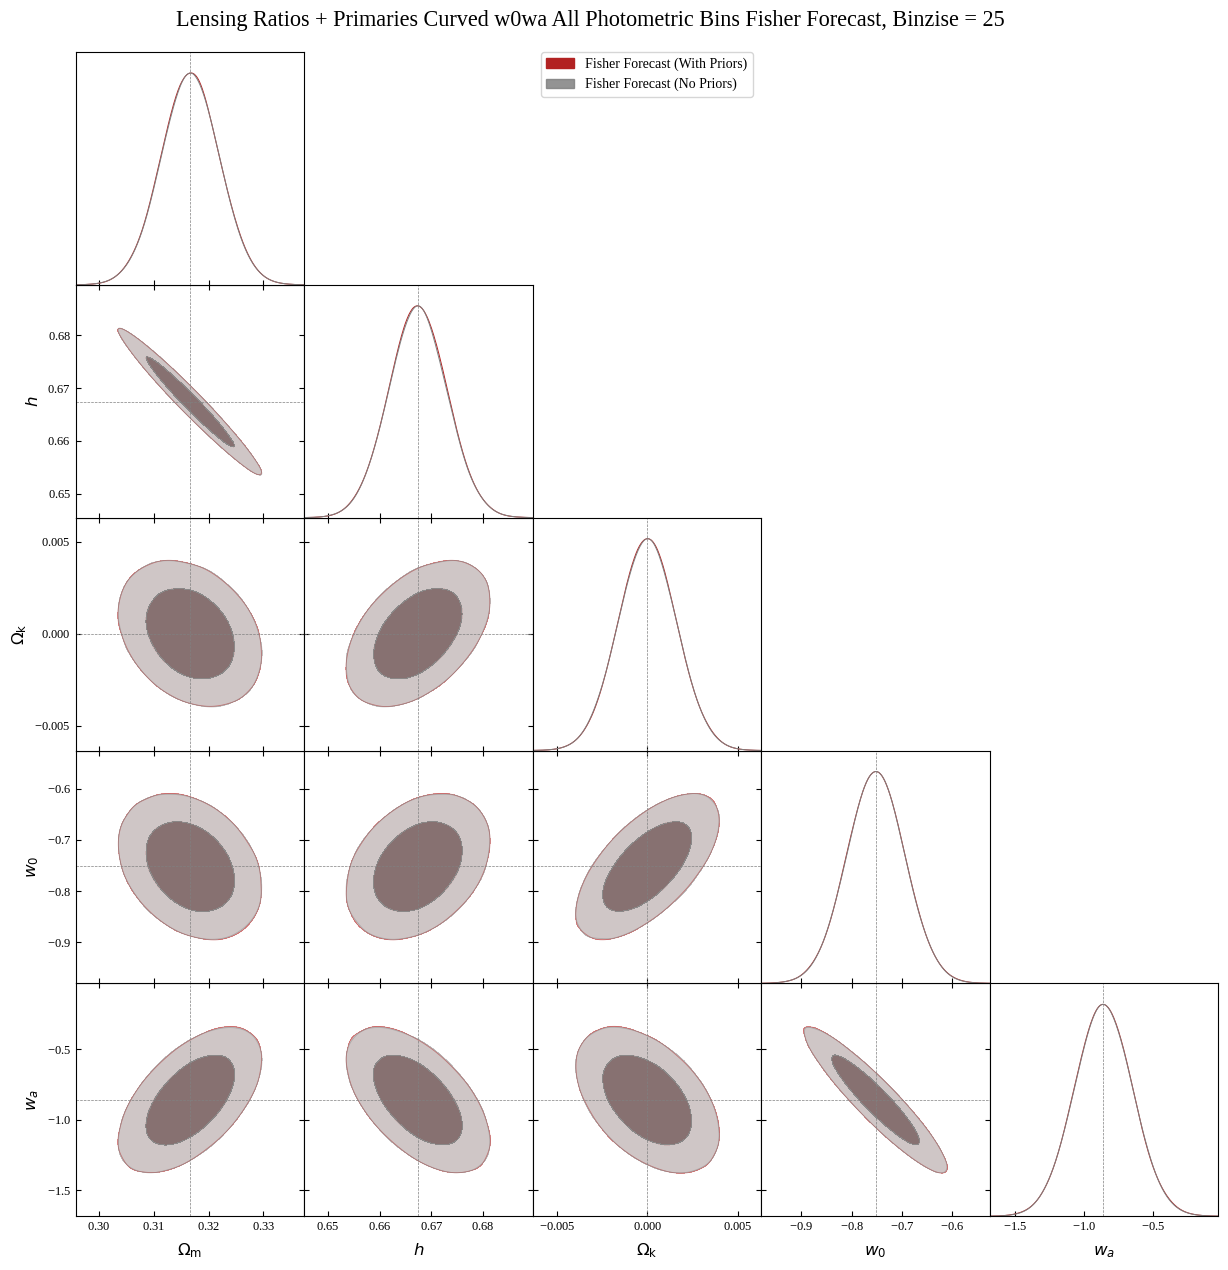

total_time:  0:04:35.403211


In [25]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=curved_w0waCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=25,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_cmb_noise_TT,
    cmb_noise_EE=SO_cmb_noise_EE,
    cmb_noise_TE=SO_cmb_noise_TE,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['CG', 'GL', 'TT', 'TE', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'm_nu', 'h', 'Omega_k', 'w0', 'wa']
params_to_plot = ['Omega_m', 'h', 'Omega_k', 'w0', 'wa']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Curved_w0waCDM_LRP_All_Photometric_Bins_Binsize=25.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b m_nu h Omega_k w0 wa',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, Omega_k, w0, wa\n'
)
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Curved_w0waCDM_LRP_All_Photometric_Bins_Binsize=25.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b m_nu h Omega_k w0 wa',
    comments='# Fiducial parameters: Omega_c, Omega_b, m_nu, h, Omega_k, w0, wa\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Lensing Ratios + Primaries Curved w0wa All Photometric Bins Fisher Forecast, Binzise = 25",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

## Emulator Tests

| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.82\pm 0.80$ | $w_a = -0.8^{+1.5}_{-1.6}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.86\pm 0.84$ | $w_a = -0.9^{+1.7}_{-1.6}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.76\pm 0.20$ | $w_0 = -0.76^{+0.39}_{-0.38}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.75\pm 0.21$ | $w_0 = -0.75^{+0.41}_{-0.42}$ |
| --- | --- | --- | --- |

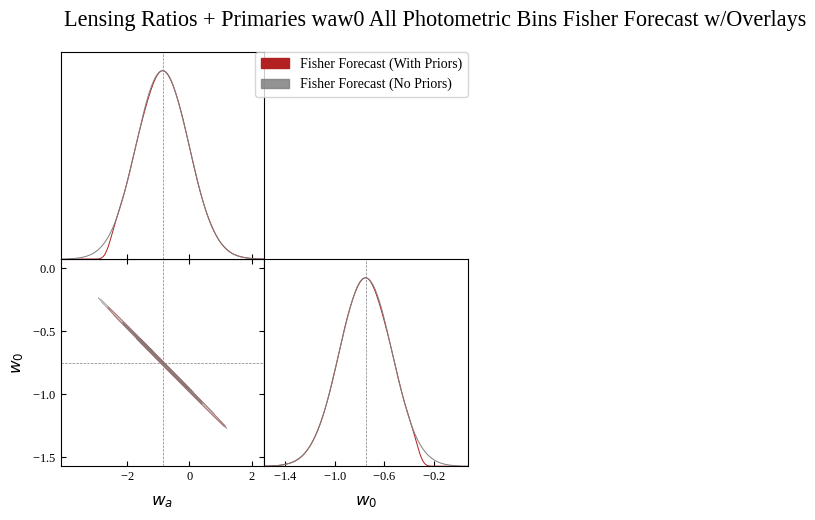

end time:  1784132413.720807
total_time:  0:00:56.375524


In [26]:
# Fisher for lensing ratios + primaries waw0 LCDM wa, w0

start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=w0waCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=50,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_cmb_noise_TT,
    cmb_noise_EE=SO_cmb_noise_EE,
    cmb_noise_TE=SO_cmb_noise_TE,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['CG', 'GL', 'TT', 'TE', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['wa', 'w0']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Lensing Ratios + Primaries waw0 All Photometric Bins Fisher Forecast w/Overlays",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_sample,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
print("end time: ", end_time)

total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.79^{+0.84}_{-0.98}$ | $w_a = -0.8^{+1.6}_{-1.7}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.86\pm 0.96$ | $w_a = -0.9^{+1.9}_{-1.9}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.77^{+0.25}_{-0.21}$ | $w_0 = -0.77^{+0.43}_{-0.41}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.75\pm 0.24$ | $w_0 = -0.75^{+0.47}_{-0.47}$ |
| --- | --- | --- | --- |

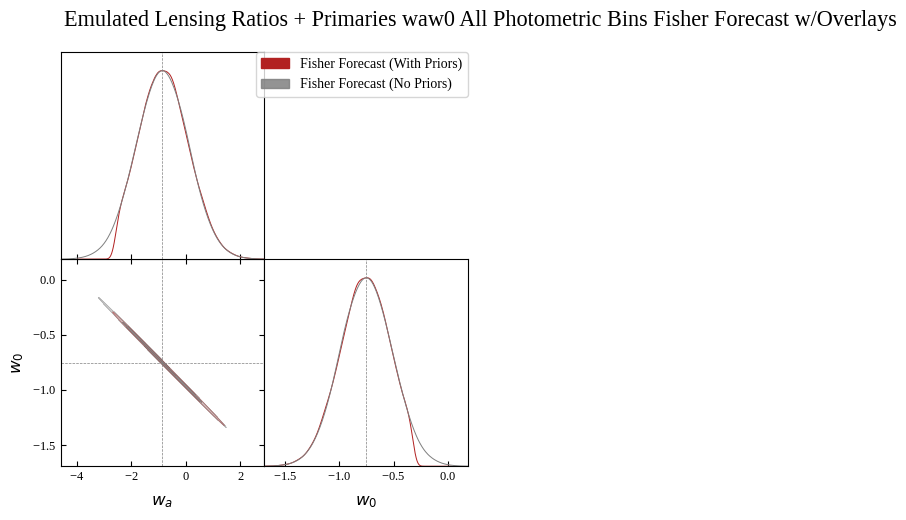

end time:  1784132467.9700272
total_time:  0:00:54.243637


In [27]:
# Fisher for lensing ratios + primaries waw0 LCDM wa, w0

start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=w0waCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    binsize=50,
    l_min =30,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = lin_emu,
    boost_emulator = boost_emu,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_cmb_noise_TT,
    cmb_noise_EE=SO_cmb_noise_EE,
    cmb_noise_TE=SO_cmb_noise_TE,
    shot_noise_lens=DESI_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['CG', 'GL', 'TT', 'TE', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['wa', 'w0']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="Emulated Lensing Ratios + Primaries waw0 All Photometric Bins Fisher Forecast w/Overlays",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_sample,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
print("end time: ", end_time)

total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

## Adding BAO

In [24]:
from desilike.observables.galaxy_clustering.compression import BAOCompressionObservable
observable = BAOCompressionObservable(provider='desidr2', sample='lrg')
likelihood = ObservablesGaussianLikelihood(observables=observable)
cosmo (BasePrimordialCosmology, default=None) – Cosmology calculator. Defaults to Cosmoprimo(fiducial=fiducial).

fiducial (str, tuple, dict, cosmoprimo.Cosmology, default=’DESI’) – Specifications for fiducial cosmology. Either:

str: name of fiducial cosmology in cosmoprimo.fiducial

tuple: (name of fiducial cosmology, dictionary of parameters to update)

dict: dictionary of parameters

cosmoprimo.Cosmology: Cosmology instance

# 2. Define your fiducial cosmological parameters
BAO_sample_params = {
    'omega_b': omega_b,
    'omega_cdm': omega_c,
    'm_nu': m_nu,
    'H0': H0,
}

# 3. Compute the Fisher Matrix directly using desilike's internal wrapper
fisher_calc = Fisher(likelihood)
DESI_BAO_Fisher = fisher_calc(b1=2.)
DESI_BAO_Fisher_Cov = fish.covariance()

# build in function to transform their Fisher matrix into Fisher matrix with my params
# bring back the projection functions and test
# add fisher matrices
# add covariance matrices
# make sure plotting function can take matrices so that if I've modified the matrix the plotting is accurate

PipelineError: Error in method initialize of <desilike.likelihoods.base.ObservablesGaussianLikelihood object at 0x7f18f43a2810>

# Cobaya MCMC

1.  **Parameters**: The cosmological parameters we want to constrain (e.g., $\Omega_m$, $\sigma_8$, $h$).
2.  **Likelihood**: A Python class that calculates the log-likelihood $L(\mathbf{D}|\mathbf{\theta})$, where $\mathbf{D}$ is the data vector and $\mathbf{\theta}$ are the cosmological parameters. For a Gaussian likelihood, this involves comparing a theoretical model (based on $\mathbf{\theta}$) to an observed data vector (which we'll treat as a fiducial model with noise) and using a covariance matrix.
3.  **Prior**: The prior distributions for our parameters.
4.  **Sampler**: The MCMC algorithm Cobaya will use to explore the parameter space.

### Likelihood

$$\ln L = -\frac{1}{2} (\mathbf{D} - \mathbf{M}(\mathbf{\theta}))^T \mathbf{C}^{-1} (\mathbf{D} - \mathbf{M}(\mathbf{\theta})) - \frac{1}{2} \ln |\mathbf{C}|$$

where:
*   $\mathbf{D}$ is the 'observed' data vector (derived from a fiducial cosmology with noise).
*   $\mathbf{M}(\mathbf{\theta})$ is the model prediction for the data vector, calculated using the given cosmological parameters $\mathbf{\theta}$.
*   $\mathbf{C}$ is the covariance matrix.

We already have the infrastructure to build the covariance matrix and calculate the theoretical $C_\ell$ values for a given cosmology. Now, we need to wrap this logic into a Cobaya-compatible likelihood class.

### Parameters and Sampler

**Parameters (params section):**

*   **prior**: The prior distribution for the parameter (e.g., min/max for a flat prior, loc/scale for a Gaussian).
*   **ref**: A reference value, often used by samplers to initiate chains or define a starting point.
*   **proposal**: The width of the proposal distribution for the sampler (how much the parameter changes in each step).
*   **latex**: A LaTeX representation for plotting and reporting.

**Sampler (sampler section):**

*   **Rminus1_stop**: A convergence criterion (Gelman-Rubin statistic minus 1). Smaller values indicate better convergence.
*   **max_samples**: The maximum number of samples to generate.

In [ ]:
# Cobaya in NERSC Configured Job
# 1 node, 4 tasks per node, 64 CPUs per task
# syntax example below

In [ ]:
cd $SCRATCH
module load python
conda activate cosmo311
cd ~/DESIxSO

rm -rf /pscratch/sd/l/lialubit/run_task_*

export COBAYA_USE_FILE_LOCKING=False
export OMP_NUM_THREADS=64
export OMP_PLACES=threads
export OMP_PROC_BIND=spread

time srun -n 4 -c 64 --cpu_bind=cores bash -c '
export PYTHONPATH="${HOME}/DESIxSO:${PYTHONPATH}"
TASK_YAML="run_config_${SLURM_PROCID}.yaml"
cp yaml/flat_LCDM_bin1_LRP_omega_c_omega_b_likelihood.yaml $TASK_YAML
MY_SEED=$((1234 + SLURM_PROCID))
sed -i "s/seed:.*/seed: ${MY_SEED}/g" $TASK_YAML
$(which cobaya-run) $TASK_YAML -o /pscratch/sd/l/lialubit/run_task_${SLURM_PROCID}/chain
rm -f $TASK_YAML
'

In [ ]:
CHAIN_DEST="chains/flat_LCDM_bin1_LRP_omega_c_omega_b_likelihood_INCOMPLETE2"
mkdir -p $CHAIN_DEST

for i in {0..3}; do
    cp /pscratch/sd/l/lialubit/run_task_${i}/chain.1.txt $CHAIN_DEST/chain_task_${i}.txt
    ln -sf chain_task_${i}.txt $CHAIN_DEST/cosmo_run.${i}.txt
done

# Copy the paramnames file so your plotting code works immediately
cp /pscratch/sd/l/lialubit/run_task_0/chain.paramnames $CHAIN_DEST/chain_task.paramnames
cp /pscratch/sd/l/lialubit/run_task_0/chain.paramnames $CHAIN_DEST/cosmo_run.paramnames

### LCDM

Reading fiducial values from: /global/homes/l/lialubit/DESIxSO/yaml/flat_LCDM_bin1_LRP_omega_c_omega_b_likelihood.yaml
Processing 4 chains from: /global/homes/l/lialubit/DESIxSO/chains/flat_LCDM_bin1_LRP_omega_c_omega_b_likelihood_INCOMPLETE2


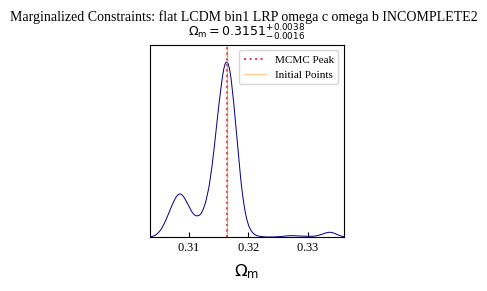

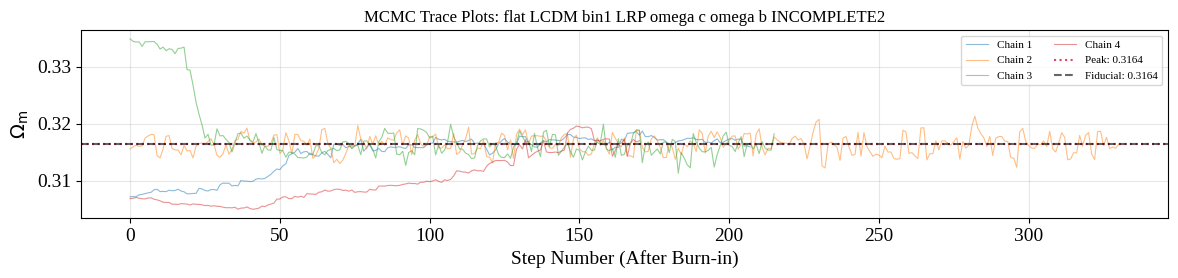

| Parameter | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :---: | :---: |
| **$\Omega_\mathrm{m}$** | $\Omega_\mathrm{m} = 0.3151^{+0.0038}_{-0.0016}$ | $\Omega_\mathrm{m} = 0.3151^{+0.0047}_{-0.0090}$ |
| --- | --- | --- |



Reading fiducial values from: /global/homes/l/lialubit/DESIxSO/yaml/flat_LCDM_bin1_LRP_omega_c_omega_b_likelihood.yaml
Processing 4 chains from: /global/homes/l/lialubit/DESIxSO/chains/flat_LCDM_bin1_LRP_omega_c_omega_b_likelihood_INCOMPLETE2


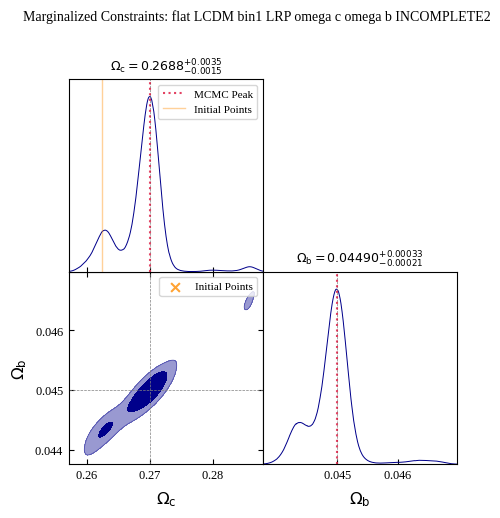

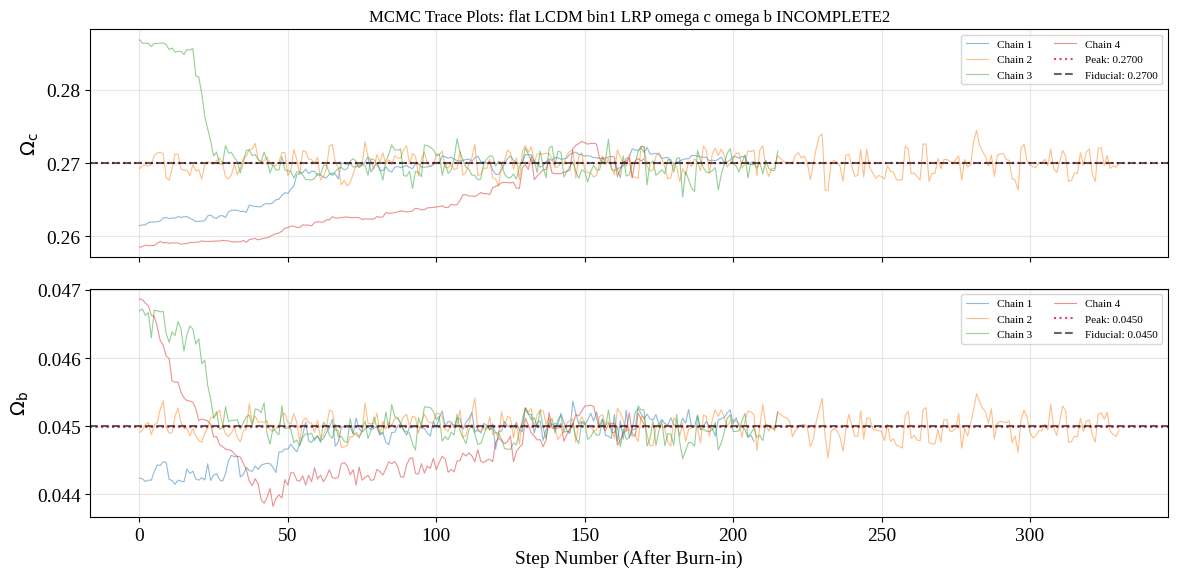

| Parameter | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :---: | :---: |
| **$\Omega_\mathrm{c}$** | $\Omega_\mathrm{c} = 0.2688^{+0.0035}_{-0.0015}$ | $\Omega_\mathrm{c} = 0.2688^{+0.0045}_{-0.0085}$ |
| --- | --- | --- |
| **$\Omega_\mathrm{b}$** | $\Omega_\mathrm{b} = 0.04490^{+0.00033}_{-0.00021}$ | $\Omega_\mathrm{b} = 0.04490^{+0.00050}_{-0.00084}$ |
| --- | --- | --- |

In [14]:
# plot results for flat_LCDM_bin1_LRP_omega_b_omega_c_likelihood -- first test of new derived paramter strategy

# Define your environment paths
chain_folder = os.path.expanduser('~/DESIxSO/chains/flat_LCDM_bin1_LRP_omega_c_omega_b_likelihood_INCOMPLETE2')
yaml_file_path = '/global/homes/l/lialubit/DESIxSO/yaml/flat_LCDM_bin1_LRP_omega_c_omega_b_likelihood.yaml'
params_to_sample = ['Omega_c', 'Omega_b']
params_to_plot = ['Omega_m']

# Call the clean-name variant of the function
plot_cobaya_mcmc_results(
    chain_dir=chain_folder,
    yaml_path=yaml_file_path,
    sampled_params=params_to_sample,
    plot_params=params_to_plot,
    num_chains=4,
    burn_in_fraction=0.4,
    plot_triangle=True,
    plot_traces=True,
    save_triangle=False,
    save_traces=False,
    print_summary=True,
)

plot_cobaya_mcmc_results(
    chain_dir=chain_folder,
    yaml_path=yaml_file_path,
    sampled_params=params_to_sample,
    plot_params=params_to_sample,
    num_chains=4,
    burn_in_fraction=0.4,
    plot_triangle=True,
    plot_traces=True,
    save_triangle=False,
    save_traces=False,
    print_summary=True,
    output_dir='plots/MCMC_runs/traces_and_dists'
)

In [ ]:
## THESE ARE ALL PRE PRIMARIES AND PRE DERIVED-PARAMETER CHANGE

Results for omega_m emulated flat LCDM bin1 MCMC:
Runtime: 16 min 30 sec

Reading fiducial values from: /global/homes/l/lialubit/DESIxSO/yaml/emulated_flat_LCDM_bin1_omega_m_likelihood.yaml
Derived fiducial Omega_m = Omega_c + Omega_b = 0.3150
Processing 4 chains from: /global/homes/l/lialubit/DESIxSO/chains/emulated_flat_LCDM_bin1_omega_m_likelihood
Saved triangle plot to: plots/MCMC_runs/traces_and_dists/emulated_flat_LCDM_bin1_omega_m_triangle_plot.pdf


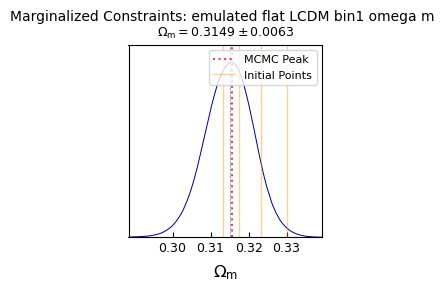

Saved trace plot to: plots/MCMC_runs/traces_and_dists/emulated_flat_LCDM_bin1_omega_m_traces.png


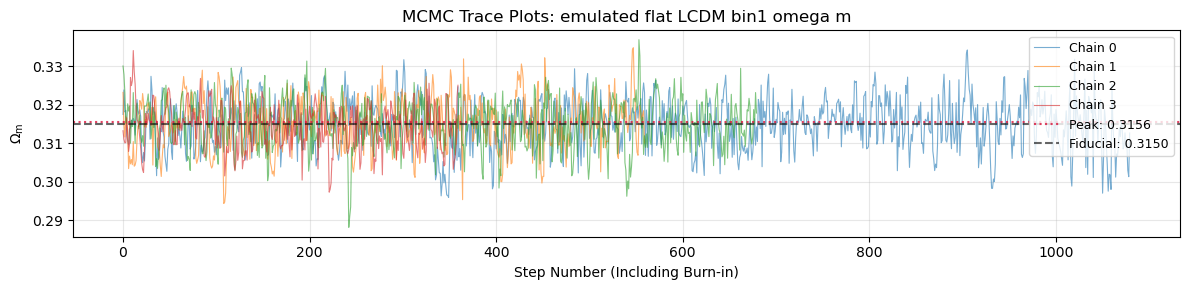

In [5]:
# plot results for emulated_flat_LCDM_bin1_omega_m_likelihood

print("Results for omega_m emulated flat LCDM bin1 MCMC:")
print("Runtime: 16 min 30 sec")
print("")

# Define your environment paths
chain_folder = os.path.expanduser('~/DESIxSO/chains/emulated_flat_LCDM_bin1_omega_m_likelihood')
yaml_file_path = '/global/homes/l/lialubit/DESIxSO/yaml/emulated_flat_LCDM_bin1_omega_m_likelihood.yaml'
params_list = ['Omega_m']

# Call the clean-name variant of the function
plot_cobaya_mcmc_results(
    chain_dir=chain_folder,
    yaml_path=yaml_file_path,
    sampled_params=params_list,
    num_chains=4,
    burn_in_fraction=0.2,
    output_dir='plots/MCMC_runs/traces_and_dists'
)

### DESI DRII

Loading DESI + CMB...
Loading DESI + CMB + DESY5...
Loading DESI + CMB + Pantheon+...
Loading DESI + CMB + Union3...


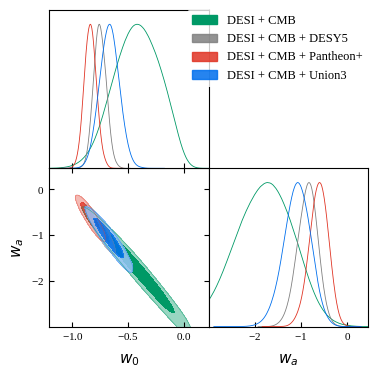

In [17]:
# plot DESI DRII contours

# The absolute NERSC path where the DESI chains live
DESI_DIR = "/global/cfs/cdirs/desi/public/papers/y3/bao-cosmo-params/cobaya/base_w_wa"

# Mapping the exact folder names from NERSC to readable legend labels
datasets = {
    "DESI + cmb": "desi-bao-all_planck2018-lowl-TT-clik_planck2018-lowl-EE-clik_planck-NPIPE-highl-CamSpec-TTTEEE_planck-act-dr6-lensing",
    "DESI + cmb + DESY5": "desi-bao-all_desy5sn_planck2018-lowl-TT-clik_planck2018-lowl-EE-clik_planck-NPIPE-highl-CamSpec-TTTEEE_planck-act-dr6-lensing",
    "DESI + cmb + Pantheon+": "desi-bao-all_pantheonplus_planck2018-lowl-TT-clik_planck2018-lowl-EE-clik_planck-NPIPE-highl-CamSpec-TTTEEE_planck-act-dr6-lensing",
    "DESI + cmb + Union3": "desi-bao-all_union3_planck2018-lowl-TT-clik_planck2018-lowl-EE-clik_planck-NPIPE-highl-CamSpec-TTTEEE_planck-act-dr6-lensing"
}

# Load the samples straight from CFS
samples = {}
for label, folder_name in datasets.items():
    # 'chain' is the root prefix for chain.1.txt, chain.2.txt, etc.
    chain_root = os.path.join(DESI_DIR, folder_name, "chain")

    print(f"Loading {label}...")
    samples[label] = loadMCSamples(chain_root, settings={'ignore_rows': 0.3})

# Initialize the plotter for a beautiful inline Jupyter notebook display
g = plots.get_subplot_plotter()

# Customize plot settings to mimic official papers
g.settings.num_plot_contours = 2  # 68% and 95% intervals
g.settings.figure_legend_frame = False

# Plot the 2D contour overlay for dark energy parameters w and wa
g.triangle_plot(
    list(samples.values()),
    params=['w', 'wa'],
    legend_labels=list(samples.keys()),
    filled=True
)

### Chi2 Cobaya

In [16]:
## plot chi2 for emulated abridge likelihood
# lol what happened here 

# 1. Initialize the model and likelihood object
info = "yaml/flat_LCDM_bin1_LRP_omega_c_omega_b_likelihood.yaml"
model = get_model(info)
likelihood_object = model.likelihood["functions_and_classes.SO_x_DESI_Likelihood"]

# 2. Define grids for BOTH parameters
omega_b_grid = np.linspace(0.04, 0.05, 20)
omega_c_grid = np.linspace(0.25, 0.29, 20)

# Create empty matrix to hold chi2 values
chi2_matrix = np.zeros((len(omega_b_grid), len(omega_c_grid)))

# Create a counter
step = 0
total_steps = len(omega_b_grid) * len(omega_c_grid)

print("Starting 2D grid scan...")
for i, ob in enumerate(omega_b_grid):
    for j, oc in enumerate(omega_c_grid):
        step += 1
        if step % 50 == 0:  # Prints an update every 50 points
            print(f"Evaluating step {step}/{total_steps}...")

        chi2 = likelihood_object.profile_chi2(
            Omega_c=oc,
            Omega_b=ob,
            h=0.674,
            A_s=2.105e-9,
            n_s=0.96,
            w0=-1.0,
            wa=0.0,
            Omega_k=0.0,
            Neff=3.044,
            m_nu=0.06,
            T_CMB=2.7255
        )
        chi2_matrix[i, j] = chi2

[model] *WARNING* Ignored blocks/options: ['sampler', 'output']
Initializing SO_x_DESI_Likelihood...
Not using emulator.
Spectra considered:  ['CG', 'GL', 'EE', 'TT', 'TE']
  Loading lens shot noise from: data/DESI_shot_noise_bin1.npy
  Loading source shape noise from: data/DESI_shape_noise_bin1.npy
  Loading CMB noise from: data/SO_cmb_noise_kk.npy
  Loading CMB noise from: data/SO_cmb_noise_TT.npy
  Loading CMB noise from: data/SO_cmb_noise_EE.npy
  Loading CMB noise from: data/SO_cmb_noise_TE.npy
  Loaded lens data from data/DESI_lens_data_bin1.npy
  Loaded source data from: data/HSC_dist_0_3_bin1.npy
  Loading observed data vector from: cobaya_data/flat_LCDM_bin1_LRP_data_vector.npy
  Loading covariance matrix from: cobaya_data/flat_LCDM_bin1_LRP_covariance_matrix.npy
SO_x_DESI_Likelihood initialized successfully.
Starting 2D grid scan...
Evaluating step 50/400...
Evaluating step 100/400...
Evaluating step 150/400...
Evaluating step 200/400...
Evaluating step 250/400...
Evaluating 

[0.04       0.04052632 0.04105263 0.04157895 0.04210526 0.04263158
 0.04315789 0.04368421 0.04421053 0.04473684 0.04526316 0.04578947
 0.04631579 0.04684211 0.04736842 0.04789474 0.04842105 0.04894737
 0.04947368 0.05      ]
[0.25       0.25210526 0.25421053 0.25631579 0.25842105 0.26052632
 0.26263158 0.26473684 0.26684211 0.26894737 0.27105263 0.27315789
 0.27526316 0.27736842 0.27947368 0.28157895 0.28368421 0.28578947
 0.28789474 0.29      ]
[[1.51370678e+03 1.63366514e+03 1.76805871e+03 1.91570604e+03
  2.07620482e+03 2.24885808e+03 2.43264541e+03 2.62710765e+03
  2.83169402e+03 3.04521465e+03 3.26730457e+03 3.49755242e+03
  3.73469593e+03 3.97805227e+03 4.22812530e+03 4.48311244e+03
  4.74287796e+03 5.00680811e+03 5.27488722e+03 5.54561548e+03]
 [1.09608471e+03 1.18901902e+03 1.29655605e+03 1.41833886e+03
  1.55332976e+03 1.70093958e+03 1.86073844e+03 2.03157154e+03
  2.21297864e+03 2.40450069e+03 2.60498639e+03 2.81402257e+03
  3.03068539e+03 3.25517611e+03 3.48596802e+03 3.7227

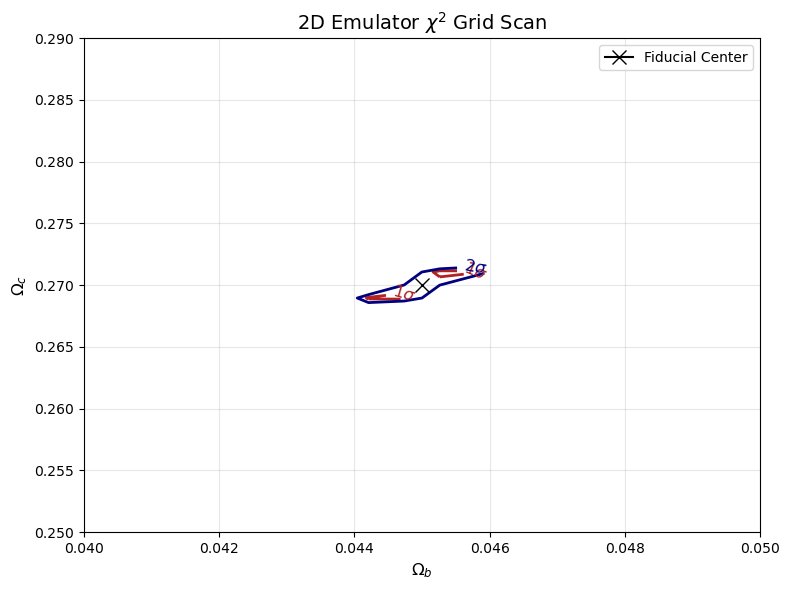

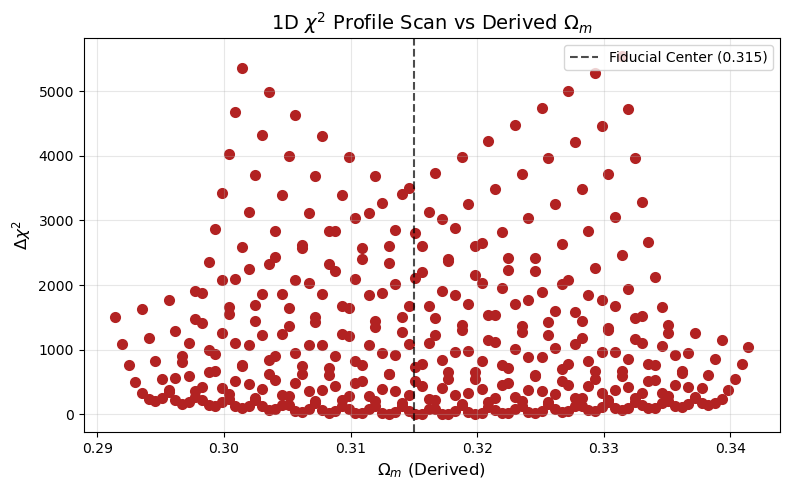

In [17]:
# PLOT -- SOMETHINGS GOING WRONG HERE
print(omega_b_grid)
print(omega_c_grid)
print(chi2_matrix)
# plot omega_b vs omega_c
min_chi2 = np.min(chi2_matrix)
delta_chi2 = chi2_matrix - min_chi2 
plt.figure(figsize=(8, 6))
contour = plt.contour(omega_b_grid, omega_c_grid, delta_chi2, levels=[2.30, 6.18], colors=['firebrick', 'navy'], linewidths=2)
plt.clabel(contour, inline=True, fmt={2.30: r'$1\sigma$', 6.18: r'$2\sigma$'}, fontsize=12)

# Mark the fiducial center
plt.plot(0.045, 0.27, marker='x', color='black', markersize=10, label='Fiducial Center')

plt.xlabel(r"$\Omega_b$", fontsize=12)
plt.ylabel(r"$\Omega_c$", fontsize=12)
plt.title(r"2D Emulator $\chi^2$ Grid Scan", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# plot omega_m -- omega_m = omega_b + omega_c + (m_nu / (h**2 * 93.15))
h = 0.674
m_nu = 0.06
omega_nu = m_nu / ((h**2) * 93.15)

omega_m_grid = []
omega_m_chi2 = []
for i in range(len(omega_b_grid)):
    for j in range(len(omega_c_grid)):
        omega_m_grid.append(omega_b_grid[i] + omega_c_grid[j] + omega_nu)
        omega_m_chi2.append(delta_chi2[i][j])
                            
plt.figure(figsize=(8, 5))
plt.scatter(omega_m_grid, omega_m_chi2, marker='o', color='firebrick', lw=2)

# Reference Lines
plt.axvline(0.315, color='black', linestyle='--', alpha=0.7, label='Fiducial Center (0.315)')
plt.xlabel(r"$\Omega_m$ (Derived)", fontsize=12)
plt.ylabel(r"$\Delta \chi^2$", fontsize=12)
plt.title(r"1D $\chi^2$ Profile Scan vs Derived $\Omega_m$", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

point: 0
chi2: 11.90433639126255
omega_b: 0.045526315789473686 | omega_c: 0.2752631578947368
Sum: 0.3207894736842105
--------------------
point: 1
chi2: 16.855309473119465
omega_b: 0.045526315789473686 | omega_c: 0.27157894736842103
Sum: 0.3171052631578947
--------------------
point: 2
chi2: 22.1717050452298
omega_b: 0.04421052631578948 | omega_c: 0.26421052631578945
Sum: 0.30842105263157893
--------------------
point: 3
chi2: 42.49370534050919
omega_b: 0.04421052631578948 | omega_c: 0.26789473684210524
Sum: 0.3121052631578947
--------------------
point: 4
chi2: 45.16745623533943
omega_b: 0.045526315789473686 | omega_c: 0.2789473684210526
Sum: 0.3244736842105263
--------------------
point: 5
chi2: 45.61469517909372
omega_b: 0.04421052631578948 | omega_c: 0.26052631578947366
Sum: 0.30473684210526314
--------------------
point: 6
chi2: 62.74303574857455
omega_b: 0.045526315789473686 | omega_c: 0.26789473684210524
Sum: 0.31342105263157893
--------------------
point: 7
chi2: 103.6544305538

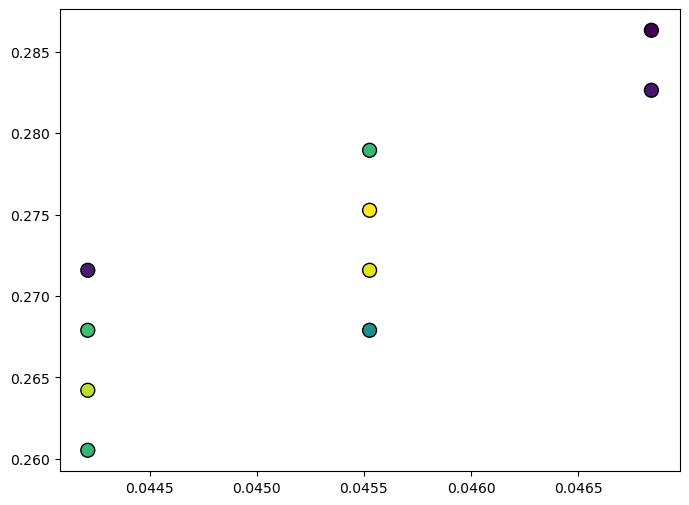

In [30]:
# 1. Get the flattened indices of the 10 lowest values
flat_indices = np.argpartition(chi2_matrix.ravel(), 10)[:10]

# 2. Sort those 10 indices so they go from smallest chi2 to largest
flat_indices = flat_indices[np.argsort(chi2_matrix.ravel()[flat_indices])]

# 3. Convert flat indices to 2D row and column grid indices
rows, cols = np.unravel_index(flat_indices, chi2_matrix.shape)

# 4. Loop and print the values and corresponding grid positions
for i in range(10):
    r = rows[i]
    c = cols[i]
    chi2_val = chi2_matrix[r, c]
    
    print(f"point: {i}")
    print(f"chi2: {chi2_val}")
    print(f"omega_b: {omega_b_grid[r]} | omega_c: {omega_c_grid[c]}")
    print(f"Sum: {omega_b_grid[r] + omega_c_grid[c]}")
    print("-" * 20)

best_omega_b = omega_b_grid[rows]
best_omega_c = omega_c_grid[cols]
best_chi2 = chi2_matrix[rows, cols]

# 2. Create the plot
plt.figure(figsize=(8, 6))

# Plot the 10 points (colored by their chi2 value)
print("points with darker colors have lower chi2")
scatter = plt.scatter(
    best_omega_b, 
    best_omega_c, 
    c=best_chi2, 
    cmap='viridis_r',  # '_r' reverses it so lower chi2 stands out
    s=100,             # Marker size
    edgecolor='black', 
    zorder=3
)

# something is going very wrong in the plotting, and the contour does not match these nice minimum values
# the chi2 seems to have worked alright

In [ ]:
# the following chi2 values use the pre-reordering functions and n_ell = 3000
# they should be accurate still, just a touch out-dated

[model] *WARNING* Ignored blocks/options: ['sampler', 'output']
Initializing SO_x_DESI_Likelihood...
Not using emulator.
Spectra considered:  ['GG', 'LL', 'GL', 'CC', 'CL', 'CG', 'TT', 'EE', 'ET', 'GT', 'LT', 'CT', 'EG', 'EL', 'CE']
  Loading lens shot noise from: data/DESI_shot_noise_bin1.npy
  Loading source shape noise from: data/DESI_shape_noise_bin1.npy
  Loading CMB noise from: data/SO_CMB_noise_kk.npy
  Loading CMB noise from: data/SO_CMB_noise_TT.npy
  Loading CMB noise from: data/SO_CMB_noise_EE.npy
  Loading CMB noise from: data/SO_CMB_noise_TE.npy
  Loaded lens data from data/DESI_lens_data_bin1.npy
  Loaded source data from: data/HSC_dist_0_3_bin1.npy
  Loading observed data vector from: cobaya_data/emulated_full_spectrum_and_primaries_flat_LCDM_bin1_data_vector.npy
  Loading covariance matrix from: cobaya_data/emulated_full_spectrum_and_primaries_flat_LCDM_bin1_covariance_matrix.npy
SO_x_DESI_Likelihood initialized successfully.
Starting grid scan...


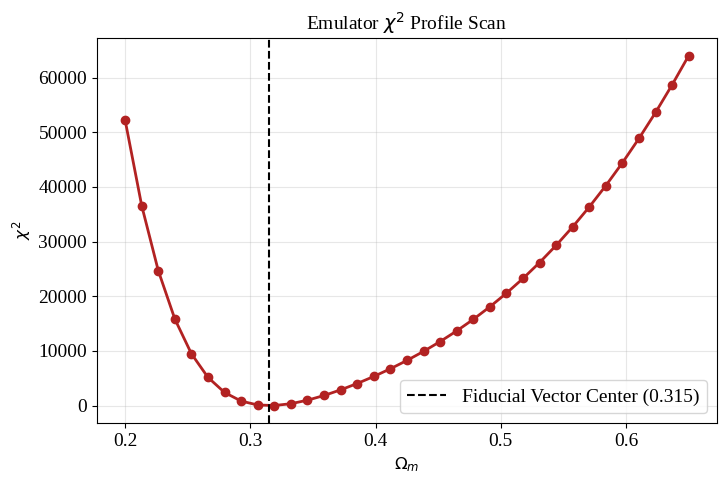

In [17]:
# get chi2 values for omega_m using full spectra + primaries w/emulated likelihood

info = "yaml/emulated_full_spectrum_and_primaries_flat_LCDM_bin1_omega_m_likelihood.yaml"
model = get_model(info)
likelihood_object = model.likelihood["functions_and_classes.SO_x_DESI_Likelihood"]

# define omega_m grid
omega_m_grid = np.linspace(0.20, 0.65, 35)
chi2_values = []

# 4. Loop through the grid and evaluate the chi2
print("Starting grid scan...")
for om in omega_m_grid:
    # pass the target parameter along with your fiducial values
    # profile_chi2 function will automatically compute Omega_c = Omega_m - Omega_b inside
    chi2 = likelihood_object.profile_chi2(
        Omega_m=om,
        Omega_b=0.045,
        h=0.674,
        A_s=2.105e-9,
        n_s=0.96,
        w0=-1.0,
        wa=0.0,
        Omega_k=0.0
    )
    chi2_values.append(chi2)

# plot
plt.figure(figsize=(8, 5))
plt.plot(omega_m_grid, chi2_values, marker='o', color='firebrick', lw=2)
plt.axvline(0.315, color='black', linestyle='--', label='Fiducial Vector Center (0.315)')
plt.xlabel(r"$\Omega_m$", fontsize=12)
plt.ylabel(r"$\chi^2$", fontsize=12)
plt.title(r"Emulator $\chi^2$ Profile Scan", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

[model] *WARNING* Ignored blocks/options: ['sampler', 'output']
Initializing SO_x_DESI_Likelihood...
  Loading lens shot noise from: data/DESI_shot_noise_bin1.npy
  Loading source shape noise from: data/DESI_shape_noise_bin1.npy
  Loading CMB noise from: data/SO_CMB_noise.npy
  Loaded lens data from data/DESI_lens_data_bin1.npy
  Loaded source data from: data/HSC_dist_0_3_bin1.npy
  Loading observed data vector from: cobaya_data/emulated_lensing_ratios_flat_LCDM_bin1_data_vector.npy
  Loading covariance matrix from: cobaya_data/emulated_lensing_ratios_flat_LCDM_bin1_covariance_matrix.npy
SO_x_DESI_Likelihood initialized successfully.
Starting 2D grid scan...
Evaluating step 20/400...
Evaluating step 40/400...
Evaluating step 60/400...
Evaluating step 80/400...
Evaluating step 100/400...
Evaluating step 120/400...
Evaluating step 140/400...
Evaluating step 160/400...
Evaluating step 180/400...
Evaluating step 200/400...
Evaluating step 220/400...
Evaluating step 240/400...
Evaluating st

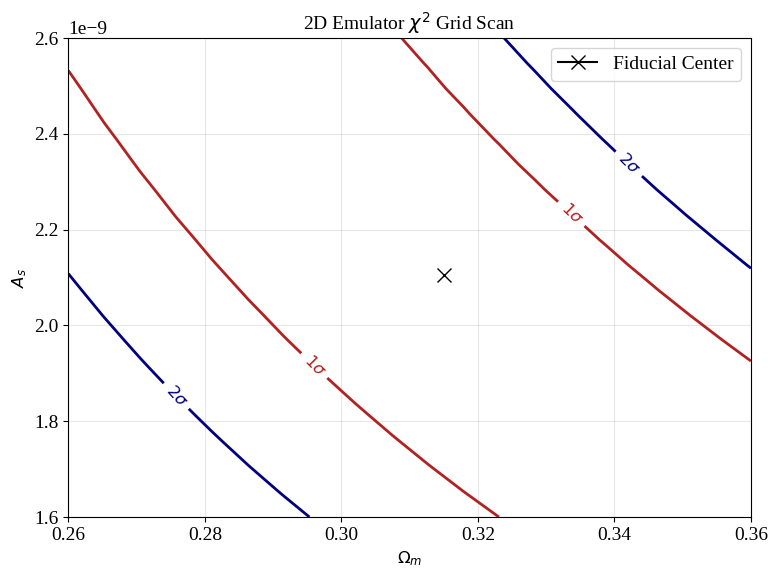

In [ ]:
# plot chi2 for emulated abridge likelihood

# 1. Initialize the model and likelihood object
info = "yaml/emulated_lensing_ratios_flat_LCDM_bin1_omega_m_A_s_likelihood.yaml"
model = get_model(info)
likelihood_object = model.likelihood["functions_and_classes.SO_x_DESI_Likelihood_w_emulator"]

# 2. Define grids for BOTH parameters
omega_m_grid = np.linspace(0.26, 0.36, 20)
A_s_grid = np.linspace(1.6e-9, 2.6e-9, 20)

# Create empty matrix to hold chi2 values
chi2_matrix = np.zeros((len(A_s_grid), len(omega_m_grid)))

# Create a counter
step = 0
total_steps = len(A_s_grid) * len(omega_m_grid)

print("Starting 2D grid scan...")
for i, as_val in enumerate(A_s_grid):
    for j, om in enumerate(omega_m_grid):
        step += 1
        if step % 20 == 0:  # Prints an update every 20 points
            print(f"Evaluating step {step}/{total_steps}...")

        chi2 = likelihood_object.profile_chi2(
            Omega_m=om,
            Omega_b=0.045,
            h=0.674,
            A_s=as_val,
            n_s=0.96,
            w0=-1.0,
            wa=0.0,
            Omega_k=0.0
        )
        chi2_matrix[i, j] = chi2

# 4. Process the Chi2 surface for plotting
min_chi2 = np.min(chi2_matrix)
delta_chi2 = chi2_matrix - min_chi2  # Delta Chi2 relative to best-fit

# 5. Plot the 2D confidence contours
plt.figure(figsize=(8, 6))

# Standard 2D Gaussian confidence intervals: 1-sigma (Delta Chi2 = 2.30), 2-sigma (Delta Chi2 = 6.18)
contour = plt.contour(omega_m_grid, A_s_grid, delta_chi2, levels=[2.30, 6.18], colors=['firebrick', 'navy'], linewidths=2)
plt.clabel(contour, inline=True, fmt={2.30: r'$1\sigma$', 6.18: r'$2\sigma$'}, fontsize=12)

# Mark the fiducial center
plt.plot(0.315, 2.105e-9, marker='x', color='black', markersize=10, label='Fiducial Center')

plt.xlabel(r"$\Omega_m$", fontsize=12)
plt.ylabel(r"$A_s$", fontsize=12)
plt.title(r"2D Emulator $\chi^2$ Grid Scan", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()